## 🏆 HPO 최적화 결과 요약

### 📊 최종 우승자: TPE Sampler

두 지표 모두 **TPE (Tree-structured Parzen Estimator)**가 **QMC (Quasi-Monte Carlo)**보다 우수한 성능을 보였습니다.

---

### 🔬 TPC 기반 라벨링 최적화

| **항목**         | **최적값**         | **비고**                       |
|------------------|--------------------|--------------------------------|
| **Best Score**   | `275.963`          | TPE가 QMC 대비 4.815 우수      |
| **Best TPC Low** | `4.369`            | 신선 임계값 (Fresh < 4.369)    |
| **Best TPC High**| `6.427`            | 부패 임계값 (Decay ≥ 6.427)    |

#### 📈 최종 라벨 분포 (TPC)
- **Fresh (신선)**: 154개 (57.0%)
- **Decay (부패)**: 35개 (13.0%)
- **Middle (중간)**: 81개 (30.0%)

---

### 🧪 TBARS 기반 라벨링 최적화

| **Metric**        | **TPE**    | **QMC**    |
|-------------------|------------|------------|
| Best Score        | 300.000    | 300.000    |
| Mean Score        | 270.031    | 117.692    |
| Std Score         | 70.069     | 80.349     |
| Best TBARS Low    | 0.187      | 0.187      |
| Best TBARS High   | 0.301      | 0.298      |
| Runtime (s)       | ~500 trials| 1.4        |

🏆 **최종 승자:** TPE  
**성능 향상:** 0.000

#### 📈 최종 라벨 분포 (TBARS)
- **Fresh (신선)**: 39개 (14.4%)
- **Decay (부패)**: 96개 (35.6%)
- **Middle (중간)**: 135개 (50.0%)

---

### 📋 메모용 요약표

| **지표** | **Best Score** | **Low Threshold** | **High Threshold** |
|----------|---------------|-------------------|-------------------|
| **TPC**  | 275.963       | 4.369             | 6.427             |
| **TBARS**| 300.000       | 0.187             | 0.298             |

---

> **결론:** TPE가 TPC 기준에서 QMC 대비 더 우수한 성능을 보였으며, TBARS 기준에서는 두 방법 모두 동일한 최고 점수를 기록했습니다.

## .pkl 파일 불러오기

In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from IPython.display import display
import os

# 전처리된 데이터 불러오기
save_dir = "/Users/taehokim/lab/BRL_AI/BRL_final/CLR_pkl" 

print("=== 전처리된 데이터 불러오기 ===")

# 1. 최종 데이터만 불러오기 (final_taxonomic_levels)
all_data_path = os.path.join(save_dir, "all_preprocessed_data.pkl")

if os.path.exists(all_data_path):
    with open(all_data_path, 'rb') as f:
        preprocessed_data = pickle.load(f)
    final_taxonomic_levels = preprocessed_data['final_taxonomic_levels']
    print(f"✅ 최종 데이터 로드 완료")
    print(f"총 taxonomy level 수: {len(final_taxonomic_levels)}")
else:
    print(f"❌ 통합 데이터 파일을 찾을 수 없습니다: {all_data_path}")

# 2. ANOVA 결과 불러오기
anova_results_path = os.path.join(save_dir, "anova_results.pkl")
if os.path.exists(anova_results_path):
    with open(anova_results_path, 'rb') as f:
        anova_results = pickle.load(f)
    print(f"✅ ANOVA 결과 로드 완료")
else:
    print(f"❌ ANOVA 결과 파일을 찾을 수 없습니다: {anova_results_path}")

# 3. 변화량 분석 결과 불러오기
change_analysis_path = os.path.join(save_dir, "change_analysis_results.pkl")
if os.path.exists(change_analysis_path):
    with open(change_analysis_path, 'rb') as f:
        change_analysis_results = pickle.load(f)
    print(f"✅ 변화량 분석 결과 로드 완료")
else:
    print(f"❌ 변화량 분석 결과 파일을 찾을 수 없습니다: {change_analysis_path}")

# 4. ANOVA 결과 검토 (상위 5개 feature만 표시)
print(f"\n=== ANOVA 결과 검토 (상위 5개 유의 Feature) ===")
for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    if level_name in anova_results:
        anova_result_df = anova_results[level_name]['anova_result']
        significant_features = anova_results[level_name]['significant_features']
        print(f"\n[{level_name}]")
        print(f"총 유의 Feature 수: {len(significant_features)}")
        if not anova_result_df.empty:
            top_5_anova = anova_result_df.head(5)
            print(f"상위 5개 유의 Feature (p-value 기준):")
            display(top_5_anova)
        else:
            print("ANOVA 결과가 없습니다.")

# 5. 변화량 분석 결과 검토 (상위 5개만 표시)
print(f"\n=== 변화량 분석 결과 검토 (상위 5개 변화량) ===")
for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    if level_name in change_analysis_results:
        top_features = change_analysis_results[level_name]['top_10_features'][:5]
        summary_stats = change_analysis_results[level_name]['summary_stats']
        print(f"\n[{level_name}]")
        print(f"증가 패턴: {summary_stats['increase_count']}개, 감소 패턴: {summary_stats['decrease_count']}개")
        if top_features:
            change_df = pd.DataFrame([
                {
                    'Feature': feat['feature'],
                    'Change_Amount': feat['change_amount'],
                    'Abs_Change': feat['abs_change'],
                    'Trend': feat['trend'],
                    'Min_Day': feat['min_day'],
                    'Max_Day': feat['max_day']
                }
                for feat in top_features
            ])
            print(f"상위 5개 변화량 Feature:")
            display(change_df)
        else:
            print("변화량 분석 결과가 없습니다.")

# 6. 데이터 구조 간단 확인
print(f"\n=== 데이터 구조 요약 ===")
for level_name, merged_df in final_taxonomic_levels:
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    significant_features = anova_results[level_name]['significant_features']
    print(f"[{level_name}] 샘플: {len(merged_df)}, 전체 Feature: {len(feature_cols)}, ANOVA 유의: {len(significant_features)}")

# 7. 특정 레벨 선택 함수 (HPO에서 사용할 수 있도록)
def get_level_data(level_name):
    """특정 taxonomy level의 데이터를 반환하는 함수"""
    for name, data in final_taxonomic_levels:
        if name.lower() == level_name.lower():
            feature_cols = [col for col in data.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
            return {
                'data': data,
                'features': data[feature_cols],
                'feature_names': feature_cols,
                'tpc': data['TPC (log CFU/g)'],
                'tbars': data['TBARS'],
                'description': data['Description'],
                'significant_features': anova_results[name]['significant_features'],
                'anova_results': anova_results[name],
                'change_analysis': change_analysis_results[name]
            }
    return None

print(f"\n=== 데이터 로딩 완료 ===")
print("이제 하이퍼파라미터 최적화를 진행할 수 있습니다.")

# 8. 사용 예시
print(f"\n=== 사용 예시 ===")
print("# 특정 레벨 데이터 가져오기:")
print("genus_data = get_level_data('genus')")
print("X = genus_data['features']  # Feature 데이터")
print("y_tpc = genus_data['tpc']   # TPC 타겟")
print("y_tbars = genus_data['tbars']  # TBARS 타겟")
print("significant_features = genus_data['significant_features']  # ANOVA 유의 Feature")
print("top_change_features = genus_data['change_analysis']['top_10_features']  # 변화량 상위 Feature")

=== 전처리된 데이터 불러오기 ===
✅ 최종 데이터 로드 완료
총 taxonomy level 수: 5
✅ ANOVA 결과 로드 완료
✅ 변화량 분석 결과 로드 완료

=== ANOVA 결과 검토 (상위 5개 유의 Feature) ===

[Phylum]
총 유의 Feature 수: 12
상위 5개 유의 Feature (p-value 기준):


,feature,f_statistic,p_value,fdr
6,p__Deinococcota,34.734869,4.434908e-37,5.321890e-36
2,p__Bacteroidota,32.394400,4.045796e-35,2.427478e-34
4,p__Proteobacteria,14.010545,6.247631e-17,2.499053e-16
3,p__Chloroflexi,10.326593,1.505222e-12,4.515667e-12
11,p__Acidobacteriota,10.256684,1.834053e-12,4.401728e-12



[Class]
총 유의 Feature 수: 13
상위 5개 유의 Feature (p-value 기준):


,feature,f_statistic,p_value,fdr
5,c__Alphaproteobacteria,39.072509,1.516817e-40,1.971863e-39
6,c__Deinococci,35.573071,9.135277e-38,5.937930e-37
2,c__Bacteroidia,35.004501,2.662388e-37,1.153701e-36
4,c__Gammaproteobacteria,17.011379,2.684438e-20,8.724422e-20
10,c__Negativicutes,12.885207,1.273132e-15,3.310143e-15



[Order]
총 유의 Feature 수: 48
상위 5개 유의 Feature (p-value 기준):


...


[Family]
증가 패턴: 85개, 감소 패턴: 0개
상위 5개 변화량 Feature:


,Feature,Change_Amount,Abs_Change,Trend,Min_Day,Max_Day
0,f__Chitinibacteraceae,14.204433,14.204433,증가,3,18
1,f__Bacillaceae,13.781898,13.781898,감소 후 증가,18,3
2,f__Xanthomonadaceae,13.613548,13.613548,감소 후 증가,18,3
3,f__Vagococcaceae,13.444156,13.444156,증가,5,18
4,f__Carnobacteriaceae,13.438775,13.438775,증가,0,18



[Genus]
증가 패턴: 133개, 감소 패턴: 0개
상위 5개 변화량 Feature:


,Feature,Change_Amount,Abs_Change,Trend,Min_Day,Max_Day
0,g__Macrococcus,14.233680,14.233680,감소 후 증가,18,3
1,g__Iodobacter,14.092941,14.092941,증가,3,18
2,g__Bacillus,14.003815,14.003815,감소 후 증가,18,3
3,g__Xanthomonas,13.752768,13.752768,감소 후 증가,18,3
4,g__Streptococcus,13.549499,13.549499,감소 후 증가,18,3



=== 데이터 구조 요약 ===
[Phylum] 샘플: 270, 전체 Feature: 12, ANOVA 유의: 12
[Class] 샘플: 270, 전체 Feature: 13, ANOVA 유의: 13
[Order] 샘플: 270, 전체 Feature: 48, ANOVA 유의: 48
[Family] 샘플: 270, 전체 Feature: 85, ANOVA 유의: 85
[Genus] 샘플: 270, 전체 Feature: 133, ANOVA 유의: 133

=== 데이터 로딩 완료 ===
이제 하이퍼파라미터 최적화를 진행할 수 있습니다.

=== 사용 예시 ===
# 특정 레벨 데이터 가져오기:
genus_data = get_level_data('genus')
X = genus_data['features']  # Feature 데이터
y_tpc = genus_data['tpc']   # TPC 타겟
y_tbars = genus_data['tbars']  # TBARS 타겟
significant_features = genus_data['significant_features']  # ANOVA 유의 Feature
top_change_features = genus_data['change_analysis']['top_10_features']  # 변화량 상위 Feature


In [2]:
# 각 taxonomy level별 상세 feature 정보 확인
print("=== Taxonomy Level별 Feature 상세 정보 ===")

feature_summary = []

for level_name, merged_df in final_taxonomic_levels:
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    significant_features = anova_results[level_name]['significant_features']
    
    # 각 레벨별 정보 수집
    level_info = {
        'Level': level_name,
        'Total_Features': len(feature_cols),
        'ANOVA_Significant': len(significant_features),
        'Sample_Count': len(merged_df),
        'Significant_Ratio': f"{len(significant_features)/len(feature_cols)*100:.1f}%" if feature_cols else "0%"
    }
    feature_summary.append(level_info)
    
    print(f"\n[{level_name}]")
    print(f"  전체 Feature 수: {len(feature_cols)}")
    print(f"  ANOVA 유의 Feature 수: {len(significant_features)}")
    print(f"  유의 Feature 비율: {len(significant_features)/len(feature_cols)*100:.1f}%")
    print(f"  총 샘플 수: {len(merged_df)}")
    
    # Feature 이름 예시 (처음 5개)
    print(f"  Feature 예시 (처음 5개): {feature_cols[:5]}")
    
    # ANOVA 유의 Feature 예시 (처음 5개)
    if significant_features:
        print(f"  유의 Feature 예시 (처음 5개): {significant_features[:5]}")
    else:
        print(f"  유의한 Feature 없음")
    
    # Feature 명명 규칙 확인 (prefix 확인)
    if feature_cols:
        prefixes = set([col.split('__')[0] + '__' for col in feature_cols if '__' in col])
        print(f"  Feature prefix: {list(prefixes)}")

# Summary Table 생성
summary_df = pd.DataFrame(feature_summary)
print(f"\n=== Feature 수 요약 테이블 ===")
print(summary_df.to_string(index=False))

# 시각적 요약
print(f"\n=== 레벨별 Feature 수 비교 ===")
for info in feature_summary:
    level = info['Level']
    total = info['Total_Features']
    significant = info['ANOVA_Significant']
    bar_length = 50
    
    # 막대그래프 스타일로 표시
    total_bar = '█' * min(int(total/10), bar_length)
    sig_bar = '▓' * min(int(significant/10), bar_length)
    
    print(f"{level:8} │ 전체: {total:4d} {total_bar}")
    print(f"         │ 유의: {significant:4d} {sig_bar}")
    print(f"         │ 비율: {info['Significant_Ratio']:>6}")
    print("─" * 60)

# 전체 통계
total_all_features = sum([info['Total_Features'] for info in feature_summary])
total_significant_features = sum([info['ANOVA_Significant'] for info in feature_summary])

print(f"\n=== 전체 통계 ===")
print(f"모든 레벨 전체 Feature 합계: {total_all_features}")
print(f"모든 레벨 유의 Feature 합계: {total_significant_features}")
print(f"전체 유의 Feature 비율: {total_significant_features/total_all_features*100:.1f}%")

# 레벨별 Feature 밀도 (Feature 수 / 샘플 수)
print(f"\n=== Feature 밀도 (Feature 수 / 샘플 수) ===")
for info in feature_summary:
    density = info['Total_Features'] / info['Sample_Count']
    sig_density = info['ANOVA_Significant'] / info['Sample_Count']
    print(f"{info['Level']:8} │ 전체: {density:.2f} │ 유의: {sig_density:.2f}")

=== Taxonomy Level별 Feature 상세 정보 ===

[Phylum]
  전체 Feature 수: 12
  ANOVA 유의 Feature 수: 12
  유의 Feature 비율: 100.0%
  총 샘플 수: 270
  Feature 예시 (처음 5개): ['p__Firmicutes', 'p__Actinobacteriota', 'p__Bacteroidota', 'p__Chloroflexi', 'p__Proteobacteria']
  유의 Feature 예시 (처음 5개): ['p__Deinococcota', 'p__Bacteroidota', 'p__Proteobacteria', 'p__Chloroflexi', 'p__Acidobacteriota']
  Feature prefix: ['p__']

[Class]
  전체 Feature 수: 13
  ANOVA 유의 Feature 수: 13
  유의 Feature 비율: 100.0%
  총 샘플 수: 270
  Feature 예시 (처음 5개): ['c__Bacilli', 'c__Actinobacteria', 'c__Bacteroidia', 'c__Chloroflexia', 'c__Gammaproteobacteria']
  유의 Feature 예시 (처음 5개): ['c__Alphaproteobacteria', 'c__Deinococci', 'c__Bacteroidia', 'c__Gammaproteobacteria', 'c__Negativicutes']
  Feature prefix: ['c__']

[Order]
  전체 Feature 수: 48
  ANOVA 유의 Feature 수: 48
  유의 Feature 비율: 100.0%
  총 샘플 수: 270
  Feature 예시 (처음 5개): ['o__Lactobacillales', 'o__Corynebacteriales', 'o__Flavobacteriales', 'o__Pseudomonadales', 'o__Bacilli(c)']
  유의 

## HPO 분석 전 dataset 구분 

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("=== HPO 분석을 위한 데이터셋 구분 ===")

# 각 taxonomy level별로 TPC와 TBARS 데이터셋을 별도로 생성
tpc_datasets = {}
tbars_datasets = {}

for level_name, merged_df in final_taxonomic_levels:
    # Feature 컬럼들 (Description, TPC, TBARS 제외)
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    
    # 1. TPC 데이터셋 생성 (Features + TPC)
    tpc_df = merged_df[['Description'] + feature_cols + ['TPC (log CFU/g)']].copy()
    tpc_datasets[level_name] = {
        'data': tpc_df,
        'features': tpc_df[feature_cols],
        'target': tpc_df['TPC (log CFU/g)'],
        'feature_names': feature_cols,
        'target_name': 'TPC (log CFU/g)',
        'description': tpc_df['Description'],
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    # 2. TBARS 데이터셋 생성 (Features + TBARS)
    tbars_df = merged_df[['Description'] + feature_cols + ['TBARS']].copy()
    tbars_datasets[level_name] = {
        'data': tbars_df,
        'features': tbars_df[feature_cols],
        'target': tbars_df['TBARS'],
        'feature_names': feature_cols,
        'target_name': 'TBARS',
        'description': tbars_df['Description'],
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    print(f"\n[{level_name}]")
    print(f"  Feature 수: {len(feature_cols)}")
    print(f"  샘플 수: {len(merged_df)}")
    print(f"  TPC 범위: {tpc_df['TPC (log CFU/g)'].min():.2f} ~ {tpc_df['TPC (log CFU/g)'].max():.2f}")
    print(f"  TBARS 범위: {tbars_df['TBARS'].min():.2f} ~ {tbars_df['TBARS'].max():.2f}")
    print(f"  ANOVA 유의 Feature 수: {len(anova_results[level_name]['significant_features'])}")

# 데이터셋 접근 함수들
def get_tpc_dataset(level_name):
    """특정 taxonomy level의 TPC 데이터셋을 반환"""
    if level_name in tpc_datasets:
        return tpc_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tpc_datasets.keys())}")
        return None

def get_tbars_dataset(level_name):
    """특정 taxonomy level의 TBARS 데이터셋을 반환"""
    if level_name in tbars_datasets:
        return tbars_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tbars_datasets.keys())}")
        return None

def get_dataset_summary():
    """전체 데이터셋 요약 정보 출력"""
    print("\n=== 데이터셋 요약 ===")
    print(f"{'Level':<10} {'Samples':<8} {'Features':<10} {'ANOVA Sig':<12} {'TPC Range':<15} {'TBARS Range':<15}")
    print("-" * 80)
    
    for level_name in tpc_datasets.keys():
        tpc_data = tpc_datasets[level_name]
        tbars_data = tbars_datasets[level_name]
        
        sample_count = len(tpc_data['data'])
        feature_count = len(tpc_data['feature_names'])
        sig_count = len(tpc_data['significant_features'])
        
        tpc_min, tpc_max = tpc_data['target'].min(), tpc_data['target'].max()
        tbars_min, tbars_max = tbars_data['target'].min(), tbars_data['target'].max()
        
        print(f"{level_name:<10} {sample_count:<8} {feature_count:<10} {sig_count:<12} "
              f"{tpc_min:.1f}-{tpc_max:.1f}{'':>6} {tbars_min:.1f}-{tbars_max:.1f}")

# 요약 정보 출력
get_dataset_summary()


=== HPO 분석을 위한 데이터셋 구분 ===

[Phylum]
  Feature 수: 12
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 12

[Class]
  Feature 수: 13
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 13

[Order]
  Feature 수: 48
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 48

[Family]
  Feature 수: 85
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 85

[Genus]
  Feature 수: 133
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 133

=== 데이터셋 요약 ===
Level      Samples  Features   ANOVA Sig    TPC Range       TBARS Range    
--------------------------------------------------------------------------------
Phylum     270      12         12           2.1-8.6       0.1-0.6
Class      270      13         13           2.1-8.6       0.1-0.6
Order      270      48         48           2.1-8.6       0.1-0.6
Family     270      85         85           2.1-8.6      

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("=== HPO 분석을 위한 데이터셋 구분 ===")

# 각 taxonomy level별로 TPC와 TBARS 데이터셋을 별도로 생성 (Description 제거)
tpc_datasets = {}
tbars_datasets = {}

for level_name, merged_df in final_taxonomic_levels:
    # Feature 컬럼들 (Description, TPC, TBARS 제외)
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    
    # 1. TPC 데이터셋 생성 (Features + TPC, Description 제거)
    tpc_df = merged_df[feature_cols + ['TPC (log CFU/g)']].copy()
    # TPC를 첫 번째 열로 이동
    tpc_df = tpc_df[['TPC (log CFU/g)'] + feature_cols]
    
    tpc_datasets[level_name] = {
        'data': tpc_df,
        'features': tpc_df[feature_cols],
        'target': tpc_df['TPC (log CFU/g)'],
        'feature_names': feature_cols,
        'target_name': 'TPC (log CFU/g)',
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    # 2. TBARS 데이터셋 생성 (Features + TBARS, Description 제거)
    tbars_df = merged_df[feature_cols + ['TBARS']].copy()
    # TBARS를 첫 번째 열로 이동
    tbars_df = tbars_df[['TBARS'] + feature_cols]
    
    tbars_datasets[level_name] = {
        'data': tbars_df,
        'features': tbars_df[feature_cols],
        'target': tbars_df['TBARS'],
        'feature_names': feature_cols,
        'target_name': 'TBARS',
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    print(f"\n[{level_name}]")
    print(f"  Feature 수: {len(feature_cols)}")
    print(f"  샘플 수: {len(merged_df)}")
    print(f"  TPC 범위: {tpc_df['TPC (log CFU/g)'].min():.2f} ~ {tpc_df['TPC (log CFU/g)'].max():.2f}")
    print(f"  TBARS 범위: {tbars_df['TBARS'].min():.2f} ~ {tbars_df['TBARS'].max():.2f}")
    print(f"  ANOVA 유의 Feature 수: {len(anova_results[level_name]['significant_features'])}")

# 데이터셋 접근 함수들
def get_tpc_dataset(level_name):
    """특정 taxonomy level의 TPC 데이터셋을 반환"""
    if level_name in tpc_datasets:
        return tpc_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tpc_datasets.keys())}")
        return None

def get_tbars_dataset(level_name):
    """특정 taxonomy level의 TBARS 데이터셋을 반환"""
    if level_name in tbars_datasets:
        return tbars_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tbars_datasets.keys())}")
        return None

def get_dataset_summary():
    """전체 데이터셋 요약 정보 출력"""
    print("\n=== 데이터셋 요약 ===")
    print(f"{'Level':<10} {'Samples':<8} {'Features':<10} {'ANOVA Sig':<12} {'TPC Range':<15} {'TBARS Range':<15}")
    print("-" * 80)
    
    for level_name in tpc_datasets.keys():
        tpc_data = tpc_datasets[level_name]
        tbars_data = tbars_datasets[level_name]
        
        sample_count = len(tpc_data['data'])
        feature_count = len(tpc_data['feature_names'])
        sig_count = len(tpc_data['significant_features'])
        
        tpc_min, tpc_max = tpc_data['target'].min(), tpc_data['target'].max()
        tbars_min, tbars_max = tbars_data['target'].min(), tbars_data['target'].max()
        
        print(f"{level_name:<10} {sample_count:<8} {feature_count:<10} {sig_count:<12} "
              f"{tpc_min:.1f}-{tpc_max:.1f}{'':>6} {tbars_min:.1f}-{tbars_max:.1f}")

# 요약 정보 출력
get_dataset_summary()

# 검토를 위해 데이터셋 구조 확인
print("\n=== TPC 및 TBARS 데이터셋 구조 검토 ===")

# TPC 데이터셋 확인
print("\n=== TPC 데이터셋 검토 ===")
for level_name in tpc_datasets.keys():
    tpc_data = tpc_datasets[level_name]
    print(f"\n[{level_name} - TPC 데이터셋]")
    display(tpc_data['data'].head(5))

print("\n" + "="*80)

# TBARS 데이터셋 확인
print("\n=== TBARS 데이터셋 검토 ===")
for level_name in tbars_datasets.keys():
    tbars_data = tbars_datasets[level_name]
    print(f"\n[{level_name} - TBARS 데이터셋]")
    display(tbars_data['data'].head(5))

print("\n=== 데이터셋 준비 완료 ===")
print("Description 컬럼이 제거되고 타겟 변수가 첫 번째 열로 배치된 최종 데이터셋")

=== HPO 분석을 위한 데이터셋 구분 ===

[Phylum]
  Feature 수: 12
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 12

[Class]
  Feature 수: 13
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 13

[Order]
  Feature 수: 48
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 48

[Family]
  Feature 수: 85
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 85

[Genus]
  Feature 수: 133
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 133

=== 데이터셋 요약 ===
Level      Samples  Features   ANOVA Sig    TPC Range       TBARS Range    
--------------------------------------------------------------------------------
Phylum     270      12         12           2.1-8.6       0.1-0.6
Class      270      13         13           2.1-8.6       0.1-0.6
Order      270      48         48           2.1-8.6       0.1-0.6
Family     270      85         85           2.1-8.6      

,TPC (log CFU/g),p__Firmicutes,p__Actinobacteriota,p__Bacteroidota,p__Chloroflexi,p__Proteobacteria,p__Cyanobacteria,p__Deinococcota,p__Bacteria(d),p__Bdellovibrionota,p__Campilobacterota,p__Planctomycetota,p__Acidobacteriota
0,3.681241,15.196176,12.845909,12.220203,-1.943324,16.094118,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324
1,3.922395,15.702072,11.650287,11.198302,-2.292540,15.001785,-2.292540,10.638686,-2.292540,-2.292540,-2.292540,-2.292540,-2.292540
2,4.137584,15.706135,10.688193,10.331518,-2.196729,15.298351,-2.196729,9.484220,-2.196729,-2.196729,-2.196729,-2.196729,-2.196729
3,3.792392,15.616642,11.564443,12.471164,-1.916638,15.930267,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638
4,3.462398,16.526635,13.301115,10.299594,-1.516184,15.657767,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184



[Class - TPC 데이터셋]


,TPC (log CFU/g),c__Bacilli,c__Actinobacteria,c__Bacteroidia,c__Chloroflexia,c__Gammaproteobacteria,c__Alphaproteobacteria,c__Deinococci,c__Bacteria(d),c__Bdellovibrionia,c__Clostridia,c__Negativicutes,c__Campylobacteria,c__Planctomycetes
0,3.681241,15.703688,13.360095,12.734389,-1.429139,16.593745,12.371483,-1.429139,-1.429139,-1.429139,10.697507,-1.429139,-1.429139,-1.429139
1,3.922395,16.377865,12.328454,11.876469,-1.614374,15.636006,12.533248,11.316853,-1.614374,-1.614374,10.336024,-1.614374,-1.614374,-1.614374
2,4.137584,16.538631,11.520689,11.164014,-1.364233,16.112774,12.108476,10.316716,-1.364233,-1.364233,-1.364233,-1.364233,-1.364233,-1.364233
3,3.792392,15.864001,11.837800,12.744521,-1.643282,16.176024,12.599940,-1.643282,-1.643282,-1.643282,11.928771,10.872719,-1.643282,-1.643282
4,3.462398,17.034188,13.808667,11.263140,-1.008631,16.138652,12.527734,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631



[Order - TPC 데이터셋]


...


[Family - TBARS 데이터셋]


,TBARS,f__Leuconostocaceae,f__Corynebacteriaceae,f__Streptococcaceae,f__Weeksellaceae,f__Moraxellaceae,f__Lactobacillaceae,f__Bacilli(c),f__Pseudomonadaceae,f__Beijerinckiaceae,...,f__Selenomonadaceae,f__Aerococcaceae,f__Cellulomonadaceae,f__Sphingobacteriales_env.OPS_17,f__Crocinitomicaceae,f__Gammaproteobacteria_Incertae_Sedis_Unknown_Family,f__Reyranellaceae,f__Xanthobacteraceae,f__Hafniaceae,f__Caedibacteraceae
0,0.290,13.686602,-1.233251,15.347742,12.097367,14.623096,11.586542,-1.233251,15.443756,-1.233251,...,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251
1,0.190,14.480066,11.001907,16.188175,10.491082,13.835120,11.471911,-1.459316,14.885531,11.001907,...,-1.459316,-1.459316,-1.459316,-1.459316,-1.234129,-0.497137,-1.459316,12.165058,-1.459316,-1.459316
2,0.170,14.213649,-1.273963,16.361960,10.546857,14.271219,10.930723,-1.273963,15.012157,11.387816,...,-1.273963,-0.819699,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963
3,0.155,13.966111,11.294618,15.308920,10.521428,13.829535,11.502257,-1.706890,15.109791,11.620041,...,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890
4,0.200,14.185991,-0.794564,15.551203,10.546857,14.223405,10.930723,-0.794564,15.436428,-0.794564,...,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564



[Genus - TBARS 데이터셋]


,TBARS,g__Leuconostoc,g__Corynebacterium,g__Lactococcus,g__Chryseobacterium,g__Acinetobacter,g__Lactobacillus,g__Bacilli(c),g__Pseudomonas,g__Methylobacterium-Methylorubrum,...,g__Hafnia-Obesumbacterium,g__Dermacoccus,g__Caulobacter,g__Polaromonas,g__Curtobacterium,g__Caulobacteraceae(f).1,g__Selenomonas,g__Lawsonella,g__Bradyrhizobium,g__Candidatus_Nucleicultrix
0,0.290,14.240704,-0.679150,15.901843,12.651469,15.031015,12.140643,-0.679150,15.997858,-0.679150,...,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150
1,0.190,15.016541,11.677219,16.801183,11.166393,14.486621,12.147222,-0.784004,15.560842,11.677219,...,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,12.840369,-0.784004
2,0.170,14.665917,-0.760607,16.777323,10.286211,14.178439,11.347737,-0.760607,15.525513,10.920342,...,-0.760607,-0.760607,-0.760607,-0.469307,-0.760607,-0.760607,-0.760607,-0.760607,-0.760607,-0.760607
3,0.155,14.573999,11.962799,15.908108,11.189609,14.226163,12.170438,-1.038709,15.777972,12.288221,...,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709
4,0.200,14.793426,-0.453414,15.892353,10.286211,14.306726,11.347737,-0.453414,15.777578,-0.453414,...,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414



=== 데이터셋 준비 완료 ===
Description 컬럼이 제거되고 타겟 변수가 첫 번째 열로 배치된 최종 데이터셋


## VIP Score가 1.0이 넘는 Feature만 선택

In [5]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression

# TPC 라벨링 함수
def tpc_labeling(tpc_series):
    return np.where(
        tpc_series < 3.927, 0, 
        np.where(tpc_series < 5.368, 1, 2)
    )  # 0: Fresh, 1: Middle, 2: Decay

level_names = ['Phylum', 'Class', 'Order', 'Family', 'Genus']
vip_over1_dict = {}

for level_name in level_names:
    print(f"\n{'='*60}")
    print(f"=== {level_name} Level: VIP Score > 1.0 (TPC 기준) ===")
    print(f"{'='*60}")

    level_data = get_level_data(level_name)
    X = level_data['features'][level_data['significant_features']]
    y = tpc_labeling(level_data['tpc'])

    # One-hot encoding
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1

    # PLS-DA
    plsda = PLSRegression(n_components=2, scale=False)
    plsda.fit(X, y_onehot)

    # VIP score 계산
    x_weights = plsda.x_weights_
    SS = np.sum(x_weights**2, axis=1)
    vip_scores = np.sqrt(len(X.columns) * SS / np.sum(SS))

    vip_df = pd.DataFrame({
        'Feature': X.columns,
        'VIP_Score': vip_scores
    }).sort_values('VIP_Score', ascending=False)

    # VIP > 1.0 & 괄호 없는 Feature만 추출
    vip_over1 = vip_df[(vip_df['VIP_Score'] > 1.0) & (~vip_df['Feature'].str.contains(r'\(|\)', regex=True))].reset_index(drop=True)
    vip_over1_dict[level_name] = vip_over1

    print(f"VIP > 1.0 Feature 개수(괄호 없는 것만): {len(vip_over1)} / {len(vip_df)}")
    if len(vip_over1) > 0:
        display(vip_over1)
    else:
        print("VIP > 1.0이면서 괄호 없는 Feature가 없습니다.")

print("\n=== 모든 Level VIP > 1.0 Feature (TPC 기준, 괄호 없는 것만) 추출 완료 ===")


=== Phylum Level: VIP Score > 1.0 (TPC 기준) ===


VIP > 1.0 Feature 개수(괄호 없는 것만): 3 / 12


,Feature,VIP_Score
0,p__Bacteroidota,2.401660
1,p__Deinococcota,2.216659
2,p__Campilobacterota,1.007983



=== Class Level: VIP Score > 1.0 (TPC 기준) ===
VIP > 1.0 Feature 개수(괄호 없는 것만): 4 / 13


,Feature,VIP_Score
0,c__Deinococci,1.874862
1,c__Bacteroidia,1.788782
2,c__Alphaproteobacteria,1.767215
3,c__Clostridia,1.281793


...


=== Family Level: VIP Score > 1.0 (TPC 기준) ===
VIP > 1.0 Feature 개수(괄호 없는 것만): 23 / 85


,Feature,VIP_Score
0,f__Chitinibacteraceae,2.681895
1,f__Carnobacteriaceae,2.208889
2,f__Microbacteriaceae,2.021908
3,f__Nocardiaceae,1.995378
4,f__Comamonadaceae,1.986873
5,f__Weeksellaceae,1.932123
6,f__Bacillaceae,1.917067
7,f__Vagococcaceae,1.891255
8,f__Burkholderiaceae,1.862810
9,f__Aeromonadaceae,1.785370



=== Genus Level: VIP Score > 1.0 (TPC 기준) ===
VIP > 1.0 Feature 개수(괄호 없는 것만): 32 / 133


,Feature,VIP_Score
0,g__Iodobacter,2.618683
1,g__Carnobacterium,2.459177
2,g__Cloacibacterium,2.377373
3,g__Vagococcus,2.175793
4,g__Streptococcus,2.145931
5,g__Bacillus,2.099237
6,g__Kocuria,2.042497
7,g__Chryseobacterium,2.038388
8,g__Xanthomonas,1.993489
9,g__Macrococcus,1.987180



=== 모든 Level VIP > 1.0 Feature (TPC 기준, 괄호 없는 것만) 추출 완료 ===


## PLS-DA

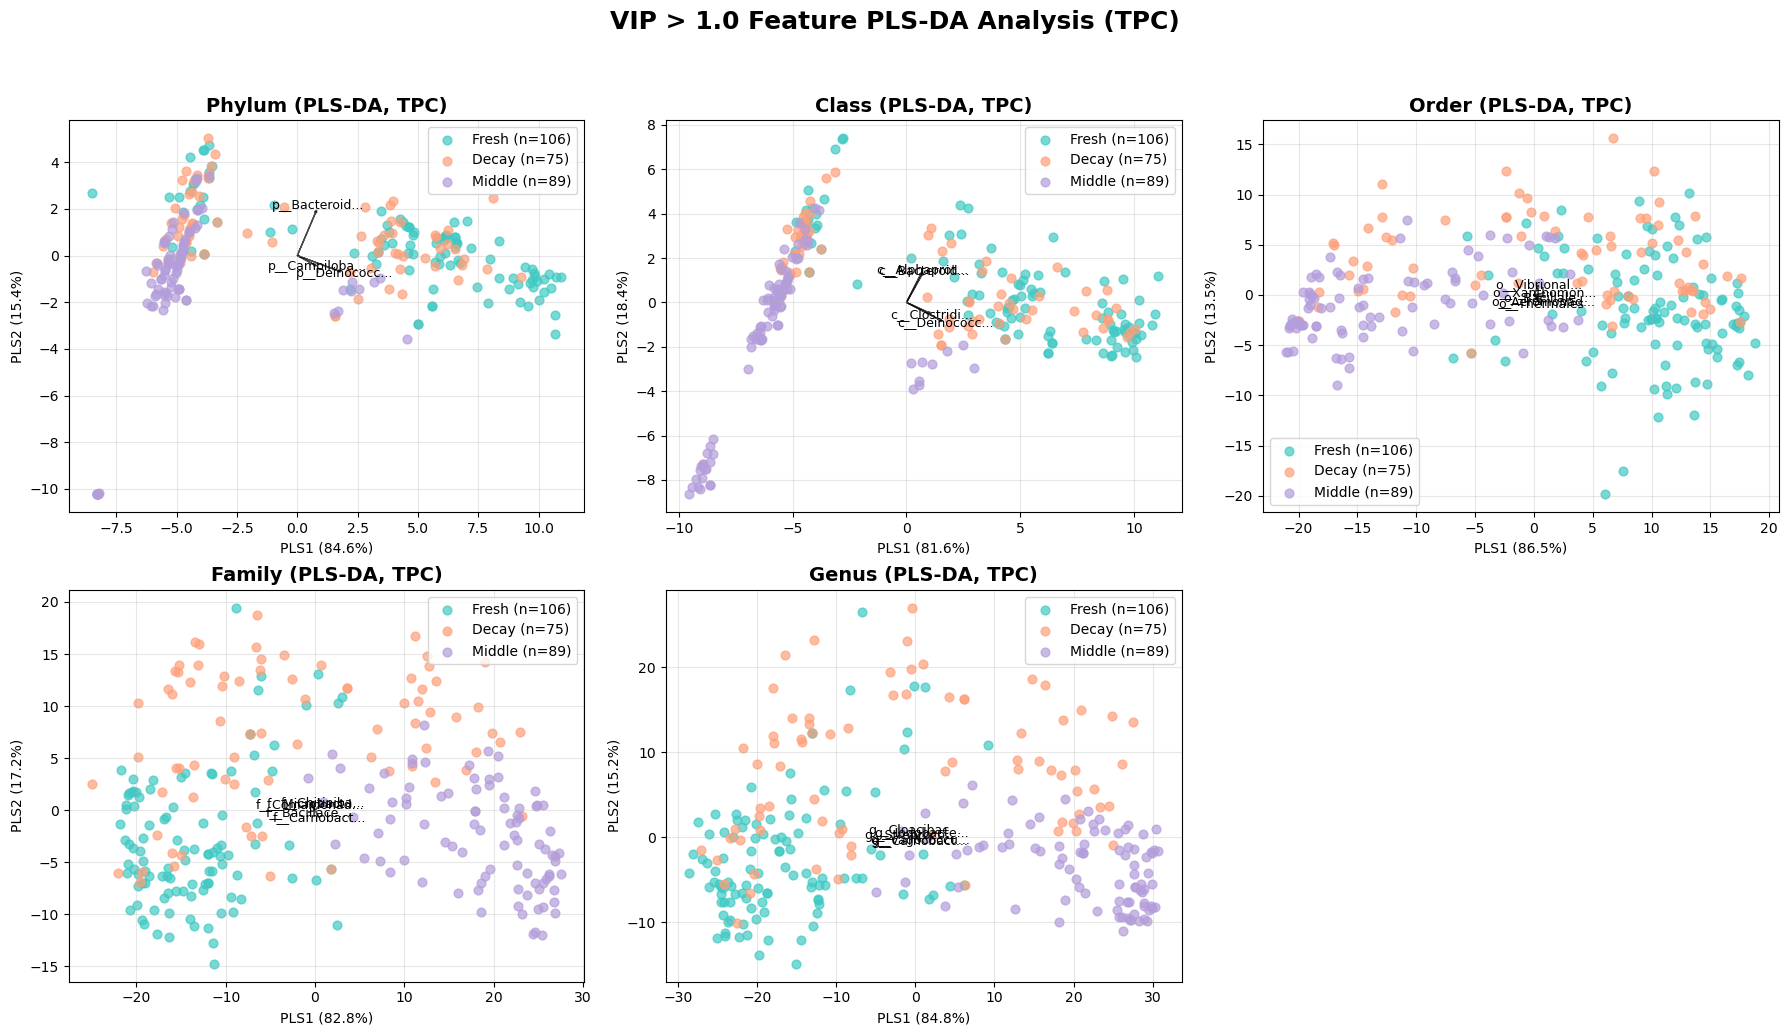

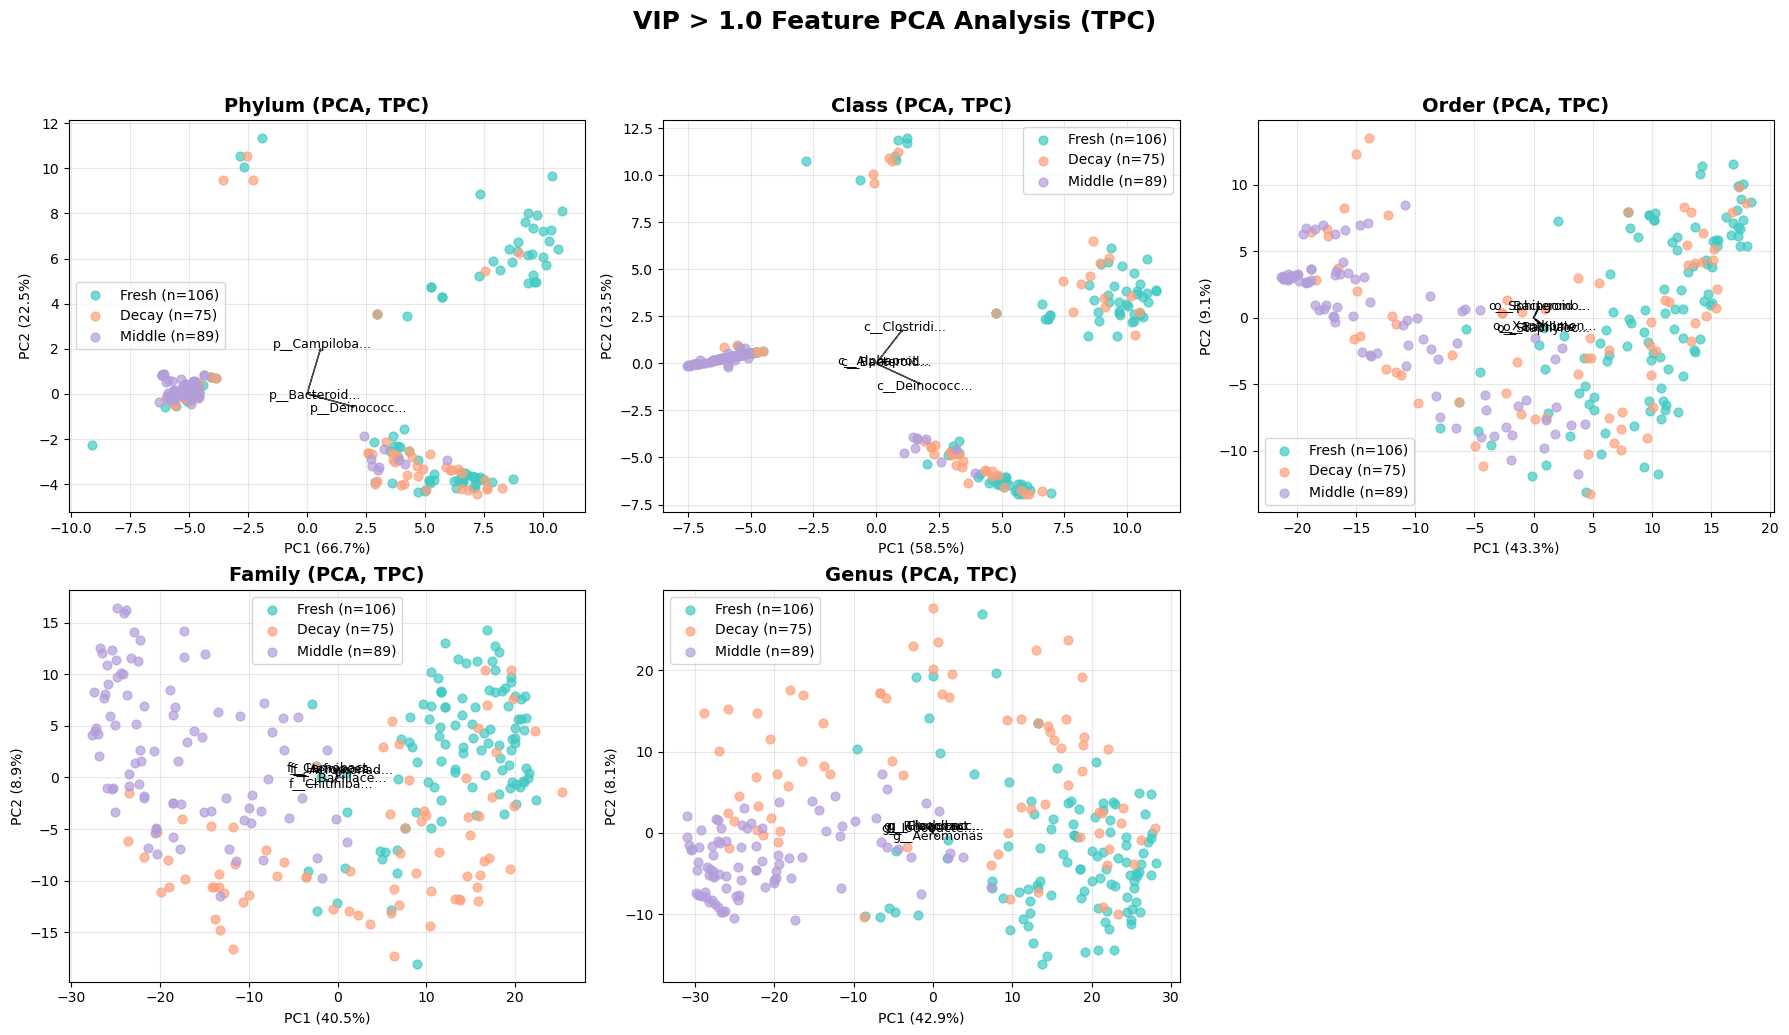

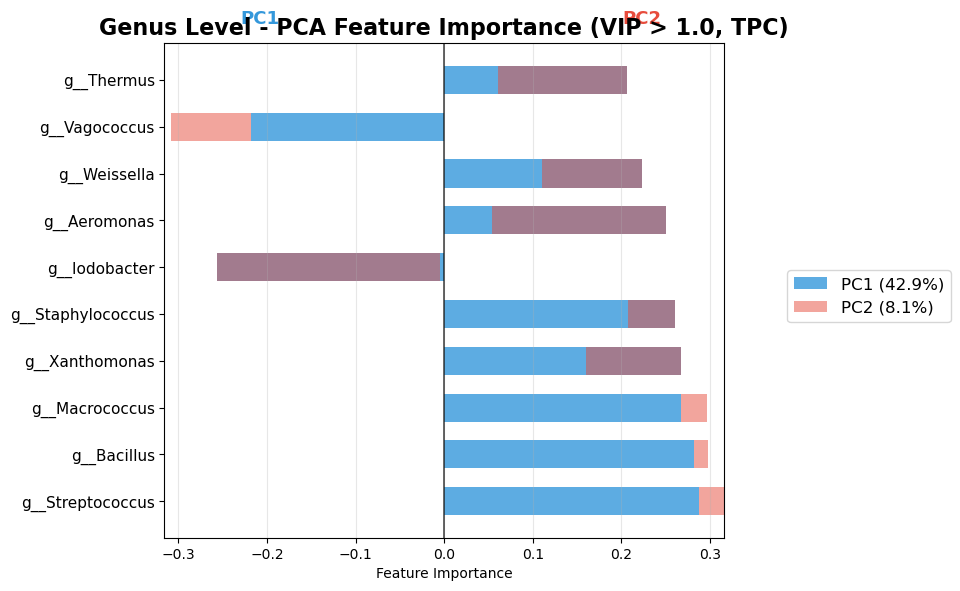

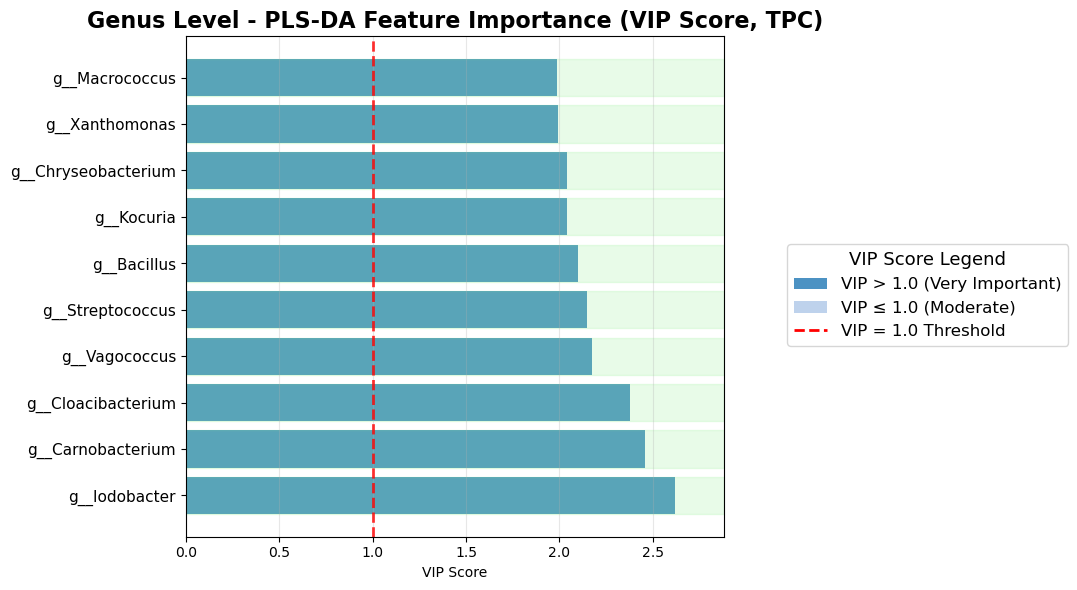

In [6]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 색상/라벨 변수 통일
colors = {0: "#40c9c3", 1: "#ffa07a", 2: "#b39ddb"}
label_names = {0: "Fresh", 1: "Decay", 2: "Middle"}

# 1. PLS-DA scatter (TPC 기준, 영어 텍스트)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
level_keys = list(vip_over1_dict.keys())
for idx, level_name in enumerate(level_keys):
    level_data = get_level_data(level_name)
    if level_data is None:
        print(f"{level_name}: No data, skipped")
        continue
    X = level_data['features']
    tpc = level_data['tpc']
    y = tpc_labeling(tpc)
    vip_features = vip_over1_dict[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: No VIP > 1.0 feature, skipped")
        continue
    X_vip = X[vip_features]
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1
    plsda = PLSRegression(n_components=2, scale=False)
    X_pls = plsda.fit_transform(X_vip, y_onehot)[0]
    exp_var = np.var(X_pls, axis=0) / np.sum(np.var(X_pls, axis=0)) * 100
    ax = axes[idx]
    # 산점도
    for label in [0, 1, 2]:
        count = np.sum(y == label)
        ax.scatter(
            X_pls[y == label, 0], X_pls[y == label, 1],
            label=f"{label_names[label]} (n={count})", alpha=0.7, s=40, color=colors[label]
        )
    # 상위 5개 loading 벡터
    loadings = plsda.x_weights_
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 color='black', alpha=0.7, head_width=0.1, head_length=0.1)
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=9, color='black', ha='center', va='center')
    ax.set_title(f"{level_name} (PLS-DA, TPC)", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"PLS1 ({exp_var[0]:.1f}%)")
    ax.set_ylabel(f"PLS2 ({exp_var[1]:.1f}%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
for j in range(len(level_keys), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("VIP > 1.0 Feature PLS-DA Analysis (TPC)", fontsize=18, fontweight='bold', y=1.03)
plt.show()

# 2. PCA scatter (TPC 기준, 영어 텍스트)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, level_name in enumerate(level_keys):
    level_data = get_level_data(level_name)
    if level_data is None:
        print(f"{level_name}: No data, skipped")
        continue
    X = level_data['features']
    tpc = level_data['tpc']
    y = tpc_labeling(tpc)
    vip_features = vip_over1_dict[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: No VIP > 1.0 feature, skipped")
        continue
    X_vip = X[vip_features]
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_vip)
    exp_var = pca.explained_variance_ratio_ * 100
    ax = axes[idx]
    # 산점도
    for label in [0, 1, 2]:
        count = np.sum(y == label)
        ax.scatter(
            X_pca[y == label, 0], X_pca[y == label, 1],
            label=f"{label_names[label]} (n={count})", alpha=0.7, s=40, color=colors[label]
        )
    # 상위 5개 loading 벡터
    loadings = pca.components_.T
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 color='black', alpha=0.7, head_width=0.1, head_length=0.1)
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=9, color='black', ha='center', va='center')
    ax.set_title(f"{level_name} (PCA, TPC)", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"PC1 ({exp_var[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({exp_var[1]:.1f}%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
for j in range(len(level_keys), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("VIP > 1.0 Feature PCA Analysis (TPC)", fontsize=18, fontweight='bold', y=1.03)
plt.show()

# 3. Genus level mirror bar chart (PCA, VIP Score, TPC 기준, 영어 텍스트)
level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_over1_dict[level_name]['Feature'].tolist()
if vip_features:
    # PCA mirror bar chart (Top 10)
    X_vip = level_data['features'][vip_features]
    pca = PCA(n_components=2)
    pca.fit(X_vip)
    loadings = pca.components_.T
    exp_var = pca.explained_variance_ratio_ * 100
    pc1_loadings = loadings[:, 0]
    pc2_loadings = loadings[:, 1]
    feature_names = np.array(vip_features)
    top10_idx = np.argsort(np.abs(pc1_loadings))[-10:][::-1]
    top10_features = feature_names[top10_idx]
    top10_pc1 = pc1_loadings[top10_idx]
    top10_pc2 = pc2_loadings[top10_idx]
    ind = np.arange(len(top10_features))
    height = 0.6
    fig, ax = plt.subplots(figsize=(8, 6))
    bars1 = ax.barh(ind, top10_pc1, height, color='#3498db', label=f'PC1 ({exp_var[0]:.1f}%)', alpha=0.8)
    bars2 = ax.barh(ind, top10_pc2, height, color='#e74c3c', label=f'PC2 ({exp_var[1]:.1f}%)', left=top10_pc1, alpha=0.5)
    ax.set_yticks(ind)
    ax.set_yticklabels(top10_features, fontsize=11)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Genus Level - PCA Feature Importance (VIP > 1.0, TPC)', fontsize=16, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1.2, alpha=0.7)
    fig.legend(loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12)
    ax.text(-max(abs(top10_pc1))*0.8, len(top10_features)+0.2, 'PC1', color='#3498db', fontsize=13, fontweight='bold')
    ax.text(max(abs(top10_pc2))*0.8, len(top10_features)+0.2, 'PC2', color='#e74c3c', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    max_val = max(np.max(np.abs(top10_pc1)), np.max(np.abs(top10_pc2)))
    ax.set_xlim(-max_val*1.1, max_val*1.1)
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    plt.show()

    # VIP Score mirror bar chart (Top 10)
    vip_df = vip_over1_dict[level_name]
    top10_vip = vip_df.sort_values('VIP_Score', ascending=False).head(10)
    top10_features_vip = top10_vip['Feature'].values
    top10_scores = top10_vip['VIP_Score'].values
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(np.arange(10), top10_scores, color=['#1f77b4' if v > 1.0 else '#aec7e8' for v in top10_scores], alpha=0.8)
    ax.set_yticks(np.arange(10))
    ax.set_yticklabels(top10_features_vip, fontsize=11)
    ax.set_xlabel('VIP Score')
    ax.set_title('Genus Level - PLS-DA Feature Importance (VIP Score, TPC)', fontsize=16, fontweight='bold')
    ax.axvline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax.grid(True, alpha=0.3, axis='x')
    for i in range(np.sum(top10_scores > 1.0)):
        ax.axhspan(i-0.4, i+0.4, alpha=0.2, color='lightgreen')
    ax.set_xlim(0, max(top10_scores)*1.1)
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor='#1f77b4', alpha=0.8, label='VIP > 1.0 (Very Important)'),
        plt.Rectangle((0, 0), 1, 1, facecolor='#aec7e8', alpha=0.8, label='VIP ≤ 1.0 (Moderate)'),
        plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='VIP = 1.0 Threshold')
    ]
    fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12, title='VIP Score Legend', title_fontsize=13)
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    plt.show()

## Heat map (Corrleation)
- 일단 Genus level로


=== Phylum VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준) ===


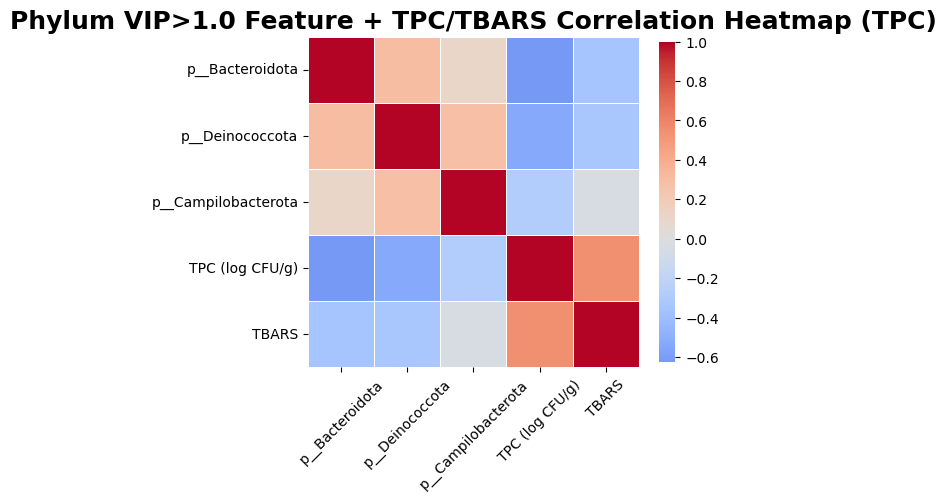


=== Class VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준) ===


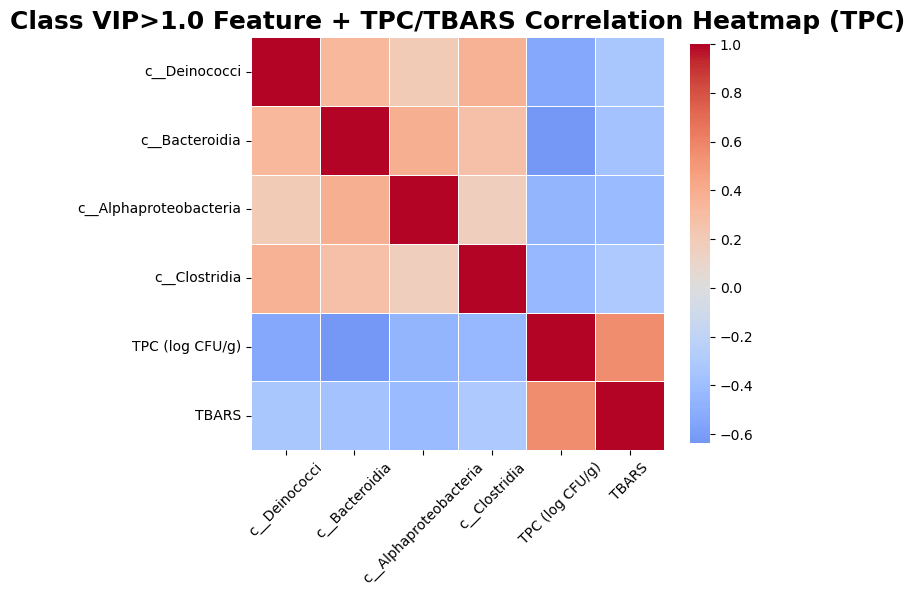


=== Order VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준) ===


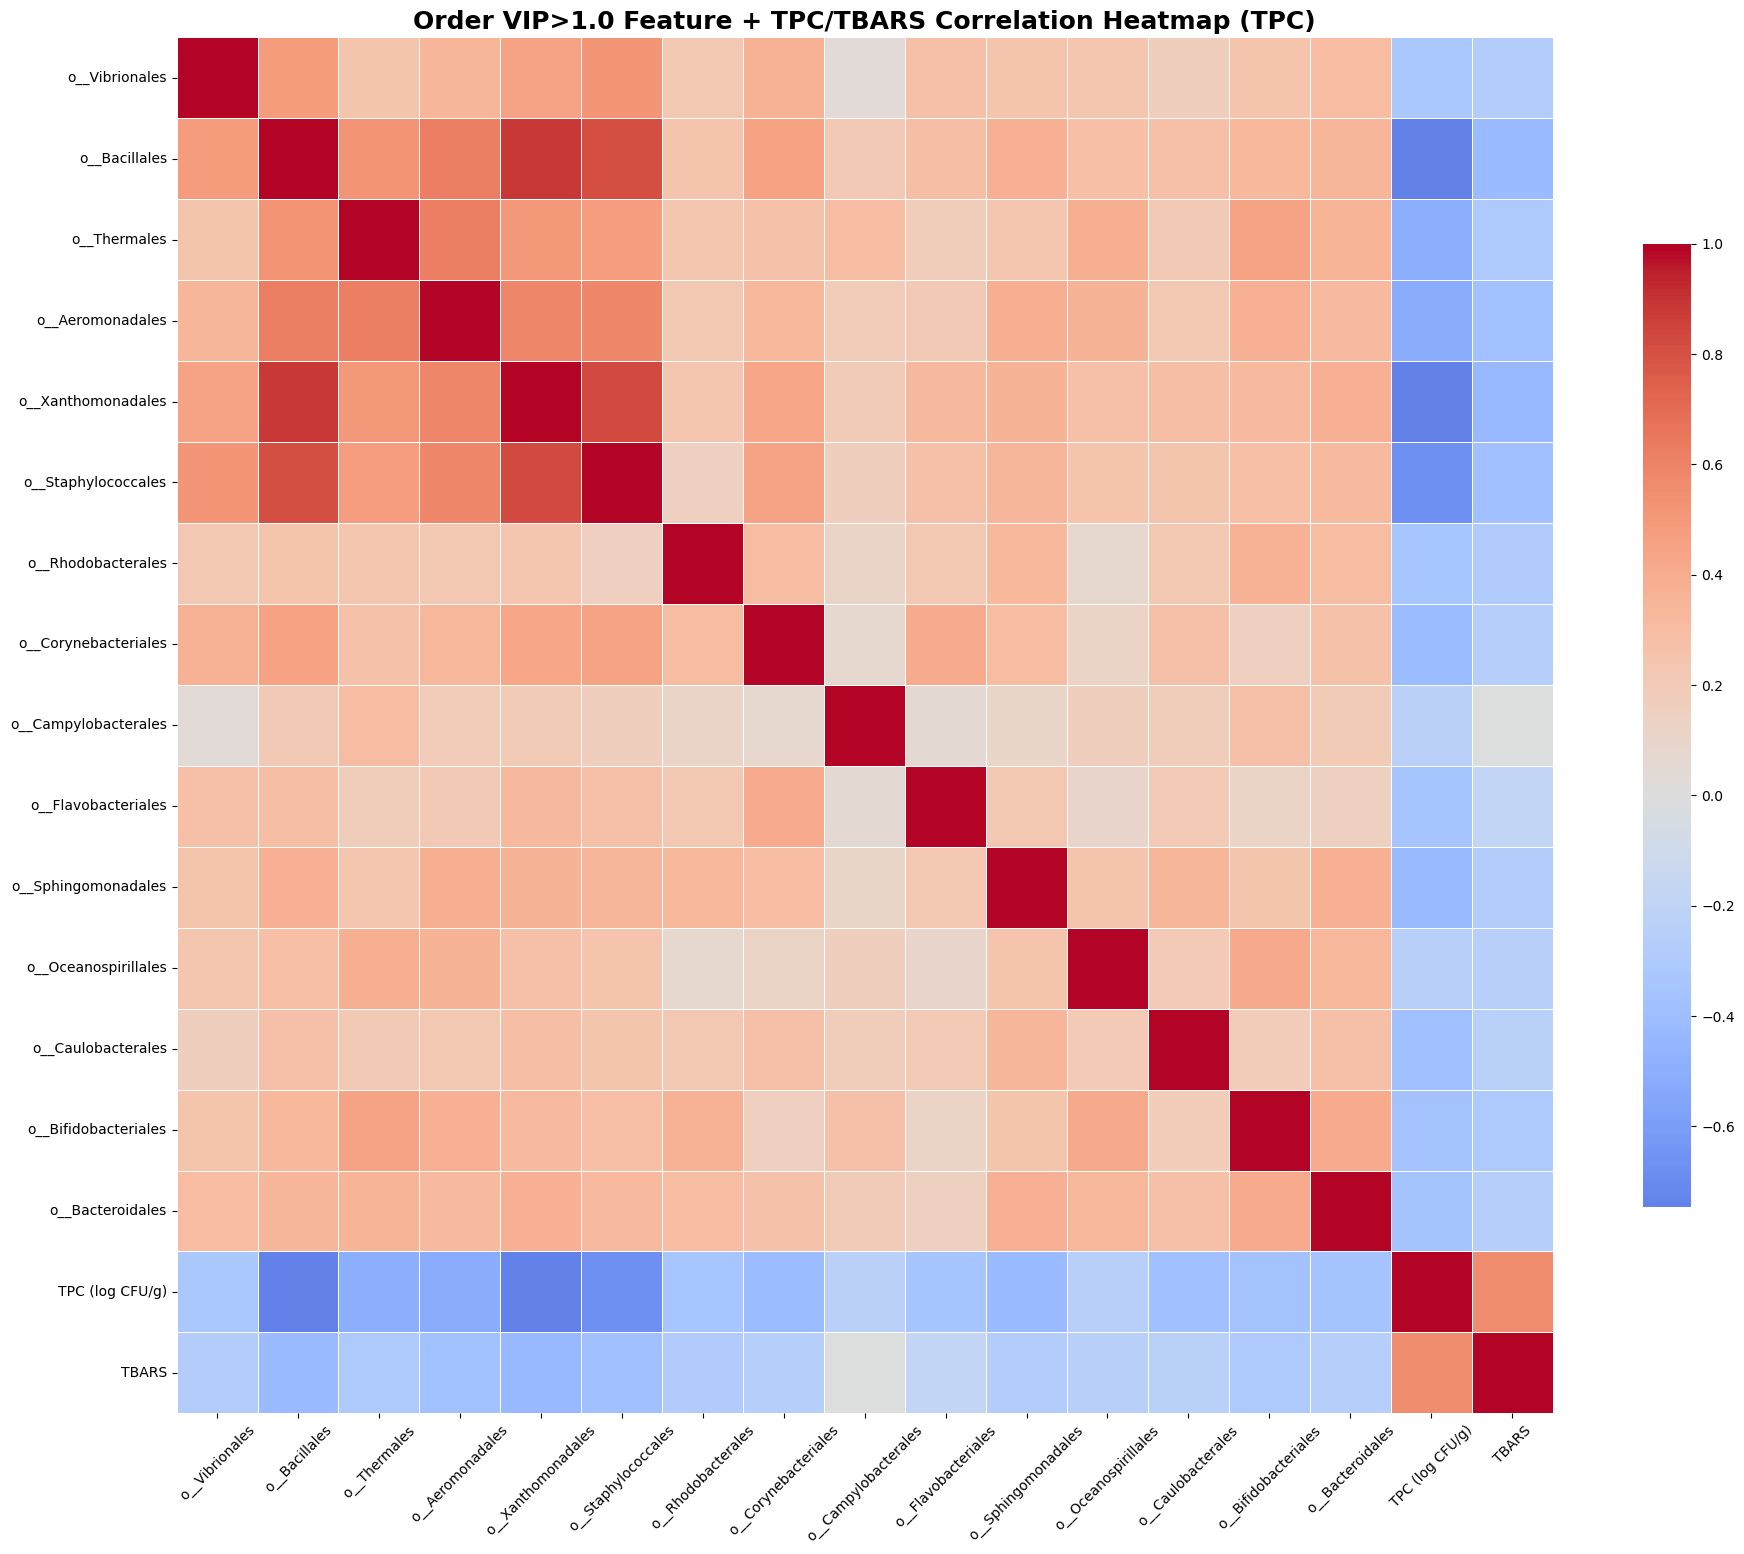


=== Family VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준) ===


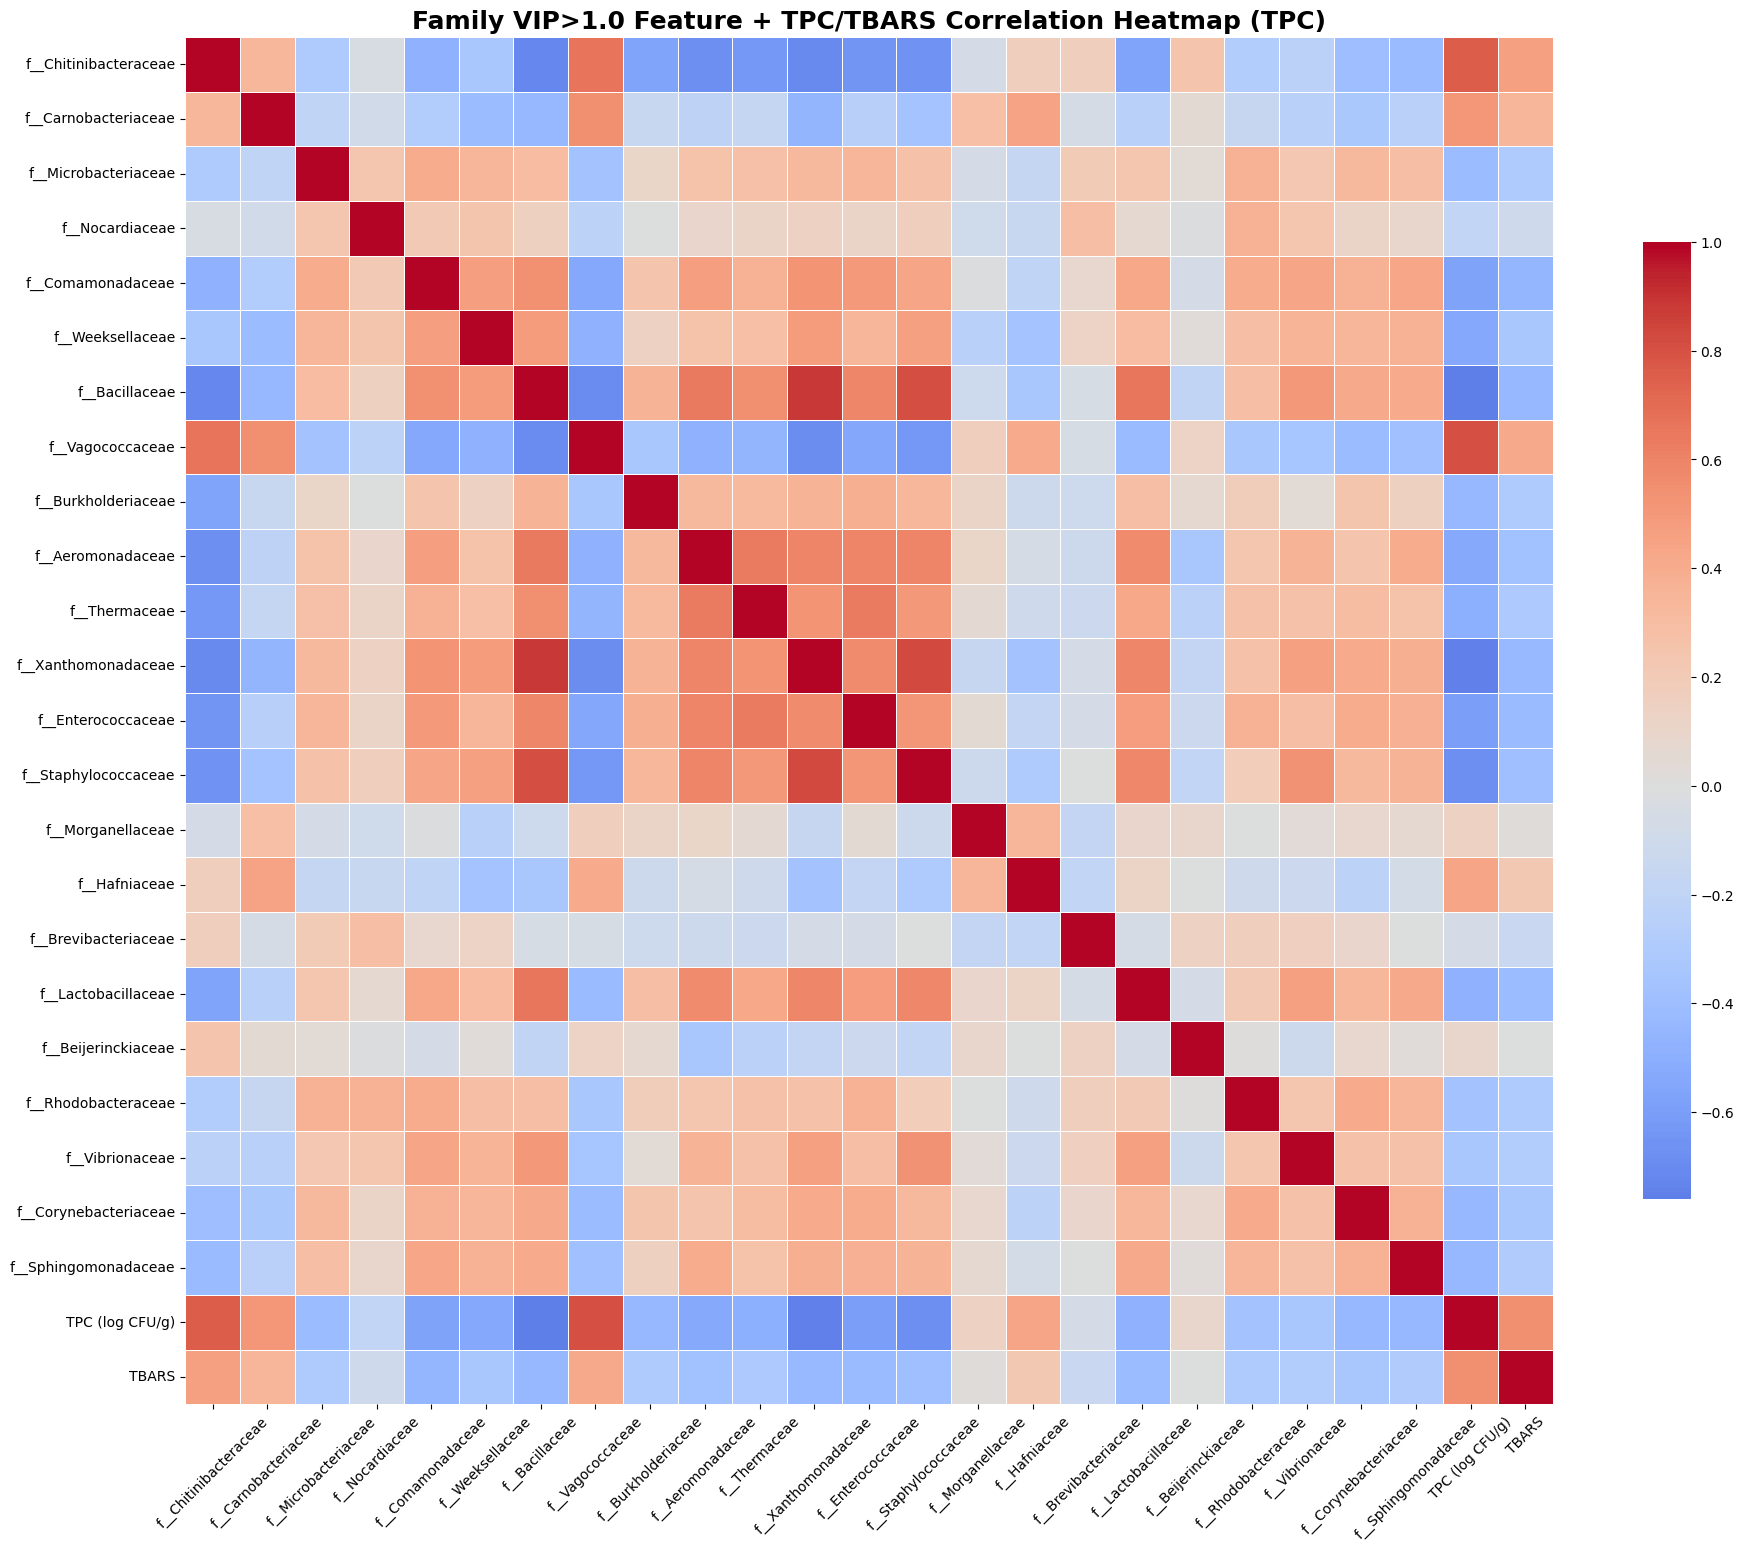


=== Genus VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준) ===


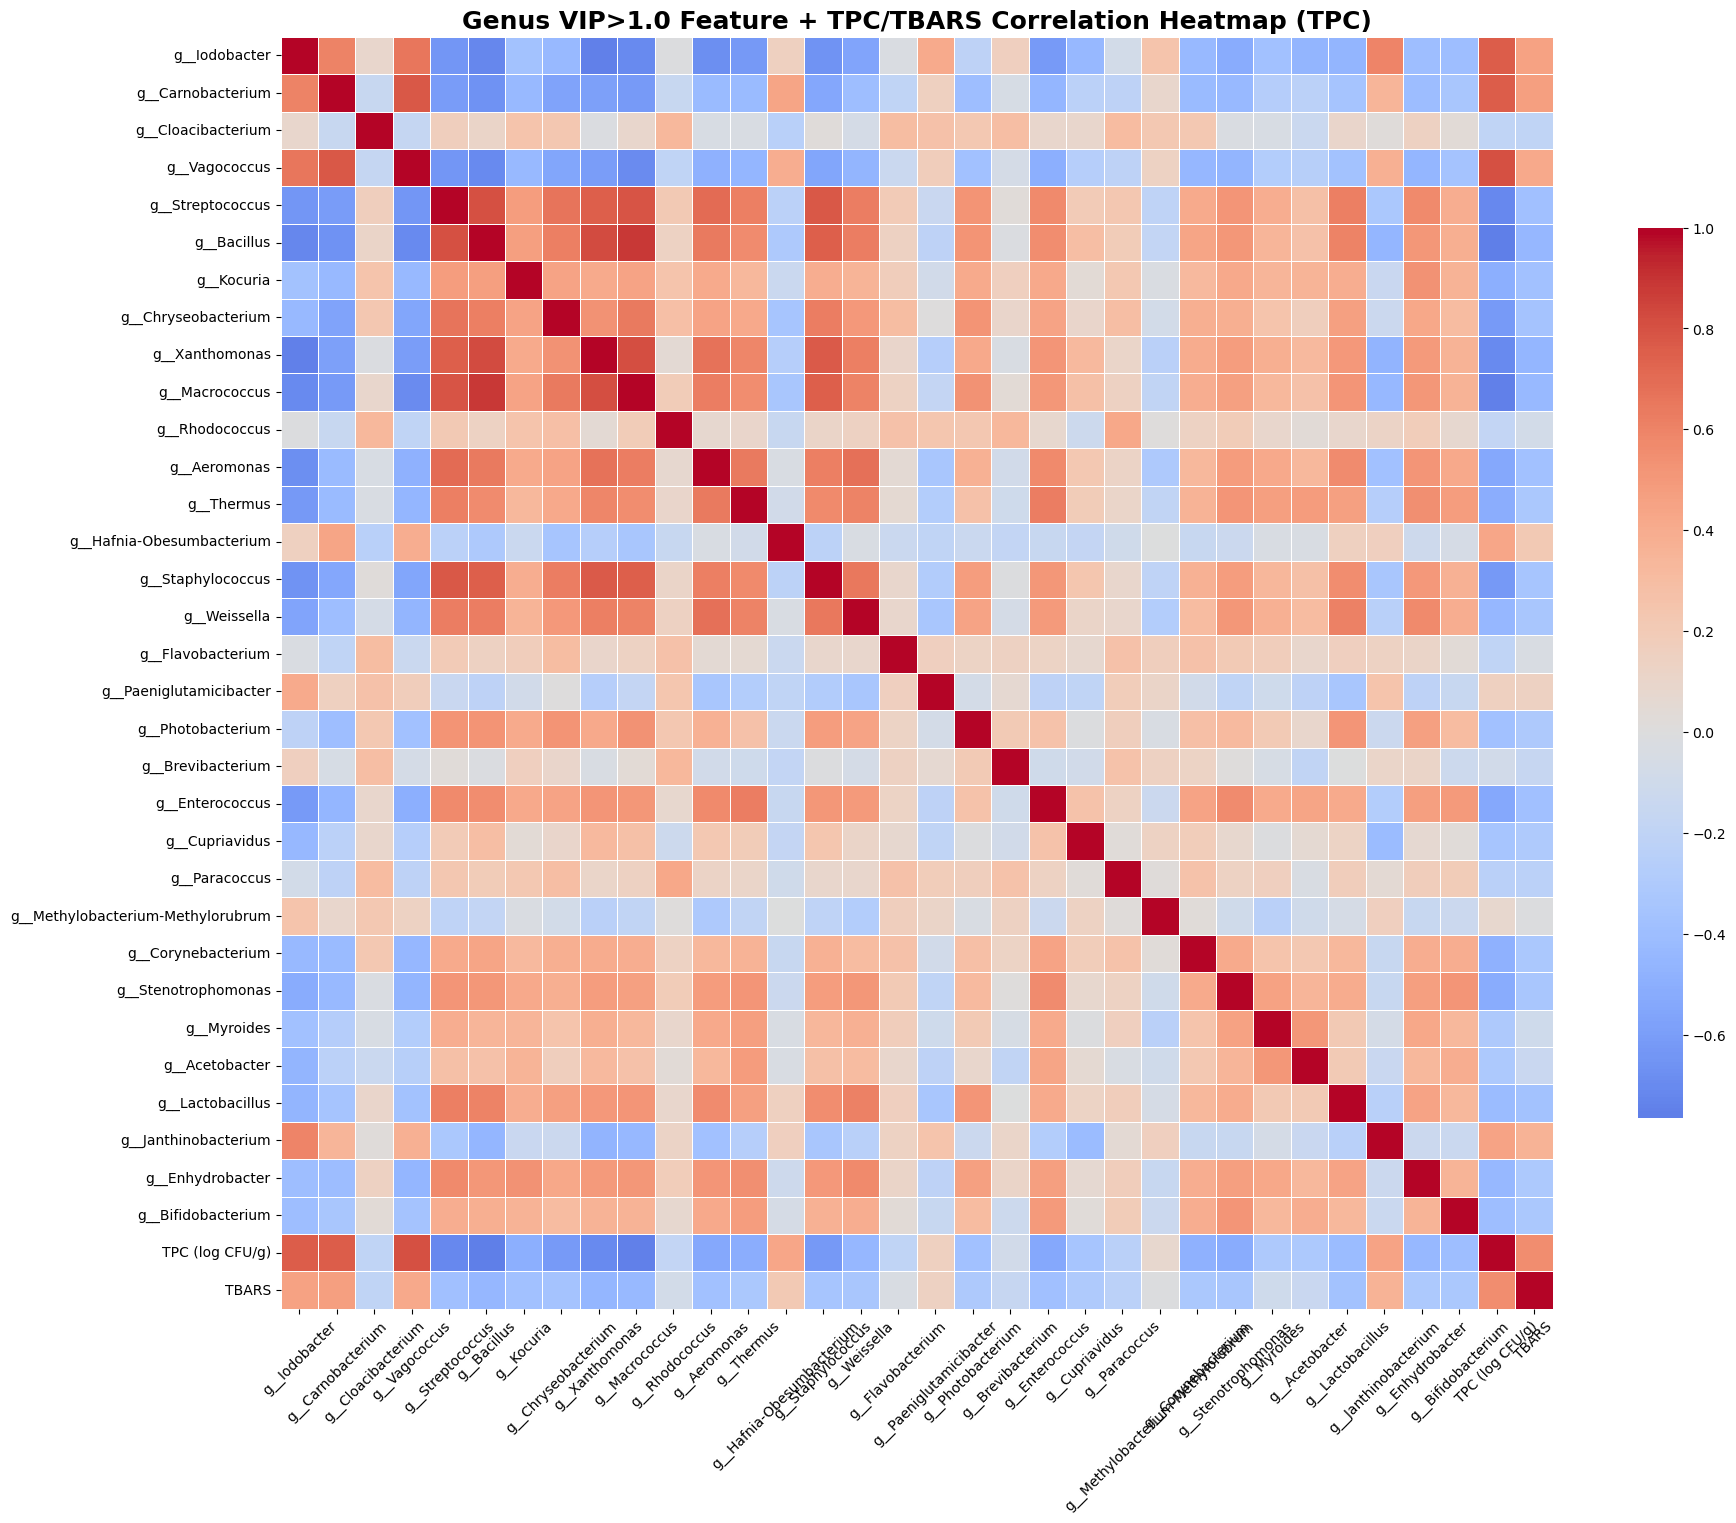

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

level_names = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

for level_name in level_names:
    print(f"\n=== {level_name} VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준) ===")
    level_data = get_level_data(level_name)
    if level_data is None:
        print(f"{level_name}: 데이터 없음, 스킵")
        continue
    # VIP>1.0 feature 추출 (TPC 기준)
    if level_name not in vip_over1_dict:
        print(f"{level_name}: VIP Score 데이터 없음, 스킵")
        continue
    vip_features = vip_over1_dict[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
        continue
    X_vip = level_data['features'][vip_features]
    X_corr = X_vip.copy()
    X_corr['TPC (log CFU/g)'] = level_data['tpc']
    X_corr['TBARS'] = level_data['tbars']
    corr_matrix = X_corr.corr()
    plt.figure(figsize=(min(1.2*len(X_corr.columns), 20), min(1.2*len(X_corr.columns), 16)))
    sns.heatmap(
        corr_matrix, 
        cmap='coolwarm', 
        center=0, 
        square=True, 
        linewidths=0.5, 
        cbar_kws={"shrink": 0.7},
        xticklabels=True, 
        yticklabels=True
    )
    plt.title(f'{level_name} VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC)', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

## TBARS도 확인


=== Phylum Level: VIP Score > 1.0 (TBARS 기준) ===
VIP > 1.0 Feature 개수: 3 / 12


,Feature,VIP_Score
0,p__Deinococcota,2.260515
1,p__Bacteroidota,2.096253
2,p__Campilobacterota,1.481844



=== Class Level: VIP Score > 1.0 (TBARS 기준) ===
VIP > 1.0 Feature 개수: 5 / 13


,Feature,VIP_Score
0,c__Deinococci,2.020334
1,c__Alphaproteobacteria,1.499347
2,c__Campylobacteria,1.478166
3,c__Bacteroidia,1.441032
4,c__Clostridia,1.153897



=== Order Level: VIP Score > 1.0 (TBARS 기준) ===
VIP > 1.0 Feature 개수: 13 / 48


...


=== Family Level: VIP Score > 1.0 (TBARS 기준) ===
VIP > 1.0 Feature 개수: 32 / 85


,Feature,VIP_Score
0,f__Flavobacteriaceae,2.675658
1,f__Comamonadaceae,2.067998
2,f__Bacilli(c),2.040552
3,f__Chitinibacteraceae,1.963122
4,f__Enterobacterales(o),1.944092
5,f__Prevotellaceae,1.810865
6,f__Bacillaceae,1.717226
7,f__Thermaceae,1.713901
8,f__Vagococcaceae,1.647563
9,f__Xanthomonadaceae,1.642206



=== Genus Level: VIP Score > 1.0 (TBARS 기준) ===
VIP > 1.0 Feature 개수: 48 / 133


,Feature,VIP_Score
0,g__Myroides,2.111228
1,g__Xanthomonas,2.077867
2,g__Microbacteriaceae(f),2.055836
3,g__Iodobacter,2.030678
4,g__Janthinobacterium,1.966545
5,g__Bacillus,1.929439
6,g__Streptococcus,1.921604
7,g__Macrococcus,1.918894
8,g__Enterobacterales(o),1.892943
9,g__Carnobacterium,1.881957



=== 모든 Level VIP > 1.0 Feature (TBARS 기준) 추출 완료 ===


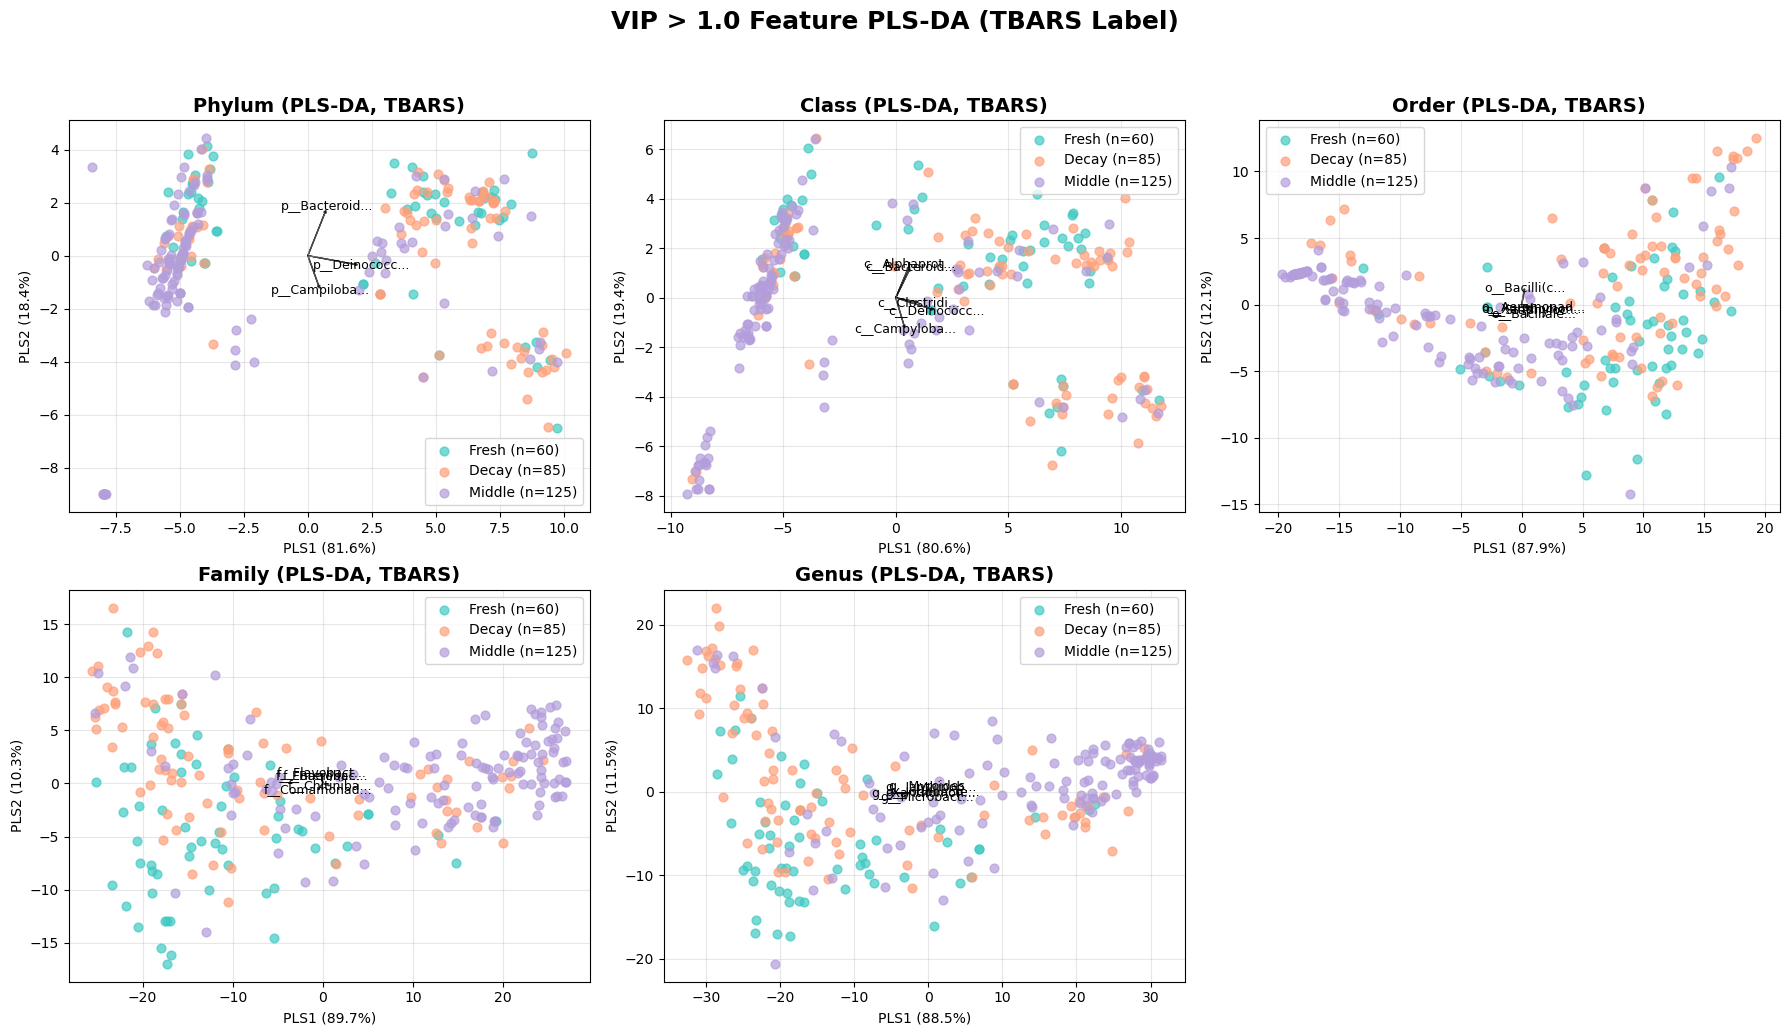

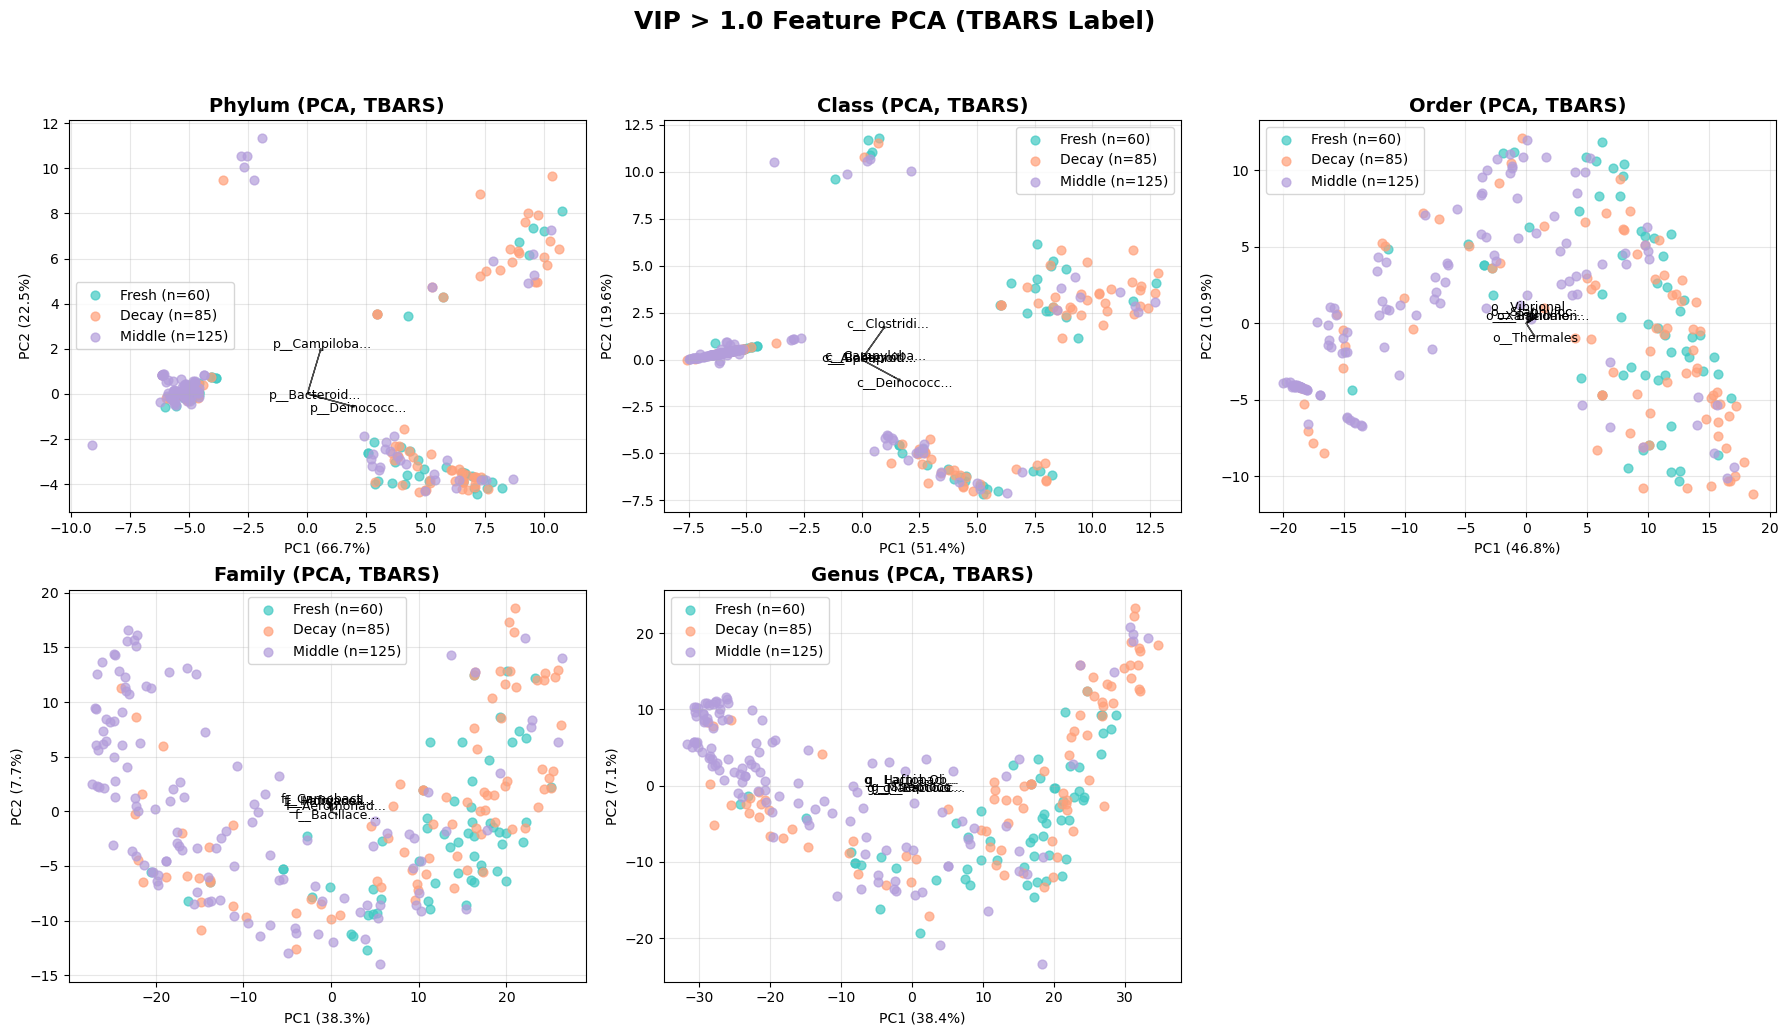

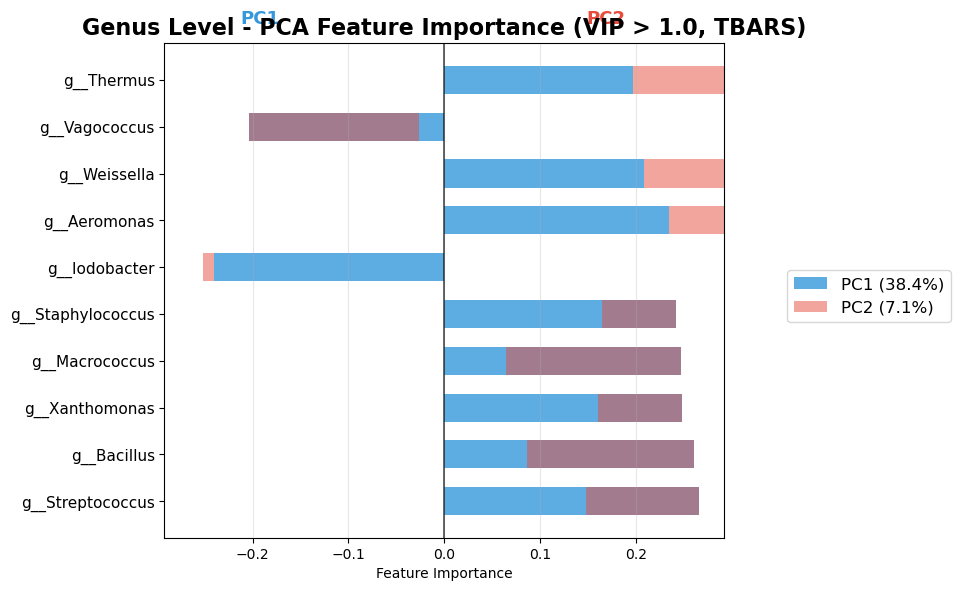

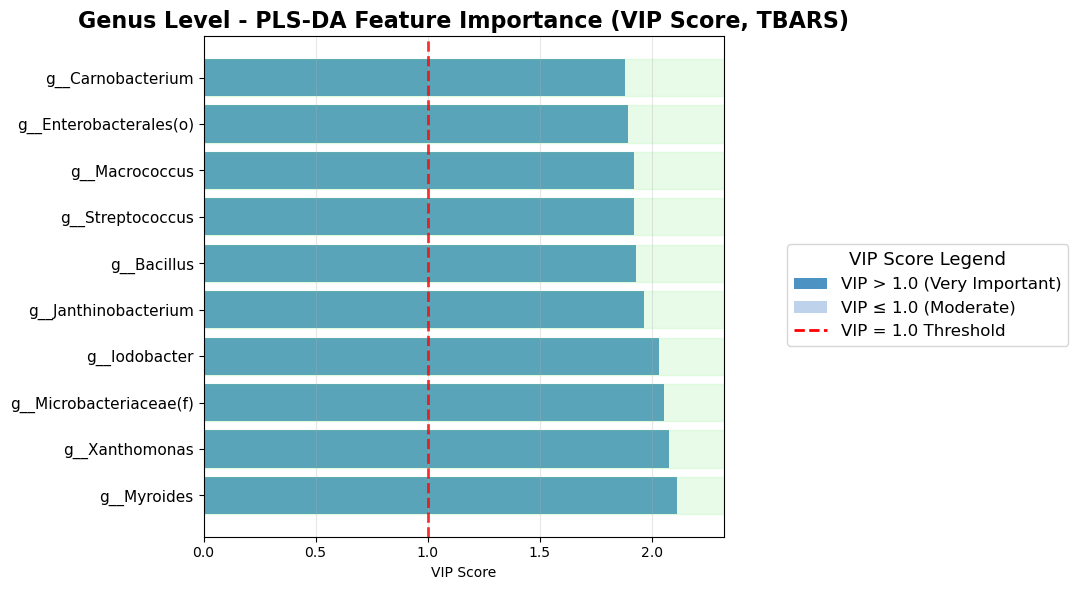

In [8]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from IPython.display import display

# TBARS 라벨링 함수 (임계값 반영)
def tbars_labeling(tbars_series):
    return np.where(
        tbars_series < 0.189, 0,
        np.where(tbars_series < 0.289, 1, 2)
    )  # 0: Fresh, 1: Middle, 2: Decay

level_names = ['Phylum', 'Class', 'Order', 'Family', 'Genus']
colors = {0: "#40c9c3", 1: "#ffa07a", 2: "#b39ddb"}
label_names = {0: "Fresh", 1: "Decay", 2: "Middle"}

# 1. VIP Score 1.0 이상 feature display 및 저장
vip_score_tbars = {}

for level_name in level_names:
    print(f"\n{'='*60}")
    print(f"=== {level_name} Level: VIP Score > 1.0 (TBARS 기준) ===")
    print(f"{'='*60}")

    level_data = get_level_data(level_name)
    X = level_data['features'][level_data['significant_features']]
    y = tbars_labeling(level_data['tbars'])

    # One-hot encoding
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1

    # PLS-DA
    plsda = PLSRegression(n_components=2, scale=False)
    plsda.fit(X, y_onehot)

    # VIP score 계산
    x_weights = plsda.x_weights_
    SS = np.sum(x_weights**2, axis=1)
    vip_scores = np.sqrt(len(X.columns) * SS / np.sum(SS))

    vip_df = pd.DataFrame({
        'Feature': X.columns,
        'VIP_Score': vip_scores
    }).sort_values('VIP_Score', ascending=False)

    vip_over1 = vip_df[vip_df['VIP_Score'] > 1.0].reset_index(drop=True)
    vip_score_tbars[level_name] = vip_over1

    print(f"VIP > 1.0 Feature 개수: {len(vip_over1)} / {len(vip_df)}")
    if len(vip_over1) > 0:
        display(vip_over1)
    else:
        print("VIP > 1.0인 Feature가 없습니다.")

print("\n=== 모든 Level VIP > 1.0 Feature (TBARS 기준) 추출 완료 ===")

# 2. PLS-DA scatter (TBARS 기준)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, level_name in enumerate(level_names):
    level_data = get_level_data(level_name)
    tbars = level_data['tbars']
    y = tbars_labeling(tbars)
    vip_features = vip_score_tbars[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
        continue
    X_vip = level_data['features'][vip_features]

    # PLS-DA
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1
    plsda = PLSRegression(n_components=2, scale=False)
    X_pls = plsda.fit_transform(X_vip, y_onehot)[0]
    exp_var = np.var(X_pls, axis=0) / np.sum(np.var(X_pls, axis=0)) * 100

    ax = axes[idx]
    for label in [0, 1, 2]:
        count = np.sum(y == label)
        ax.scatter(
            X_pls[y == label, 0], X_pls[y == label, 1],
            label=f"{label_names[label]} (n={count})", alpha=0.7, s=40, color=colors[label]
        )
    # 벡터(loading) 추가: 상위 5개만
    loadings = plsda.x_weights_
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 color='black', alpha=0.7, head_width=0.1, head_length=0.1)
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=9, color='black', ha='center', va='center')
    ax.set_title(f"{level_name} (PLS-DA, TBARS)", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"PLS1 ({exp_var[0]:.1f}%)")
    ax.set_ylabel(f"PLS2 ({exp_var[1]:.1f}%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')

for j in range(len(level_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("VIP > 1.0 Feature PLS-DA (TBARS Label)", fontsize=18, fontweight='bold', y=1.03)
plt.show()

# 3. PCA scatter (TBARS 기준)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, level_name in enumerate(level_names):
    level_data = get_level_data(level_name)
    tbars = level_data['tbars']
    y = tbars_labeling(tbars)
    vip_features = vip_score_tbars[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
        continue
    X_vip = level_data['features'][vip_features]

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_vip)
    exp_var = pca.explained_variance_ratio_ * 100

    ax = axes[idx]
    for label in [0, 1, 2]:
        count = np.sum(y == label)
        ax.scatter(
            X_pca[y == label, 0], X_pca[y == label, 1],
            label=f"{label_names[label]} (n={count})", alpha=0.7, s=40, color=colors[label]
        )
    # 벡터(loading) 추가: 상위 5개만
    loadings = pca.components_.T
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 color='black', alpha=0.7, head_width=0.1, head_length=0.1)
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=9, color='black', ha='center', va='center')
    ax.set_title(f"{level_name} (PCA, TBARS)", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"PC1 ({exp_var[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({exp_var[1]:.1f}%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')

for j in range(len(level_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("VIP > 1.0 Feature PCA (TBARS Label)", fontsize=18, fontweight='bold', y=1.03)
plt.show()

# 4. Genus level mirror bar chart (TBARS 기준, PCA/PLS-DA)
level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_score_tbars[level_name]['Feature'].tolist()
if vip_features:
    # PCA mirror bar chart (Top 10)
    X_vip = level_data['features'][vip_features]
    pca = PCA(n_components=2)
    pca.fit(X_vip)
    loadings = pca.components_.T
    exp_var = pca.explained_variance_ratio_ * 100
    pc1_loadings = loadings[:, 0]
    pc2_loadings = loadings[:, 1]
    feature_names = np.array(vip_features)
    top10_idx = np.argsort(np.abs(pc1_loadings))[-10:][::-1]
    top10_features = feature_names[top10_idx]
    top10_pc1 = pc1_loadings[top10_idx]
    top10_pc2 = pc2_loadings[top10_idx]
    ind = np.arange(len(top10_features))
    height = 0.6
    fig, ax = plt.subplots(figsize=(8, 6))
    bars1 = ax.barh(ind, top10_pc1, height, color='#3498db', label=f'PC1 ({exp_var[0]:.1f}%)', alpha=0.8)
    bars2 = ax.barh(ind, top10_pc2, height, color='#e74c3c', label=f'PC2 ({exp_var[1]:.1f}%)', left=top10_pc1, alpha=0.5)
    ax.set_yticks(ind)
    ax.set_yticklabels(top10_features, fontsize=11)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Genus Level - PCA Feature Importance (VIP > 1.0, TBARS)', fontsize=16, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1.2, alpha=0.7)
    fig.legend(loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12)
    ax.text(-max(abs(top10_pc1))*0.8, len(top10_features)+0.2, 'PC1', color='#3498db', fontsize=13, fontweight='bold')
    ax.text(max(abs(top10_pc2))*0.8, len(top10_features)+0.2, 'PC2', color='#e74c3c', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    max_val = max(np.max(np.abs(top10_pc1)), np.max(np.abs(top10_pc2)))
    ax.set_xlim(-max_val*1.1, max_val*1.1)
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    plt.show()

    # VIP Score mirror bar chart (Top 10, PLS-DA)
    vip_df = vip_score_tbars[level_name]
    top10_vip = vip_df.sort_values('VIP_Score', ascending=False).head(10)
    top10_features_vip = top10_vip['Feature'].values
    top10_scores = top10_vip['VIP_Score'].values
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(np.arange(10), top10_scores, color=['#1f77b4' if v > 1.0 else '#aec7e8' for v in top10_scores], alpha=0.8)
    ax.set_yticks(np.arange(10))
    ax.set_yticklabels(top10_features_vip, fontsize=11)
    ax.set_xlabel('VIP Score')
    ax.set_title('Genus Level - PLS-DA Feature Importance (VIP Score, TBARS)', fontsize=16, fontweight='bold')
    ax.axvline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax.grid(True, alpha=0.3, axis='x')
    for i in range(np.sum(top10_scores > 1.0)):
        ax.axhspan(i-0.4, i+0.4, alpha=0.2, color='lightgreen')
    ax.set_xlim(0, max(top10_scores)*1.1)
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor='#1f77b4', alpha=0.8, label='VIP > 1.0 (Very Important)'),
        plt.Rectangle((0, 0), 1, 1, facecolor='#aec7e8', alpha=0.8, label='VIP ≤ 1.0 (Moderate)'),
        plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='VIP = 1.0 Threshold')
    ]
    fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12, title='VIP Score Legend', title_fontsize=13)
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    plt.show()

## TBARS 기준으로 뽑힌 VIP Score 1.0 Feature 상관관계 분석

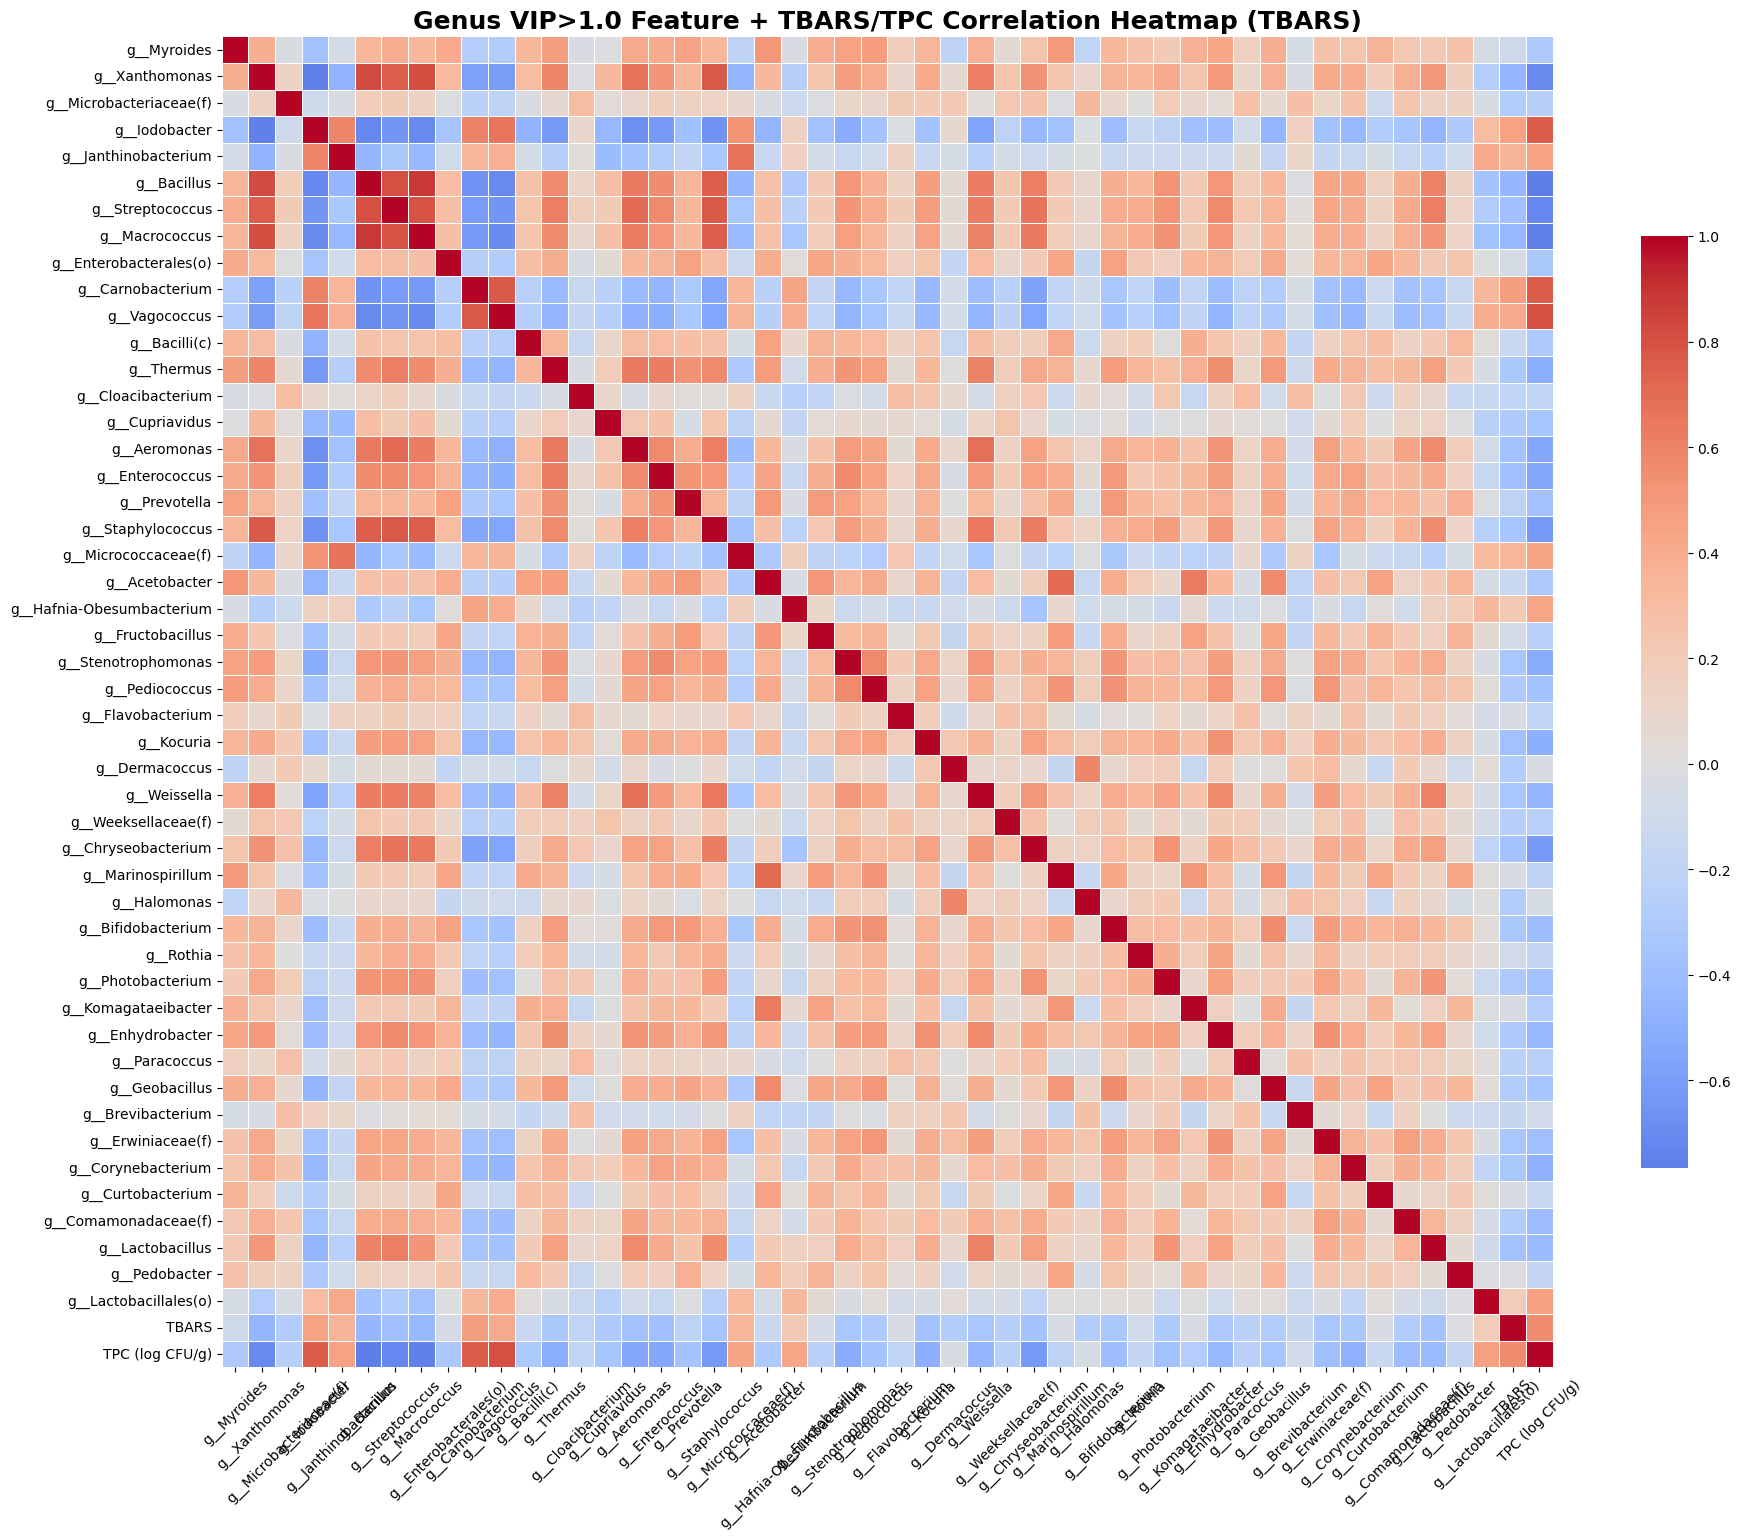

In [9]:
# TBARS 기준 VIP > 1.0 feature의 Genus level 상관관계 분석 Heatmap

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Genus level 데이터 및 VIP > 1.0 feature 추출
level_name = 'Genus'
level_data = get_level_data(level_name)
if level_data is None:
    print(f"{level_name}: 데이터 없음, 스킵")
else:
    # TBARS 기준 VIP > 1.0 feature 리스트
    vip_features = vip_score_tbars[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
    else:
        # Feature + TBARS + TPC 데이터프레임 생성
        X_vip = level_data['features'][vip_features].copy()
        X_vip['TBARS'] = level_data['tbars']
        X_vip['TPC (log CFU/g)'] = level_data['tpc']

        # 상관계수 행렬 계산
        corr_matrix = X_vip.corr()

        # 히트맵 시각화
        plt.figure(figsize=(min(1.2*len(X_vip.columns), 20), min(1.2*len(X_vip.columns), 16)))
        sns.heatmap(
            corr_matrix,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.7},
            xticklabels=True,
            yticklabels=True,
            annot=False
        )
        plt.title('Genus VIP>1.0 Feature + TBARS/TPC Correlation Heatmap (TBARS)', fontsize=18, fontweight='bold')
        plt.tight_layout()
        plt.xticks(rotation=45)
        plt.show()

## PC1 VIP Score Feature Importance 

/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_2208/2872172160.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])


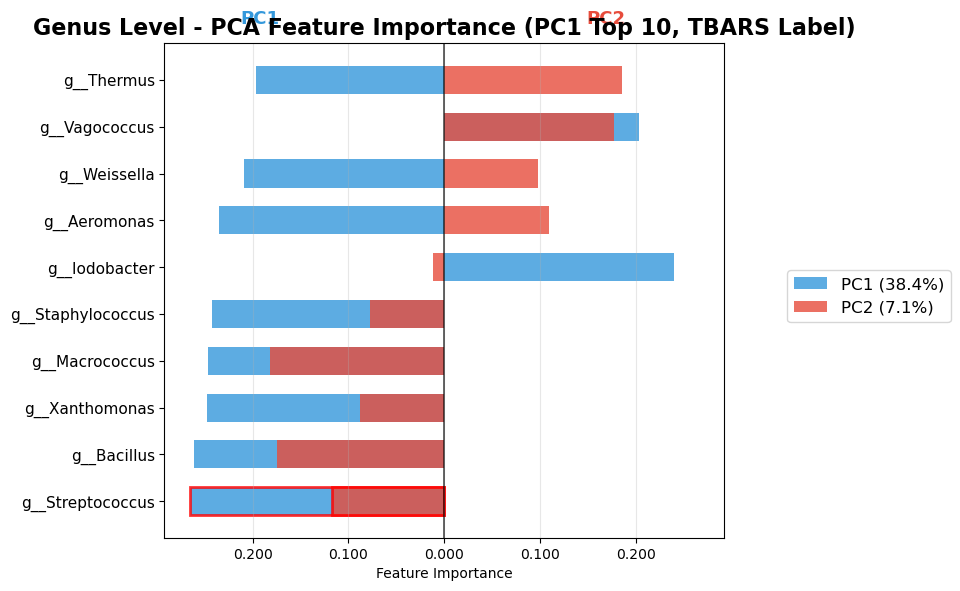

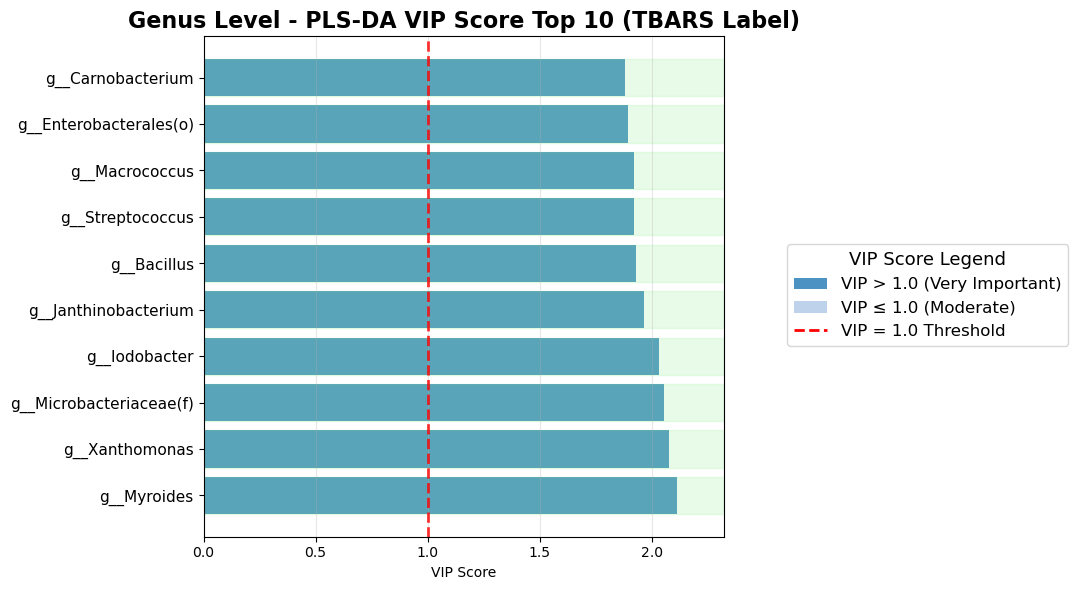

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. TBARS 기준 Genus level PC1 Top 10 mirror bar chart
level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_score_tbars[level_name]['Feature'].tolist()
if not vip_features:
    print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
else:
    X_vip = level_data['features'][vip_features]
    pca = PCA(n_components=2)
    pca.fit(X_vip)
    loadings = pca.components_.T
    exp_var = pca.explained_variance_ratio_ * 100

    pc1_loadings = loadings[:, 0]
    pc2_loadings = loadings[:, 1]
    feature_names = np.array(vip_features)
    top10_idx = np.argsort(np.abs(pc1_loadings))[-10:][::-1]
    top10_features = feature_names[top10_idx]
    top10_pc1 = pc1_loadings[top10_idx]
    top10_pc2 = pc2_loadings[top10_idx]

    ind = np.arange(len(top10_features))
    height = 0.6

    fig, ax = plt.subplots(figsize=(8, 6))
    bars1 = ax.barh(ind, -top10_pc1, height, color='#3498db', label=f'PC1 ({exp_var[0]:.1f}%)', alpha=0.8)
    bars2 = ax.barh(ind, top10_pc2, height, color='#e74c3c', label=f'PC2 ({exp_var[1]:.1f}%)', alpha=0.8)
    ax.set_yticks(ind)
    ax.set_yticklabels(top10_features, fontsize=11)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Genus Level - PCA Feature Importance (PC1 Top 10, TBARS Label)', fontsize=16, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1.2, alpha=0.7)
    fig.legend(loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12)
    ax.text(-max(abs(top10_pc1))*0.8, len(top10_features)+0.2, 'PC1', color='#3498db', fontsize=13, fontweight='bold')
    ax.text(max(abs(top10_pc2))*0.8, len(top10_features)+0.2, 'PC2', color='#e74c3c', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    max_val = max(np.max(np.abs(top10_pc1)), np.max(np.abs(top10_pc2)))
    ax.set_xlim(-max_val*1.1, max_val*1.1)
    bars1[0].set_edgecolor('red'); bars1[0].set_linewidth(2)
    bars2[0].set_edgecolor('red'); bars2[0].set_linewidth(2)
    ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    plt.show()

# 2. TBARS 기준 Genus level VIP Score Top 10 mirror bar chart
vip_df = vip_score_tbars[level_name]
top10_vip = vip_df.sort_values('VIP_Score', ascending=False).head(10)
top10_features_vip = top10_vip['Feature'].values
top10_scores = top10_vip['VIP_Score'].values

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(np.arange(10), top10_scores, color=['#1f77b4' if v > 1.0 else '#aec7e8' for v in top10_scores], alpha=0.8)
ax.set_yticks(np.arange(10))
ax.set_yticklabels(top10_features_vip, fontsize=11)
ax.set_xlabel('VIP Score')
ax.set_title('Genus Level - PLS-DA VIP Score Top 10 (TBARS Label)', fontsize=16, fontweight='bold')
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.8)
ax.grid(True, alpha=0.3, axis='x')
for i in range(np.sum(top10_scores > 1.0)):
    ax.axhspan(i-0.4, i+0.4, alpha=0.2, color='lightgreen')
ax.set_xlim(0, max(top10_scores)*1.1)
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor='#1f77b4', alpha=0.8, label='VIP > 1.0 (Very Important)'),
    plt.Rectangle((0, 0), 1, 1, facecolor='#aec7e8', alpha=0.8, label='VIP ≤ 1.0 (Moderate)'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='VIP = 1.0 Threshold')
]
fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12, title='VIP Score Legend', title_fontsize=13)
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.show()

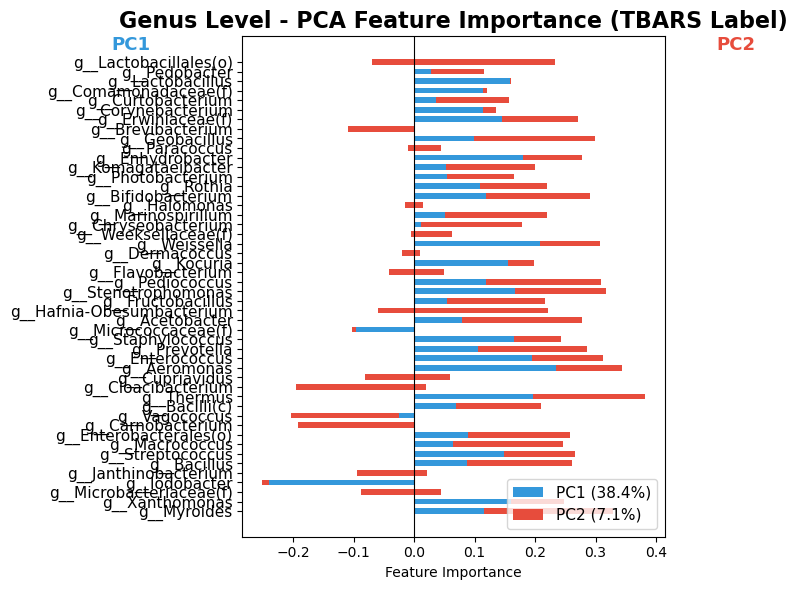

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Genus level mirror bar chart (TBARS 기준)
level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_score_tbars[level_name]['Feature'].tolist()
if not vip_features:
    print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
else:
    X_vip = level_data['features'][vip_features]

    # PCA
    pca = PCA(n_components=2)
    pca.fit(X_vip)
    loadings = pca.components_.T  # shape: (feature, PC)
    exp_var = pca.explained_variance_ratio_ * 100

    feature_names = vip_features
    pc1_loadings = loadings[:, 0]
    pc2_loadings = loadings[:, 1]

    ind = np.arange(len(feature_names))
    height = 0.6

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(ind, pc1_loadings, height, color='#3498db', label=f'PC1 ({exp_var[0]:.1f}%)')
    ax.barh(ind, pc2_loadings, height, color='#e74c3c', label=f'PC2 ({exp_var[1]:.1f}%)', left=pc1_loadings)

    ax.set_yticks(ind)
    ax.set_yticklabels(feature_names, fontsize=11)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Genus Level - PCA Feature Importance (TBARS Label)', fontsize=16, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.legend(loc='lower right', fontsize=11)
    ax.text(-0.5, len(feature_names)+0.2, 'PC1', color='#3498db', fontsize=13, fontweight='bold')
    ax.text(0.5, len(feature_names)+0.2, 'PC2', color='#e74c3c', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

## TPC 분류 모델 학습 


=== Phylum Level 모델 학습 시작 (VIP>1.0 Feature) ===

--- RandomForest 학습 ---
Train Acc: 0.875, Test Acc: 0.630
Train F1: 0.867, Test F1: 0.570
Overfitting Acc: 0.245, Overfitting F1: 0.296
Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

--- XGBoost 학습 ---
Train Acc: 0.935, Test Acc: 0.630
Train F1: 0.932, Test F1: 0.589
Overfitting Acc: 0.306, Overfitting F1: 0.343
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.648, Test Acc: 0.704
Train F1: 0.625, Test F1: 0.690
Overfitting Acc: -0.056, Overfitting F1: -0.064
Best Params: {'svc__C': 0.5, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}

--- LogisticRegression 학습 ---


/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.644, Test Acc: 0.741
Train F1: 0.623, Test F1: 0.728
Overfitting Acc: -0.097, Overfitting F1: -0.105
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.8, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.736, Test Acc: 0.630
Train F1: 0.709, Test F1: 0.585
Overfitting Acc: 0.106, Overfitting F1: 0.124
Best Params: {'n_neighbors': 7, 'weights': 'uniform'}

=== Class Level 모델 학습 시작 (VIP>1.0 Feature) ===

--- RandomForest 학습 ---
Train Acc: 0.778, Test Acc: 0.685
Train F1: 0.755, Test F1: 0.609
Overfitting Acc: 0.093, Overfitting F1: 0.146
Best Params: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100}

--- XGBoost 학습 ---
Train Acc: 0.995, Test Acc: 0.704
Train F1: 0.995, Test F1: 0.674
Overfitting Acc: 0.292, Overfitting F1: 0.321
Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

--- SVC 학습 ---
Train Acc: 0.741, Test Acc: 0.685
Tr

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.810, Test Acc: 0.796
Train F1: 0.773, Test F1: 0.760
Overfitting Acc: 0.014, Overfitting F1: 0.013
Best Params: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}

--- XGBoost 학습 ---
Train Acc: 0.991, Test Acc: 0.741
Train F1: 0.990, Test F1: 0.699
Overfitting Acc: 0.250, Overfitting F1: 0.291
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.838, Test Acc: 0.722
Train F1: 0.819, Test F1: 0.670
Overfitting Acc: 0.116, Overfitting F1: 0.149
Best Params: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}

--- LogisticRegression 학습 ---


...

Train Acc: 0.764, Test Acc: 0.759
Train F1: 0.746, Test F1: 0.734
Overfitting Acc: 0.005, Overfitting F1: 0.013
Best Params: {'lr__C': 2, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.2, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.995, Test Acc: 0.741
Train F1: 0.995, Test F1: 0.718
Overfitting Acc: 0.255, Overfitting F1: 0.277
Best Params: {'n_neighbors': 7, 'weights': 'distance'}

=== Family Level 모델 학습 시작 (VIP>1.0 Feature) ===

--- RandomForest 학습 ---
Train Acc: 0.944, Test Acc: 0.833
Train F1: 0.941, Test F1: 0.819
Overfitting Acc: 0.111, Overfitting F1: 0.123
Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}

--- XGBoost 학습 ---
Train Acc: 0.981, Test Acc: 0.870
Train F1: 0.981, Test F1: 0.854
Overfitting Acc: 0.111, Overfitting F1: 0.127
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.866, Test Acc: 0.815
Tra

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.866, Test Acc: 0.870
Train F1: 0.857, Test F1: 0.865
Overfitting Acc: -0.005, Overfitting F1: -0.008
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.8, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.889, Test Acc: 0.796
Train F1: 0.881, Test F1: 0.779
Overfitting Acc: 0.093, Overfitting F1: 0.102
Best Params: {'n_neighbors': 3, 'weights': 'uniform'}

=== Genus Level 모델 학습 시작 (VIP>1.0 Feature) ===

--- RandomForest 학습 ---
Train Acc: 0.944, Test Acc: 0.833
Train F1: 0.941, Test F1: 0.812
Overfitting Acc: 0.111, Overfitting F1: 0.129
Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

--- XGBoost 학습 ---
Train Acc: 0.995, Test Acc: 0.833
Train F1: 0.995, Test F1: 0.819
Overfitting Acc: 0.162, Overfitting F1: 0.176
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

--- SVC 학습 ---
Train Acc: 0.889, Test Acc: 0.833
Tr

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.898, Test Acc: 0.889
Train F1: 0.896, Test F1: 0.881
Overfitting Acc: 0.009, Overfitting F1: 0.015
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.2, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.866, Test Acc: 0.778
Train F1: 0.853, Test F1: 0.743
Overfitting Acc: 0.088, Overfitting F1: 0.110
Best Params: {'n_neighbors': 5, 'weights': 'uniform'}

=== 모든 모델 학습 및 평가 완료 ===


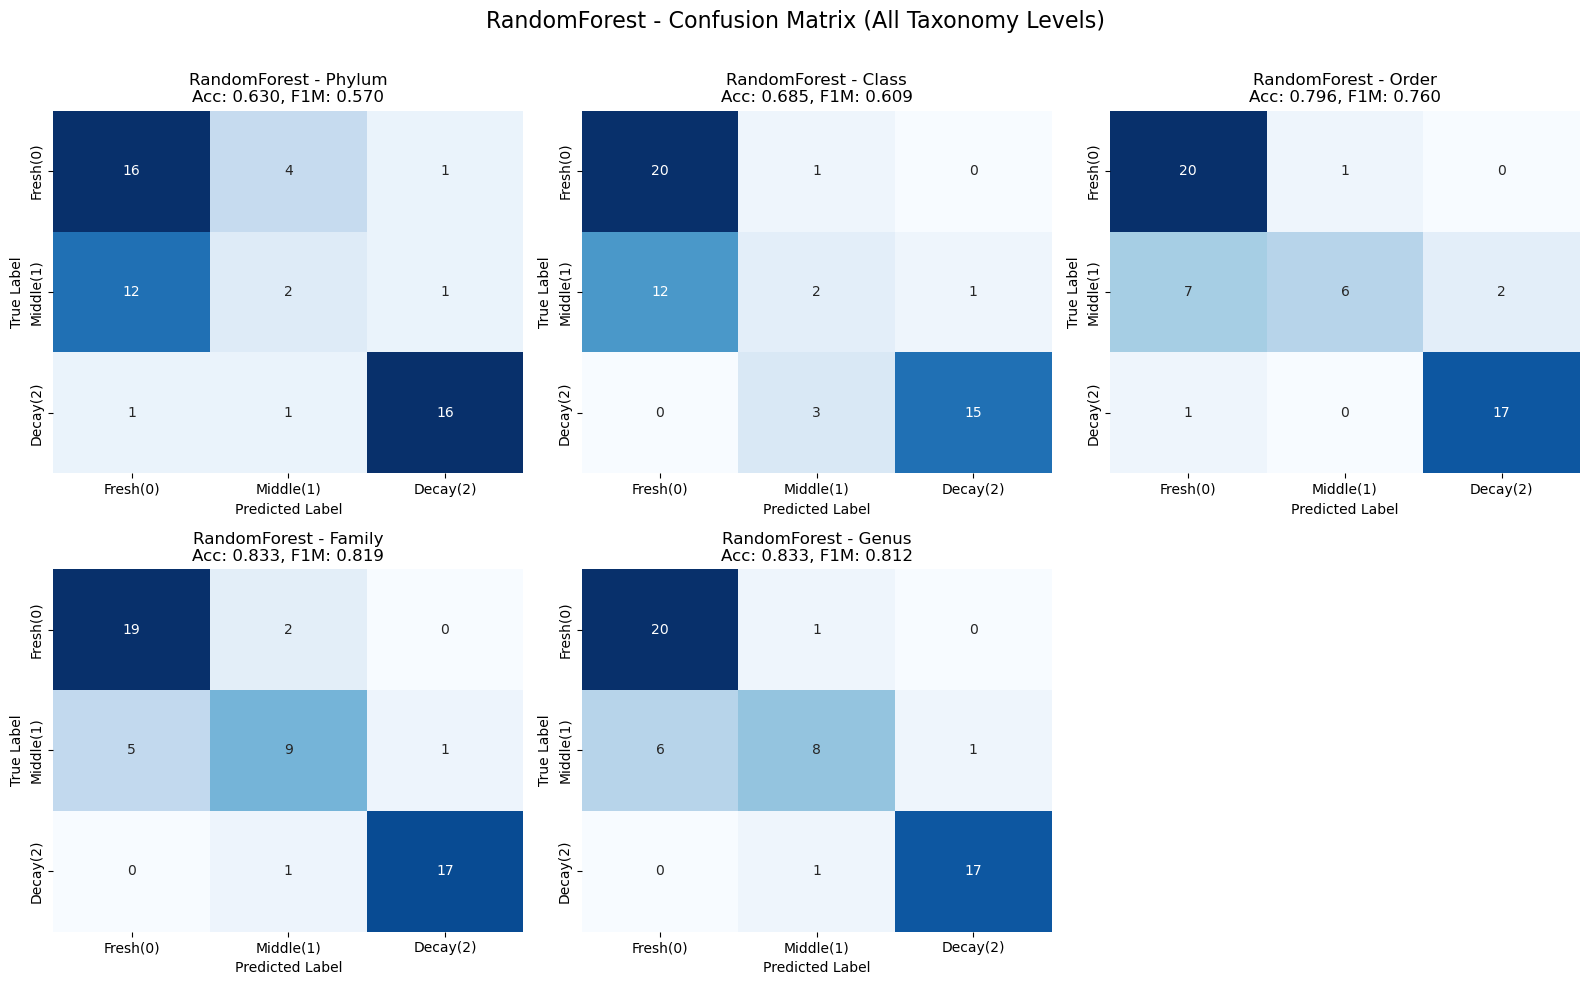

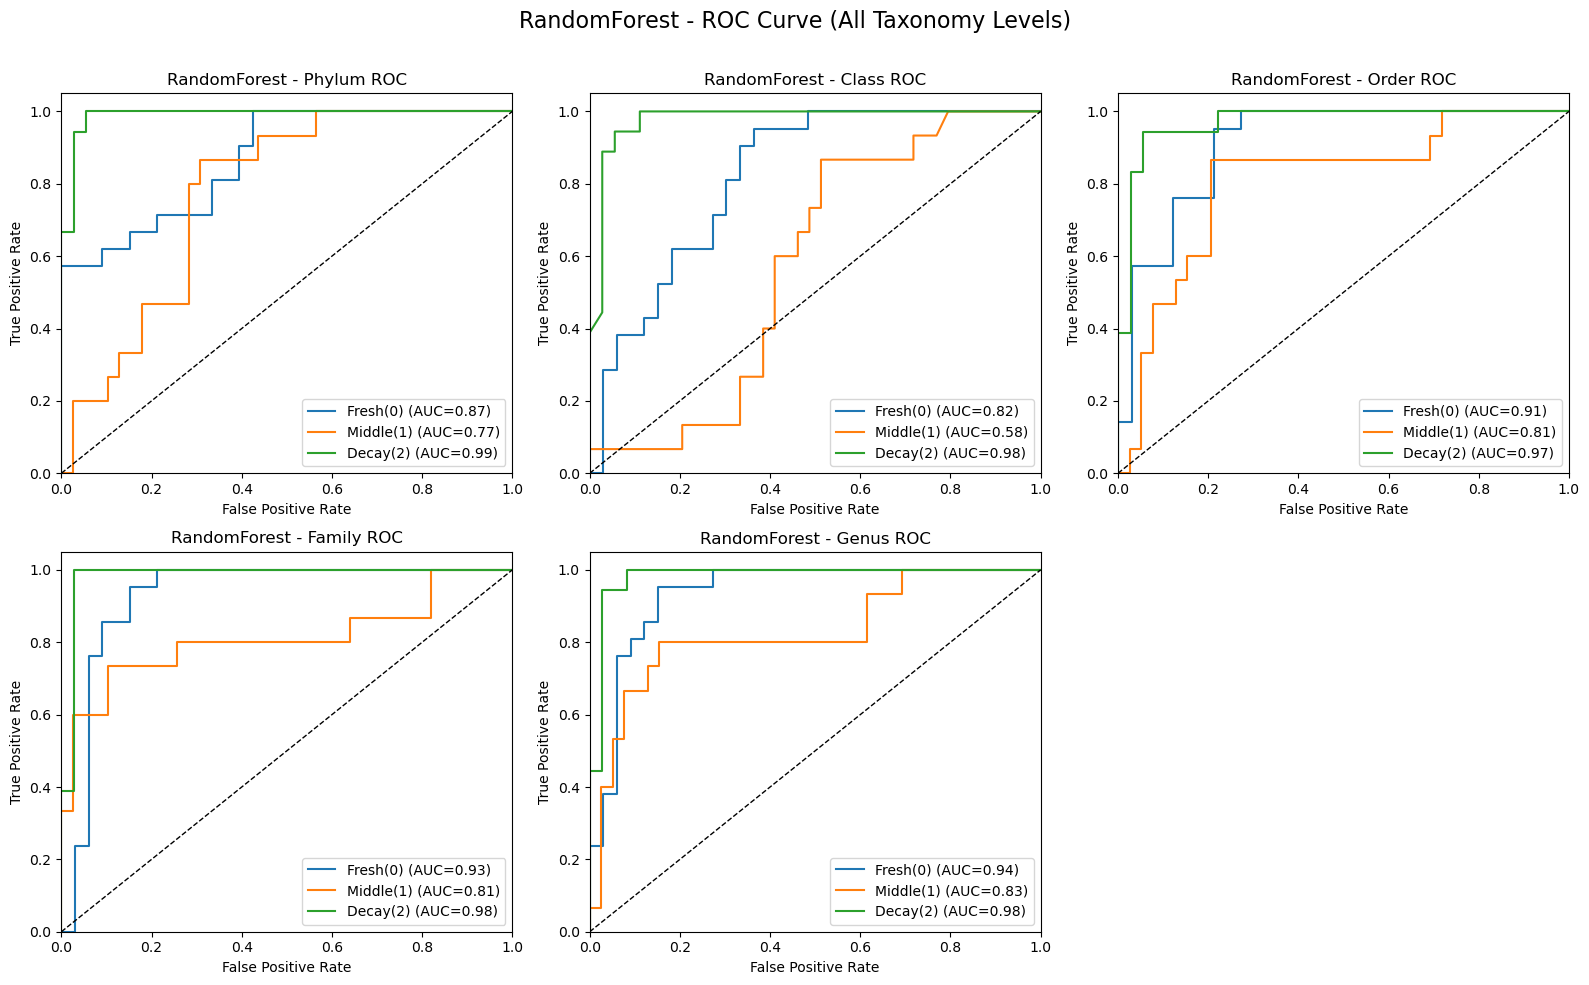

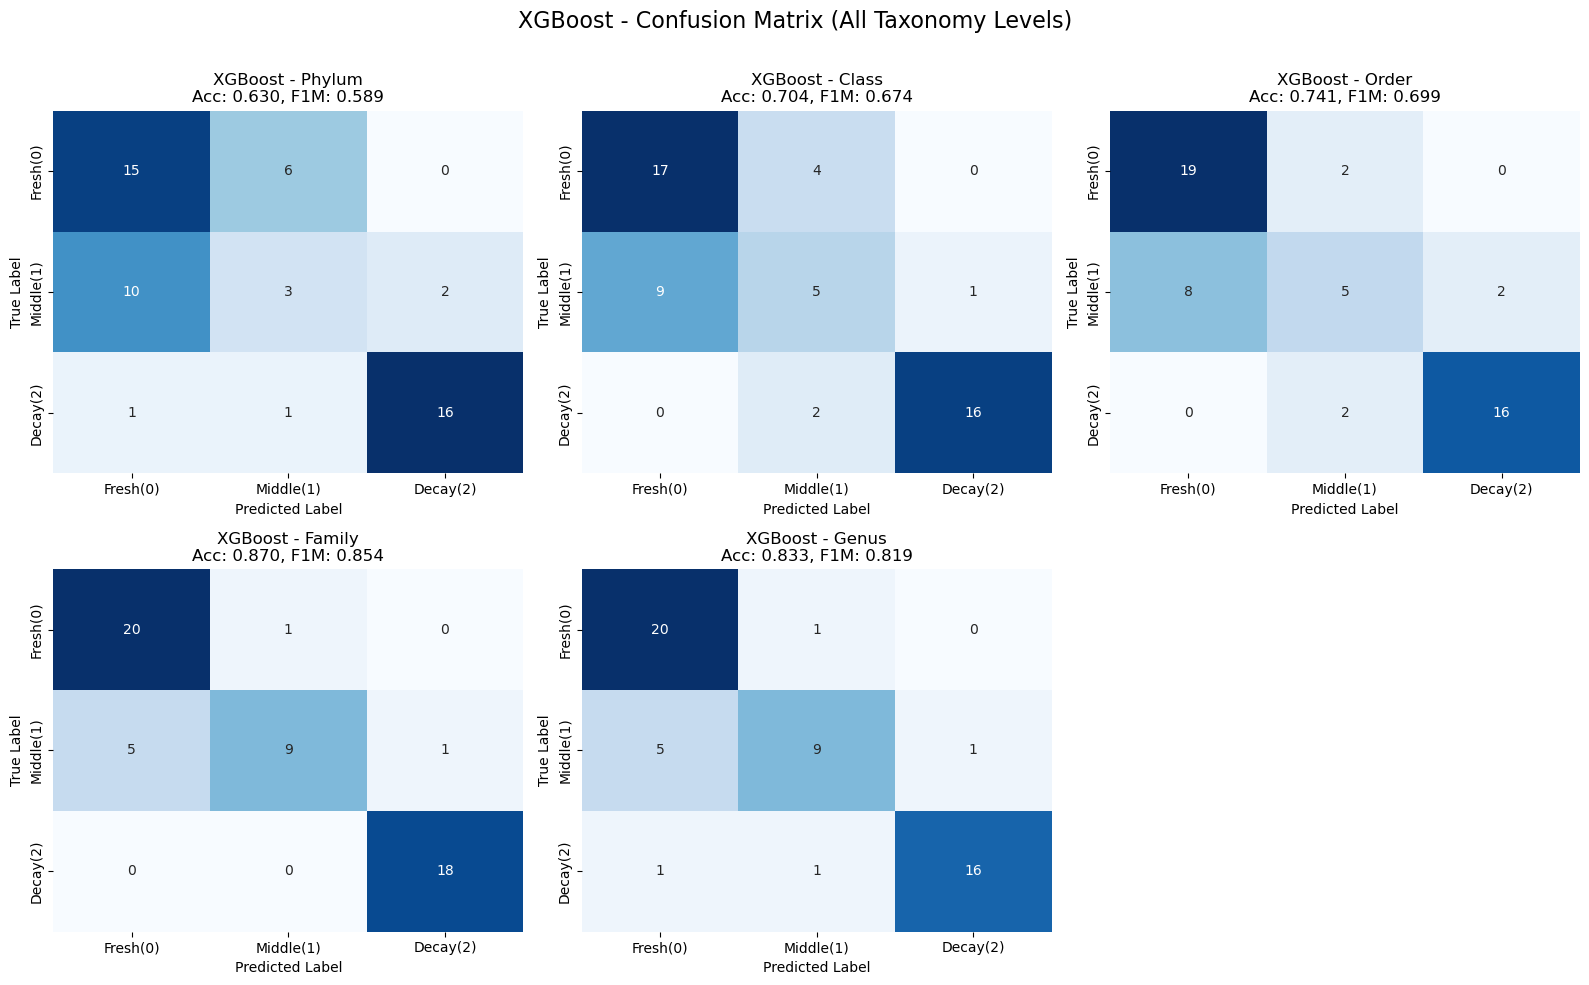

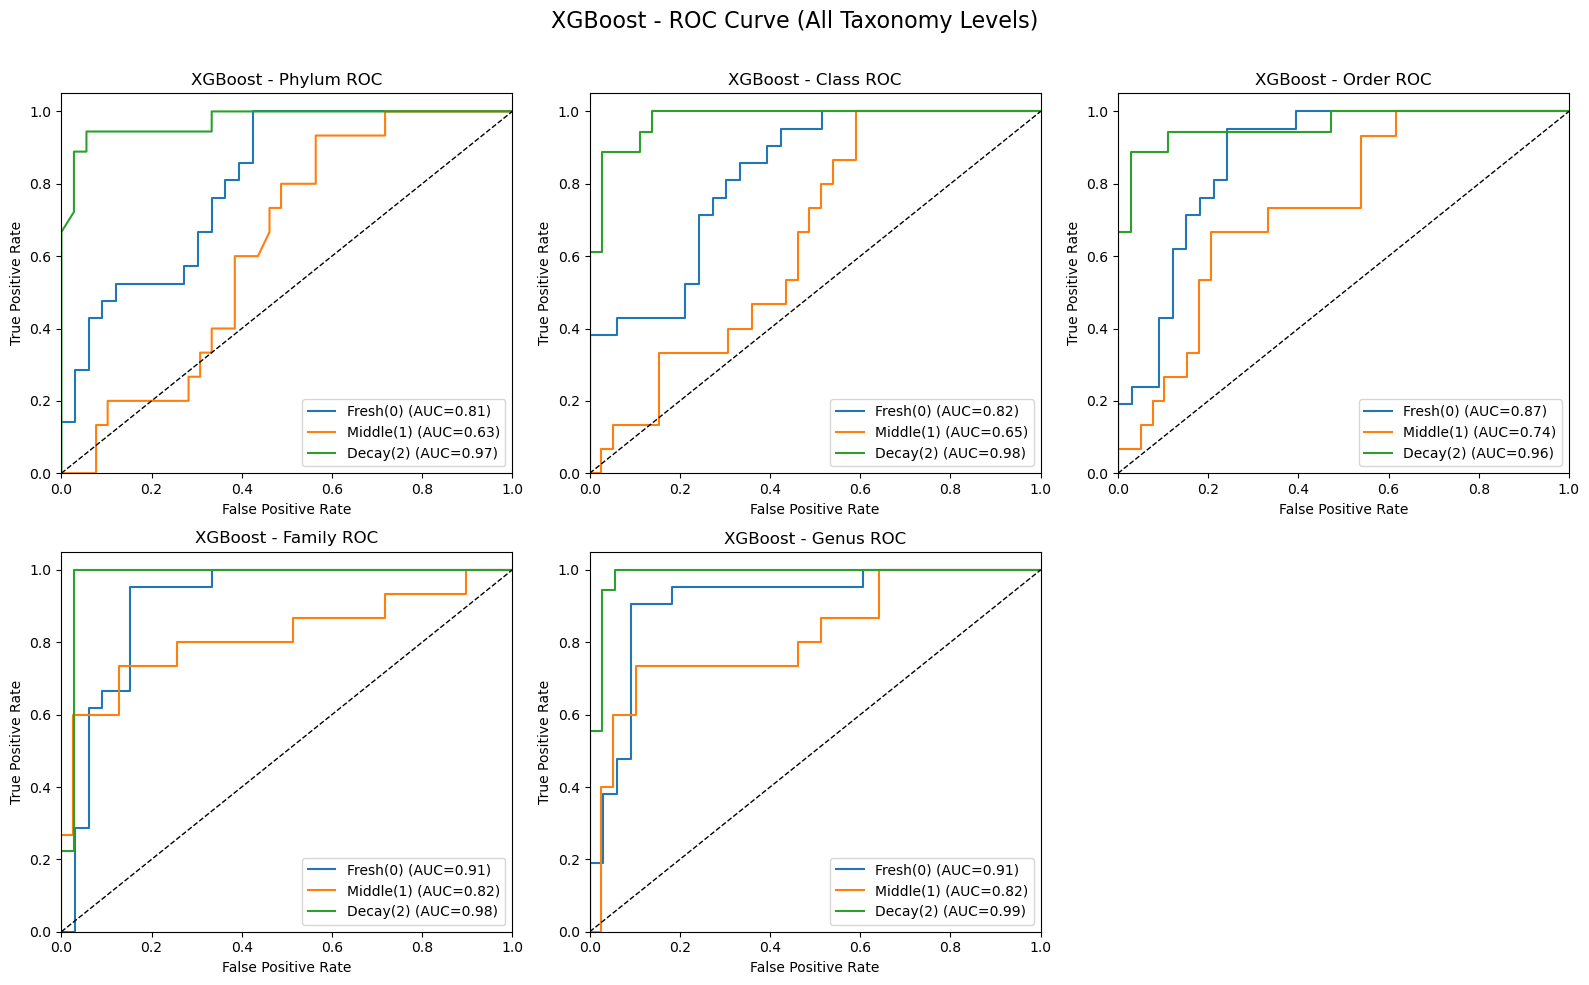

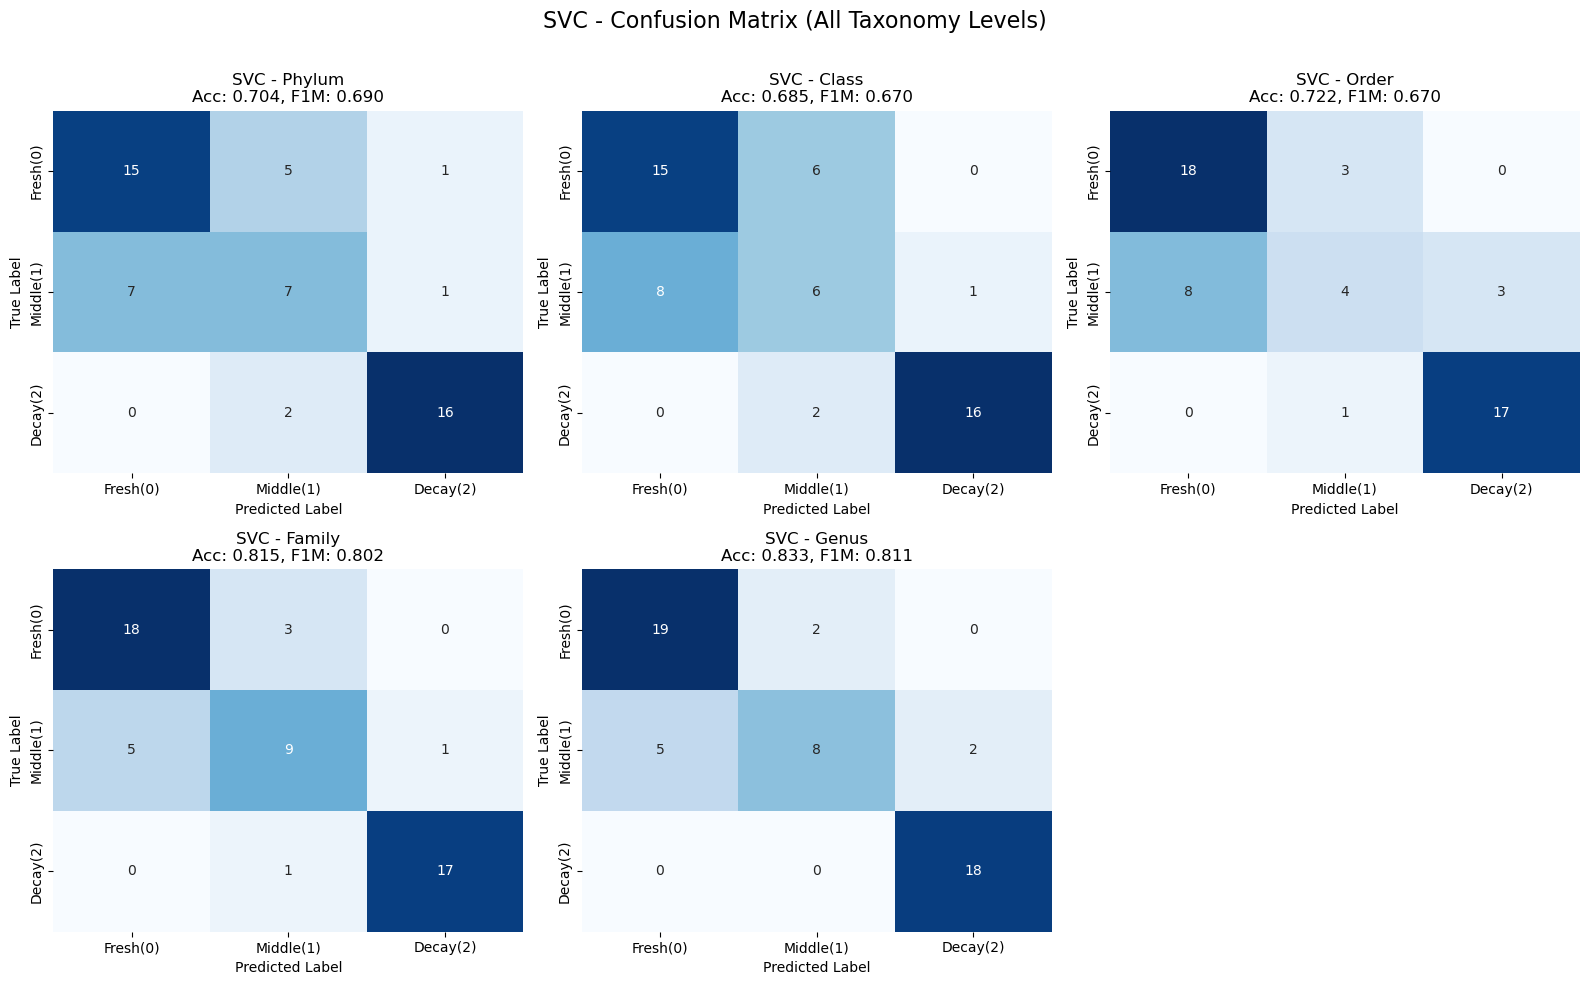

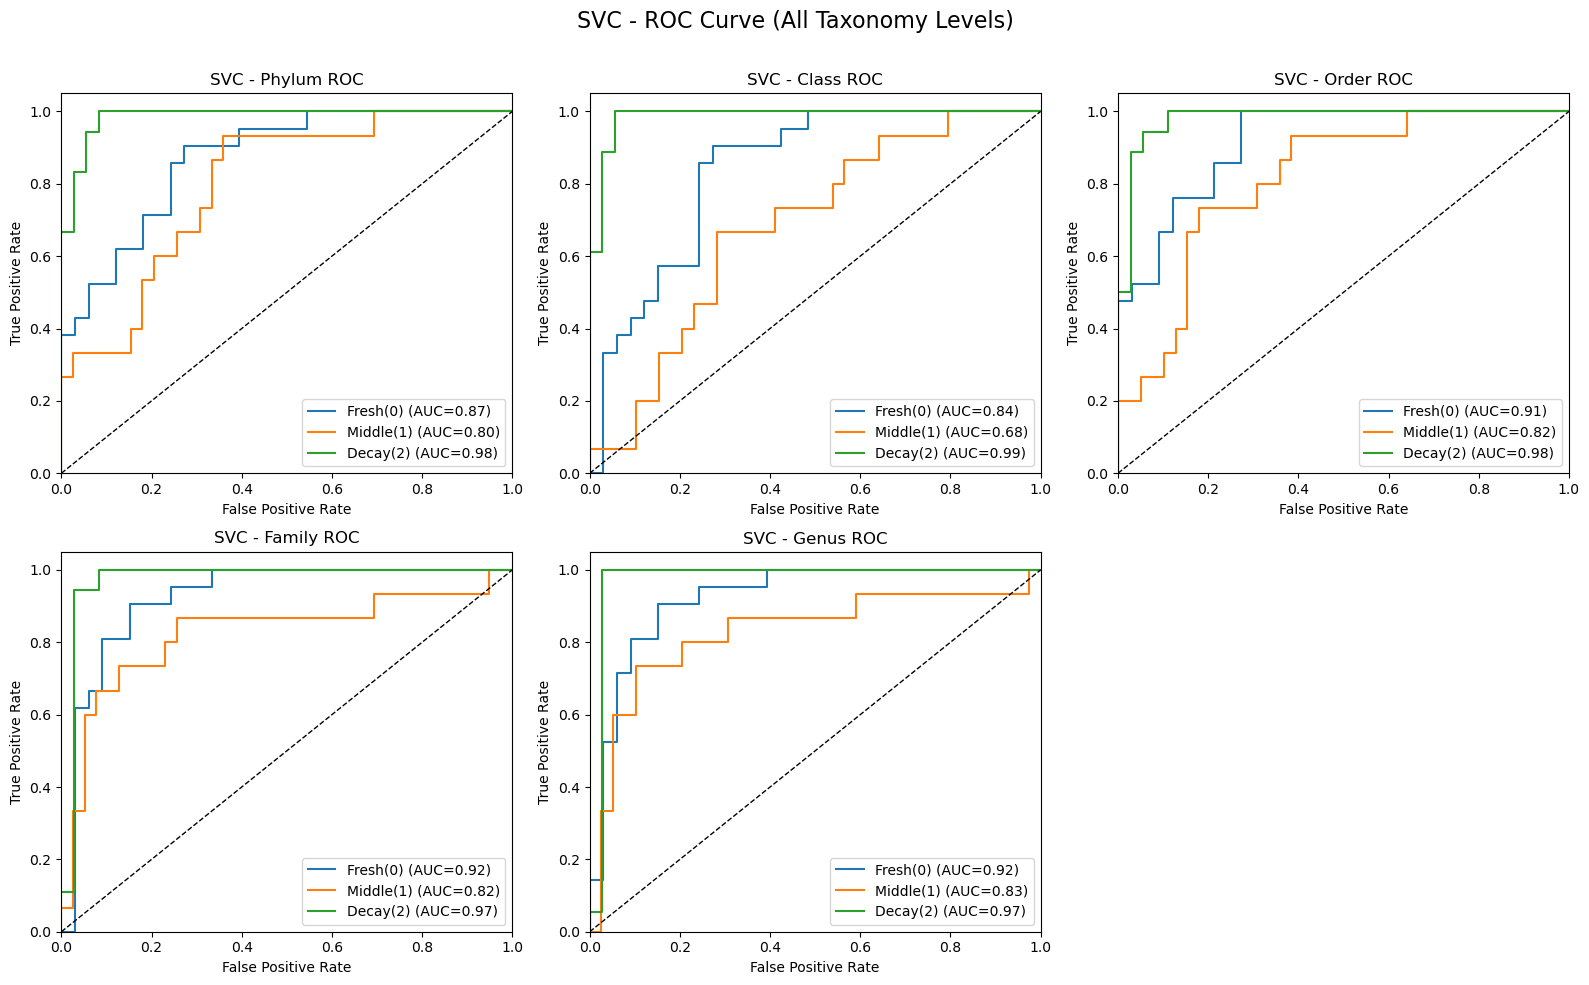

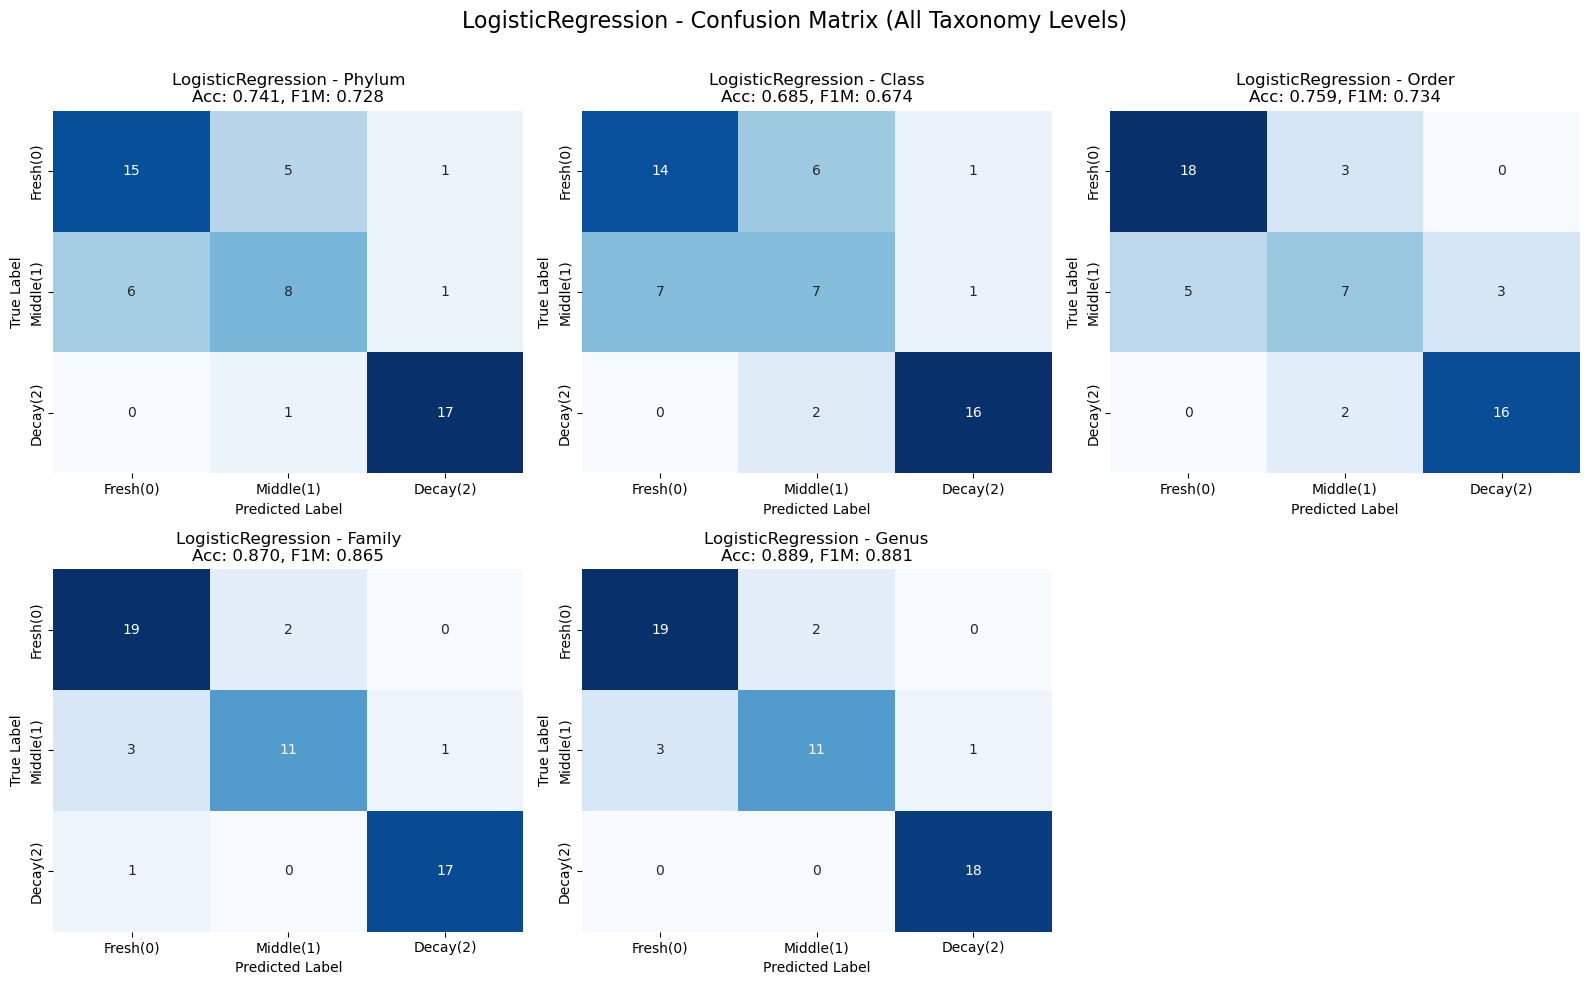

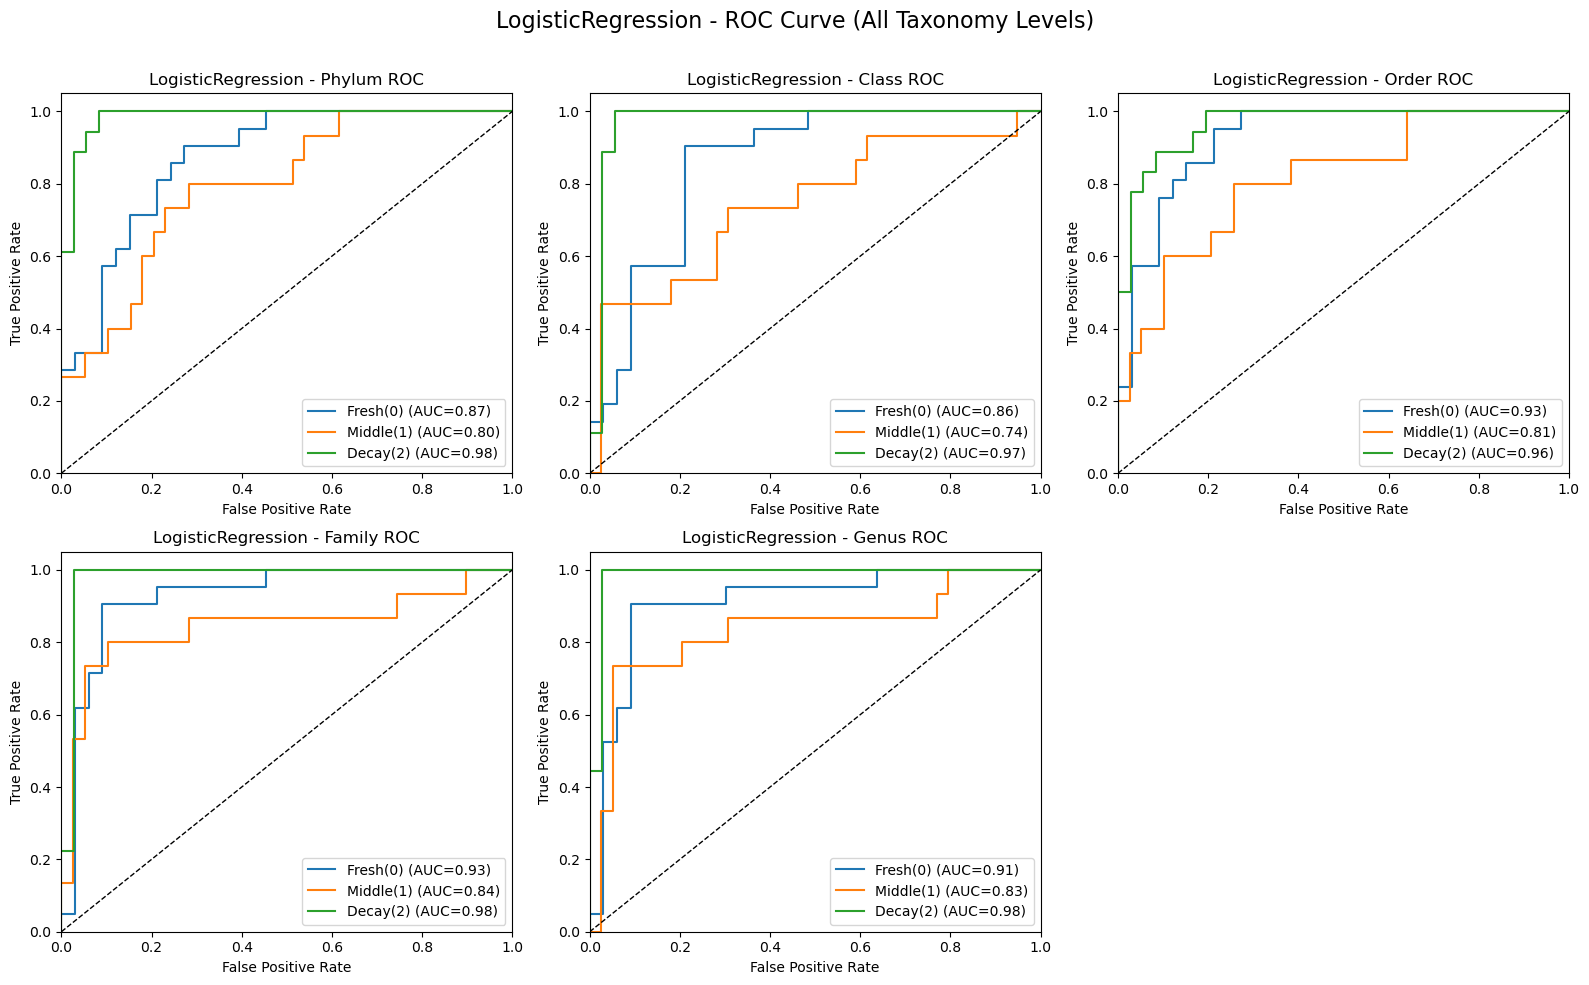

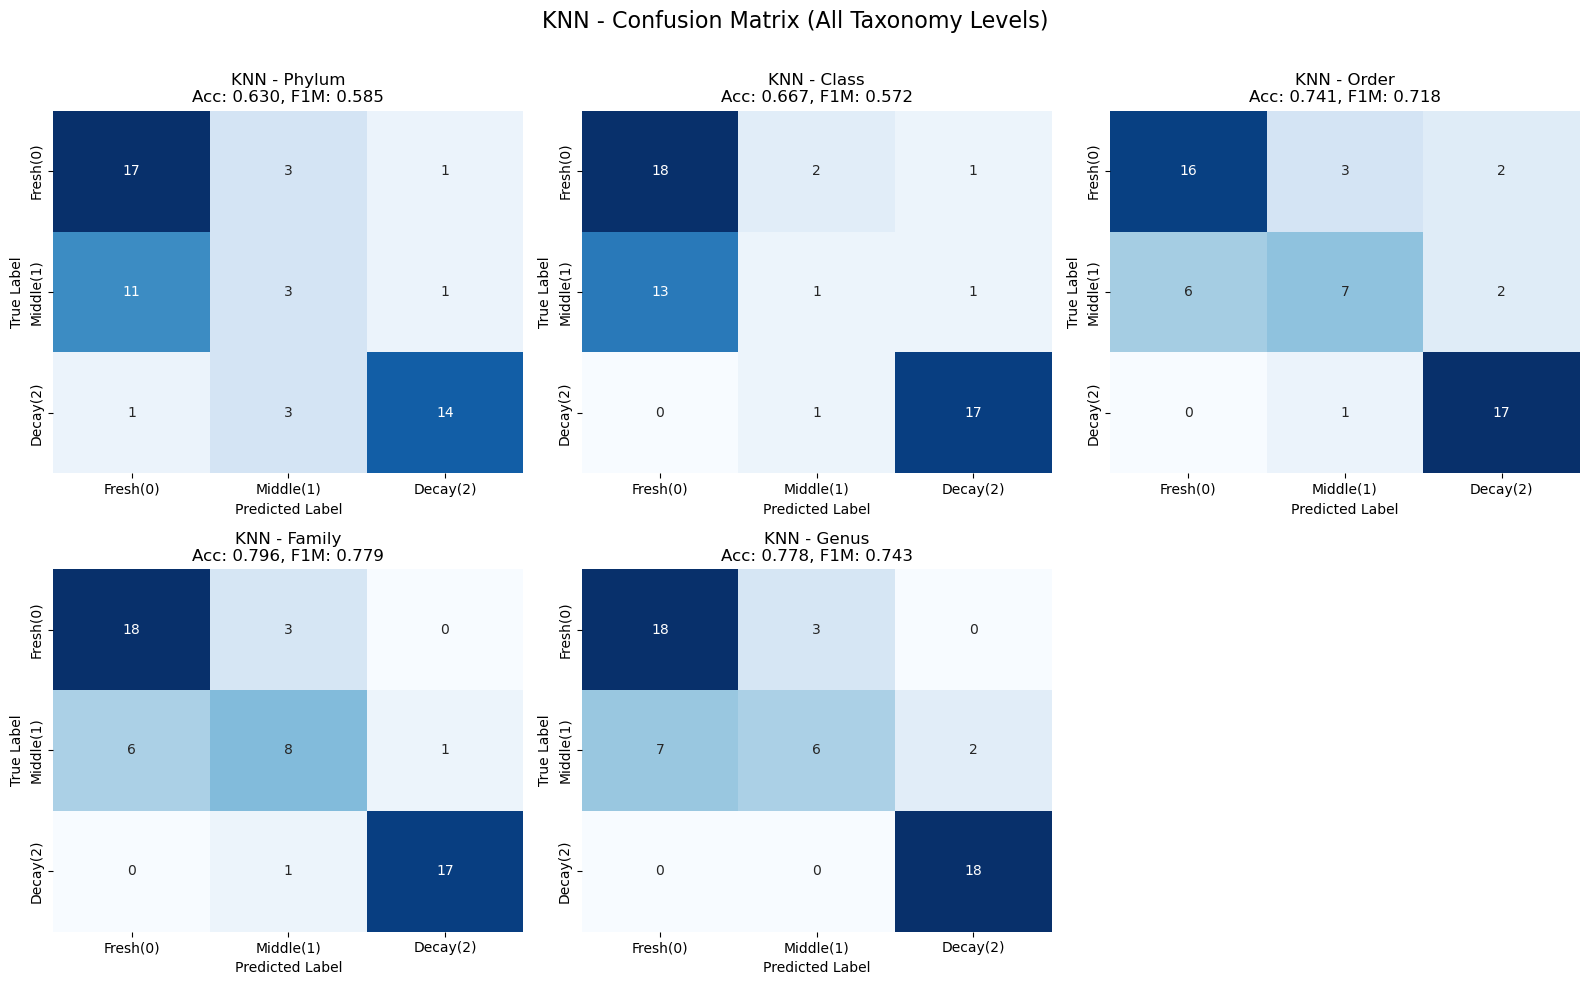

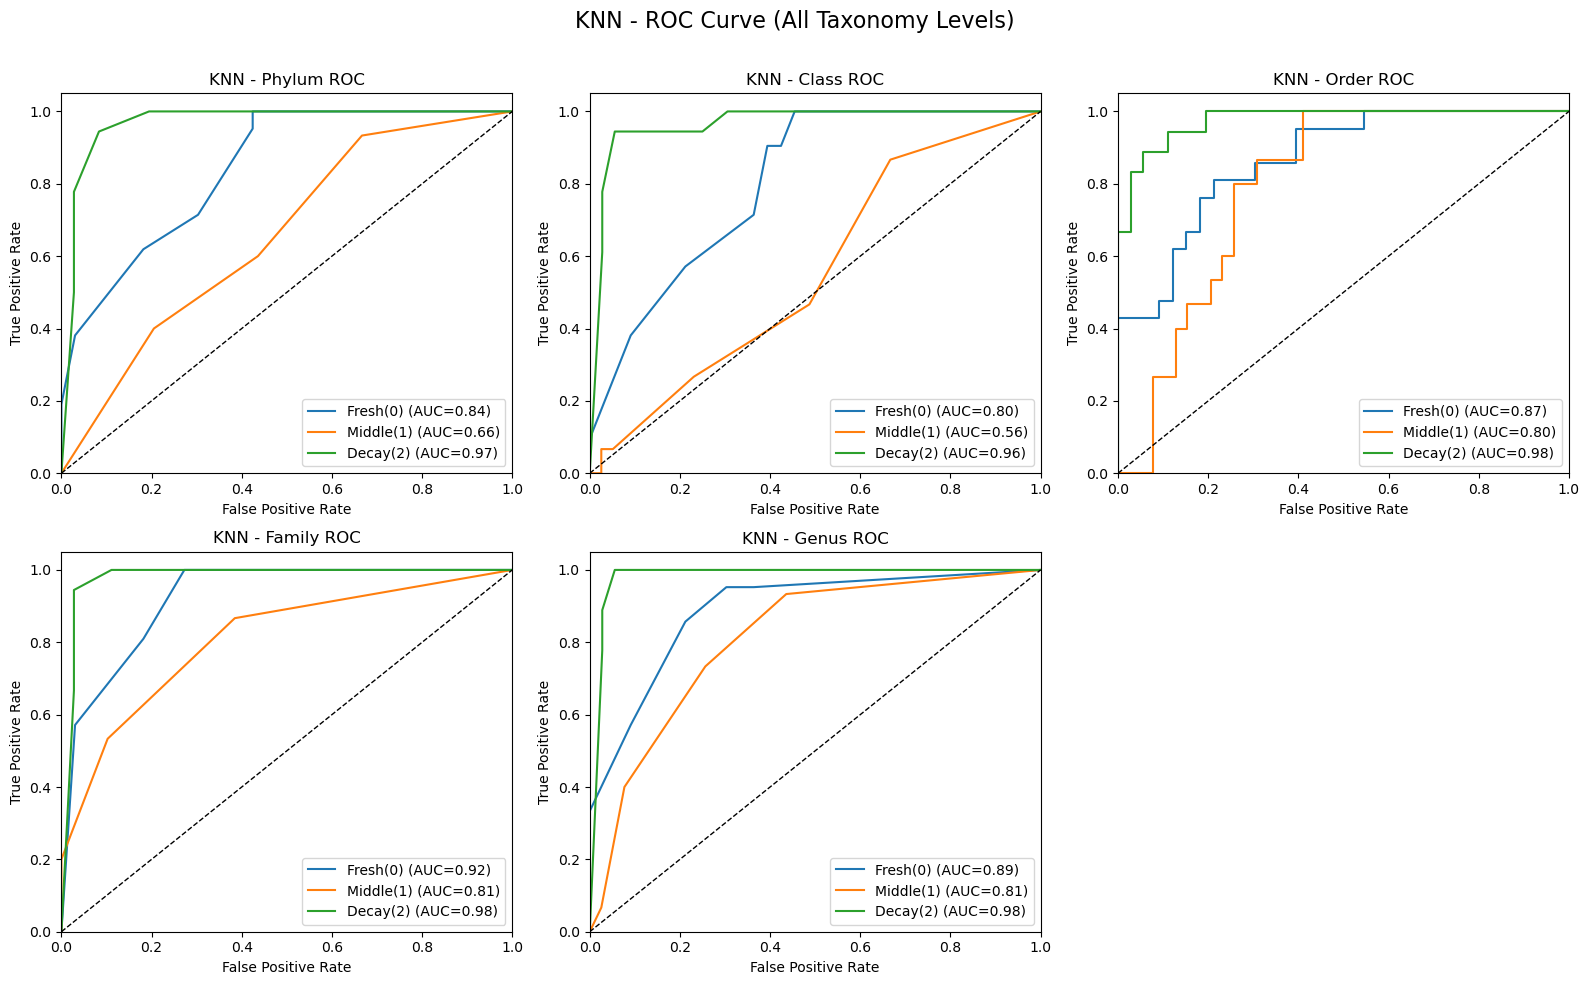

In [12]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# 사용할 모델과 파라미터 그리드 정의 (Pipeline 적용, prefix 적용)
model_configs = {
    "RandomForest": {
        "model": RandomForestClassifier,
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "min_samples_split": [2, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier,
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1]
        }
    },
    "SVC": {
        "model": lambda: Pipeline([
            ('scaler', StandardScaler()),
            ('svc', SVC(probability=True, class_weight="balanced"))
        ]),
        "params": {
            "svc__C": [0.5, 1, 2],
            "svc__gamma": ["scale", "auto"],
            "svc__kernel": ["rbf"]
        }
    },
    "LogisticRegression": {
        "model": lambda: Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression())
        ]),
        "params": {
            "lr__penalty": ["elasticnet"],
            "lr__solver": ["saga"],
            "lr__l1_ratio": [0.2, 0.5, 0.8],
            "lr__C": [0.5, 1, 2],
            "lr__max_iter": [500],
            "lr__class_weight": ["balanced"],
            "lr__multi_class": ["multinomial"]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier,
        "params": {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
        }
    }
}

taxonomy_levels = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

all_model_results = {}

for level_name in taxonomy_levels:
    print(f"\n{'='*60}\n=== {level_name} Level 모델 학습 시작 (VIP>1.0 Feature) ===\n{'='*60}")
    # 데이터 준비
    level_data = get_level_data(level_name)
    vip_features = vip_over1_dict[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
        continue
    X = level_data['features'][vip_features].values
    y = tpc_labeling(level_data['tpc'].values)

    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    all_model_results[level_name] = {}

    for model_name, config in model_configs.items():
        print(f"\n--- {model_name} 학습 ---")
        model = config["model"]() if callable(config["model"]) else config["model"]()
        param_grid = config["params"]

        grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        best_params = grid.best_params_

        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        train_f1 = f1_score(y_train, y_train_pred, average='macro')
        test_f1 = f1_score(y_test, y_test_pred, average='macro')
        overfit_acc = train_acc - test_acc
        overfit_f1 = train_f1 - test_f1

        all_model_results[level_name][model_name] = {
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "train_f1_score": train_f1,
            "test_f1_score": test_f1,
            "Overfitting_Acc": overfit_acc,
            "Overfitting_F1": overfit_f1,
            "Best_Params": best_params,
            "Best_Model": best_model,
            "GridSearchCV": grid,
            "X_test": X_test,
            "y_test": y_test
        }

        print(f"Train Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}")
        print(f"Train F1: {train_f1:.3f}, Test F1: {test_f1:.3f}")
        print(f"Overfitting Acc: {overfit_acc:.3f}, Overfitting F1: {overfit_f1:.3f}")
        print(f"Best Params: {best_params}")

print("\n=== 모든 모델 학습 및 평가 완료 ===")

# Confusion Matrix & ROC Curve (숫자 표기)
model_list = ["RandomForest", "XGBoost", "SVC", "LogisticRegression", "KNN"]
label_order = [0, 1, 2]  # Fresh(0), Middle(1), Decay(2)
label_names = ["Fresh(0)", "Middle(1)", "Decay(2)"]

for model in model_list:
    # 1. Confusion Matrix (3x2 subplot, 숫자 표기)
    fig_cm, axes_cm = plt.subplots(2, 3, figsize=(16, 10))
    axes_cm = axes_cm.flatten()
    for i, level in enumerate(taxonomy_levels):
        if level not in all_model_results or model not in all_model_results[level]:
            axes_cm[i].set_axis_off()
            continue
        best_model = all_model_results[level][model]["Best_Model"]
        X_test = all_model_results[level][model]["X_test"]
        y_test = all_model_results[level][model]["y_test"]
        y_pred = best_model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred, labels=label_order)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes_cm[i], cbar=False,
                    xticklabels=label_names, yticklabels=label_names, vmin=0)
        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average='macro')
        axes_cm[i].set_title(f"{model} - {level}\nAcc: {acc:.3f}, F1M: {f1m:.3f}")
        axes_cm[i].set_xlabel("Predicted Label")
        axes_cm[i].set_ylabel("True Label")
    axes_cm[5].axis('off')
    plt.suptitle(f"{model} - Confusion Matrix (All Taxonomy Levels)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    # 2. ROC Curve (3x2 subplot, 숫자 표기)
    fig_roc, axes_roc = plt.subplots(2, 3, figsize=(16, 10))
    axes_roc = axes_roc.flatten()
    for i, level in enumerate(taxonomy_levels):
        if level not in all_model_results or model not in all_model_results[level]:
            axes_roc[i].set_axis_off()
            continue
        best_model = all_model_results[level][model]["Best_Model"]
        X_test = all_model_results[level][model]["X_test"]
        y_test = all_model_results[level][model]["y_test"]
        y_test_bin = label_binarize(y_test, classes=label_order)
        y_score = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None
        ax = axes_roc[i]
        if y_score is not None:
            for j in range(3):
                fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_score[:, j])
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, label=f"{label_names[j]} (AUC={roc_auc:.2f})")
            ax.plot([0, 1], [0, 1], 'k--', lw=1)
            ax.set_xlim([0.0, 1.0])
            ax.set_ylim([0.0, 1.05])
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title(f"{model} - {level} ROC")
            ax.legend(loc="lower right")
        else:
            ax.text(0.5, 0.5, "No predict_proba", ha='center', va='center')
            ax.set_axis_off()
    axes_roc[5].axis('off')
    plt.suptitle(f"{model} - ROC Curve (All Taxonomy Levels)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## SHAP 후분석

## TBARS 분류 모델 학습 


=== Phylum Level 모델 학습 시작 (VIP>1.0 Feature, TBARS) ===

--- RandomForest 학습 ---
Train Acc: 0.657, Test Acc: 0.611
Train F1: 0.568, Test F1: 0.447
Overfitting Acc: 0.046, Overfitting F1: 0.120
Best Params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}

--- XGBoost 학습 ---
Train Acc: 0.907, Test Acc: 0.519
Train F1: 0.907, Test F1: 0.476
Overfitting Acc: 0.389, Overfitting F1: 0.431
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}

--- SVC 학습 ---
Train Acc: 0.616, Test Acc: 0.574
Train F1: 0.568, Test F1: 0.532
Overfitting Acc: 0.042, Overfitting F1: 0.036
Best Params: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}

--- LogisticRegression 학습 ---


/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.546, Test Acc: 0.574
Train F1: 0.515, Test F1: 0.539
Overfitting Acc: -0.028, Overfitting F1: -0.024
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.2, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.722, Test Acc: 0.500
Train F1: 0.703, Test F1: 0.466
Overfitting Acc: 0.222, Overfitting F1: 0.237
Best Params: {'n_neighbors': 3, 'weights': 'uniform'}

=== Class Level 모델 학습 시작 (VIP>1.0 Feature, TBARS) ===

--- RandomForest 학습 ---
Train Acc: 0.685, Test Acc: 0.593
Train F1: 0.619, Test F1: 0.475
Overfitting Acc: 0.093, Overfitting F1: 0.144
Best Params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}

--- XGBoost 학습 ---
Train Acc: 0.935, Test Acc: 0.630
Train F1: 0.933, Test F1: 0.569
Overfitting Acc: 0.306, Overfitting F1: 0.364
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.611, Test Acc: 0

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.894, Test Acc: 0.722
Train F1: 0.892, Test F1: 0.696
Overfitting Acc: 0.171, Overfitting F1: 0.196
Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

--- XGBoost 학습 ---
Train Acc: 0.935, Test Acc: 0.722
Train F1: 0.932, Test F1: 0.704
Overfitting Acc: 0.213, Overfitting F1: 0.228
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.722, Test Acc: 0.685
Train F1: 0.703, Test F1: 0.653
Overfitting Acc: 0.037, Overfitting F1: 0.049
Best Params: {'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}

--- LogisticRegression 학습 ---


...

Train Acc: 0.639, Test Acc: 0.667
Train F1: 0.612, Test F1: 0.647
Overfitting Acc: -0.028, Overfitting F1: -0.035
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.2, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.986, Test Acc: 0.630
Train F1: 0.984, Test F1: 0.583
Overfitting Acc: 0.356, Overfitting F1: 0.401
Best Params: {'n_neighbors': 3, 'weights': 'distance'}

=== Family Level 모델 학습 시작 (VIP>1.0 Feature, TBARS) ===

--- RandomForest 학습 ---
Train Acc: 0.778, Test Acc: 0.704
Train F1: 0.777, Test F1: 0.681
Overfitting Acc: 0.074, Overfitting F1: 0.096
Best Params: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}

--- XGBoost 학습 ---
Train Acc: 0.986, Test Acc: 0.741
Train F1: 0.984, Test F1: 0.715
Overfitting Acc: 0.245, Overfitting F1: 0.269
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

--- SVC 학습 ---
Train Acc: 0.806, Test Acc:

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.750, Test Acc: 0.574
Train F1: 0.735, Test F1: 0.520
Overfitting Acc: 0.176, Overfitting F1: 0.215
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.2, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.986, Test Acc: 0.630
Train F1: 0.984, Test F1: 0.597
Overfitting Acc: 0.356, Overfitting F1: 0.388
Best Params: {'n_neighbors': 7, 'weights': 'distance'}

=== Genus Level 모델 학습 시작 (VIP>1.0 Feature, TBARS) ===

--- RandomForest 학습 ---
Train Acc: 0.773, Test Acc: 0.667
Train F1: 0.764, Test F1: 0.628
Overfitting Acc: 0.106, Overfitting F1: 0.135
Best Params: {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}

--- XGBoost 학습 ---
Train Acc: 0.986, Test Acc: 0.611
Train F1: 0.984, Test F1: 0.579
Overfitting Acc: 0.375, Overfitting F1: 0.405
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

--- SVC 학습 ---
Train Acc: 0.824, Test Acc: 0.

/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1264: FutureWarning: 'multi_cla

Train Acc: 0.755, Test Acc: 0.685
Train F1: 0.740, Test F1: 0.643
Overfitting Acc: 0.069, Overfitting F1: 0.096
Best Params: {'lr__C': 0.5, 'lr__class_weight': 'balanced', 'lr__l1_ratio': 0.8, 'lr__max_iter': 500, 'lr__multi_class': 'multinomial', 'lr__penalty': 'elasticnet', 'lr__solver': 'saga'}

--- KNN 학습 ---
Train Acc: 0.676, Test Acc: 0.685
Train F1: 0.633, Test F1: 0.636
Overfitting Acc: -0.009, Overfitting F1: -0.004
Best Params: {'n_neighbors': 7, 'weights': 'uniform'}

=== 모든 모델 학습 및 평가 완료 ===


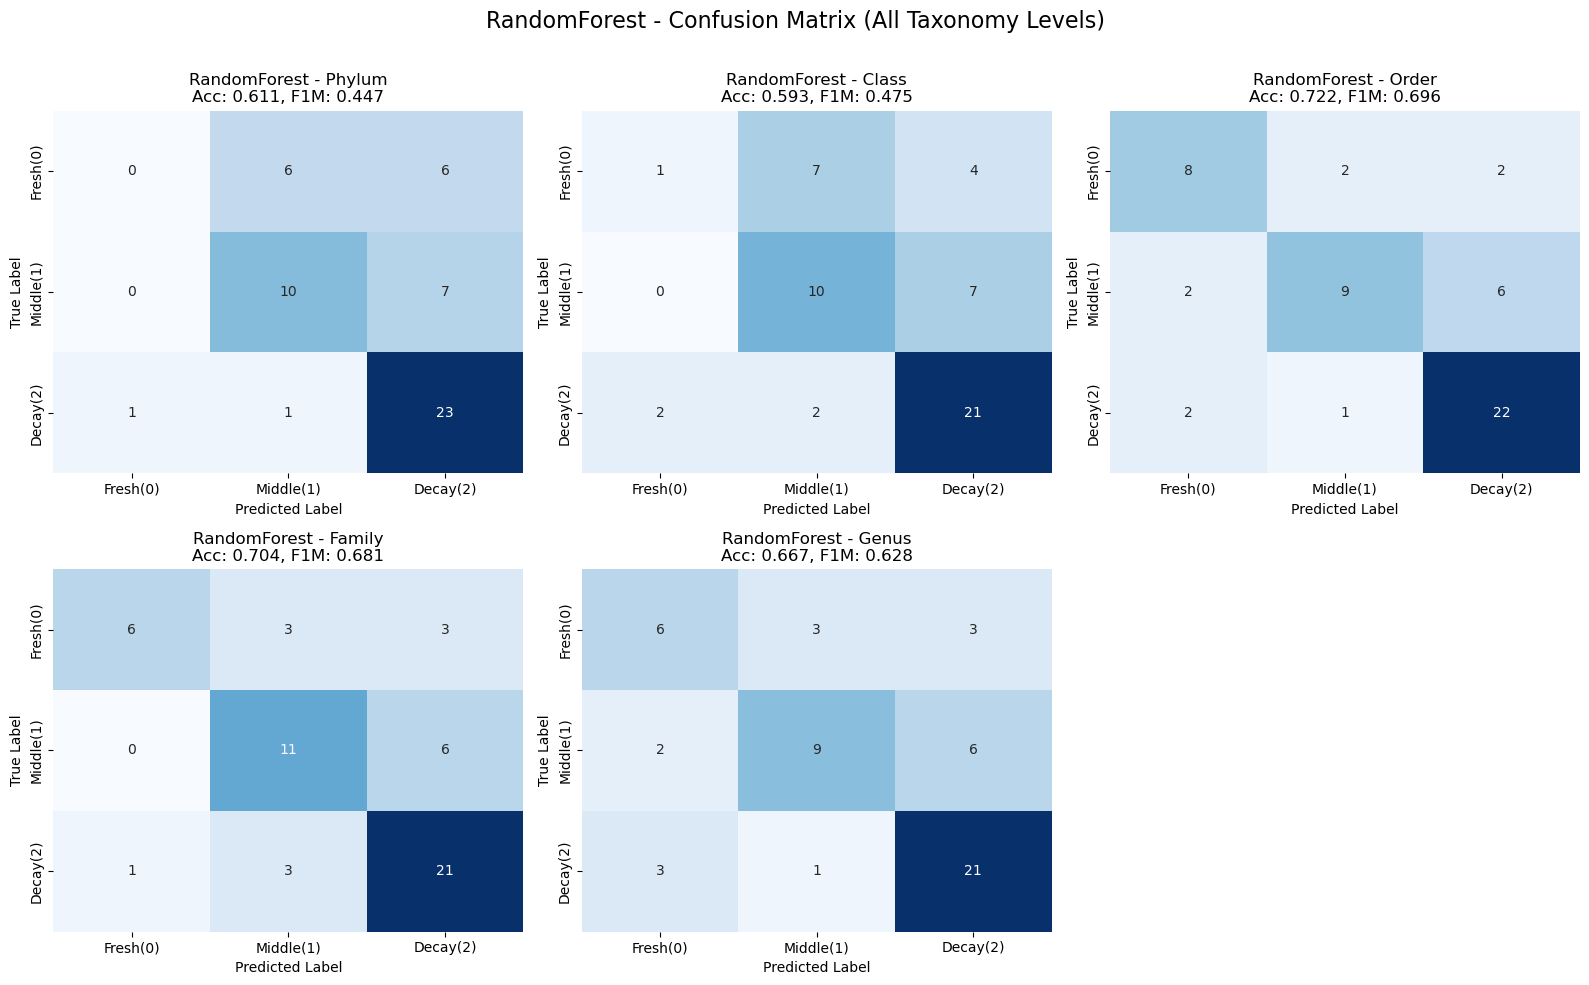

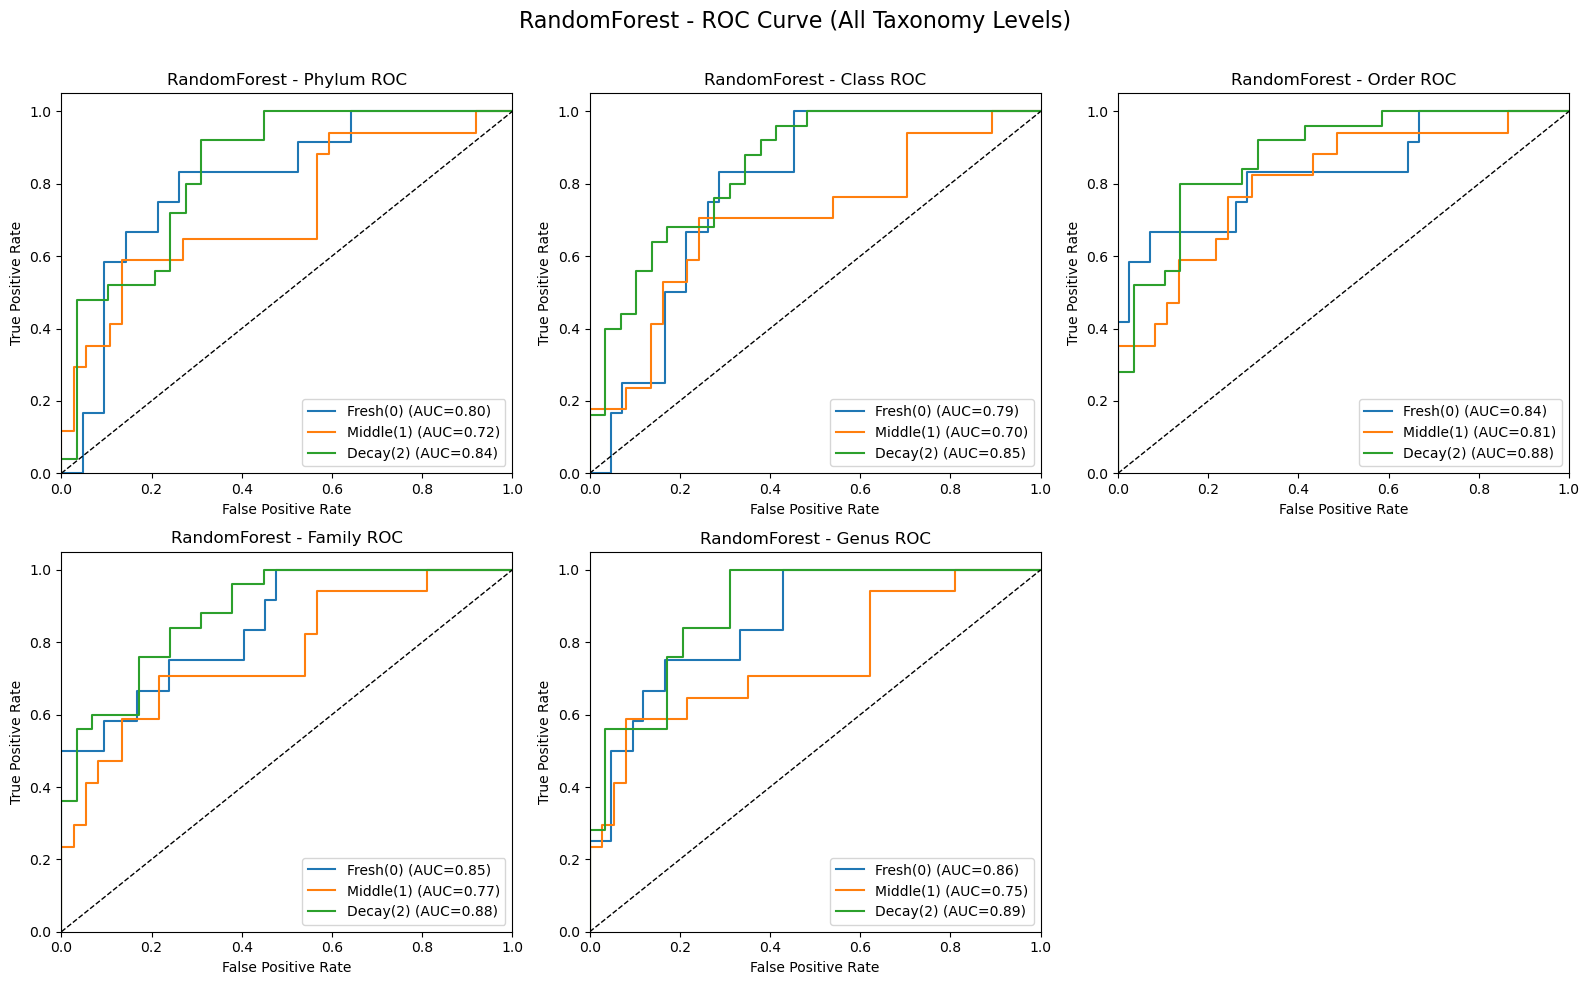

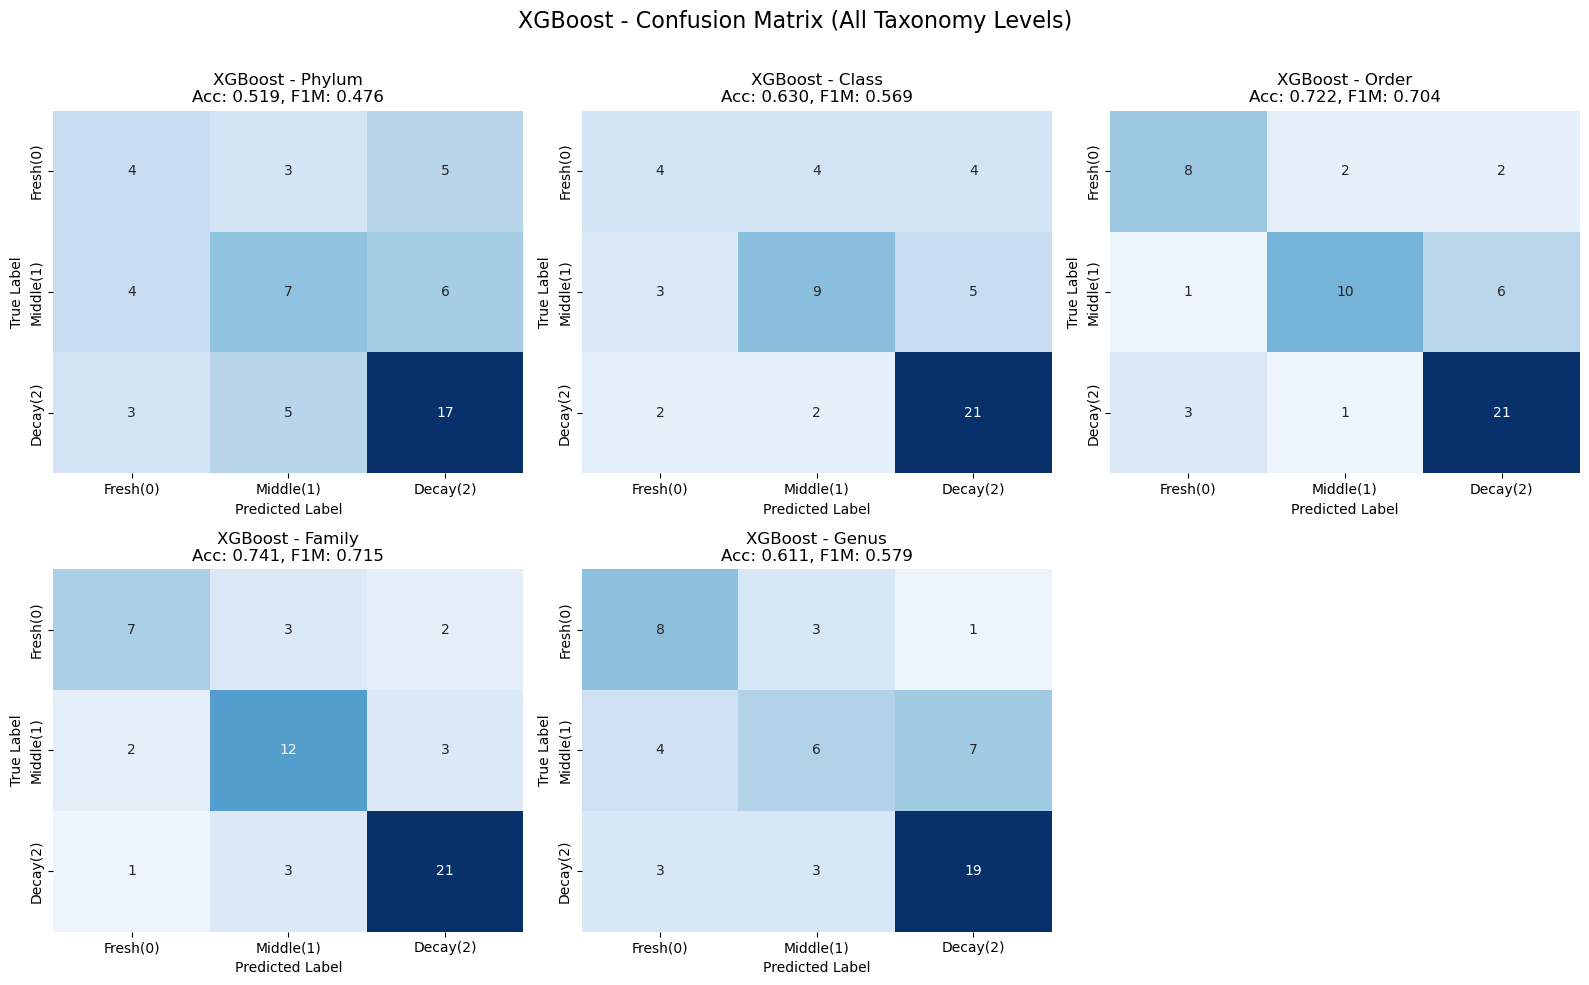

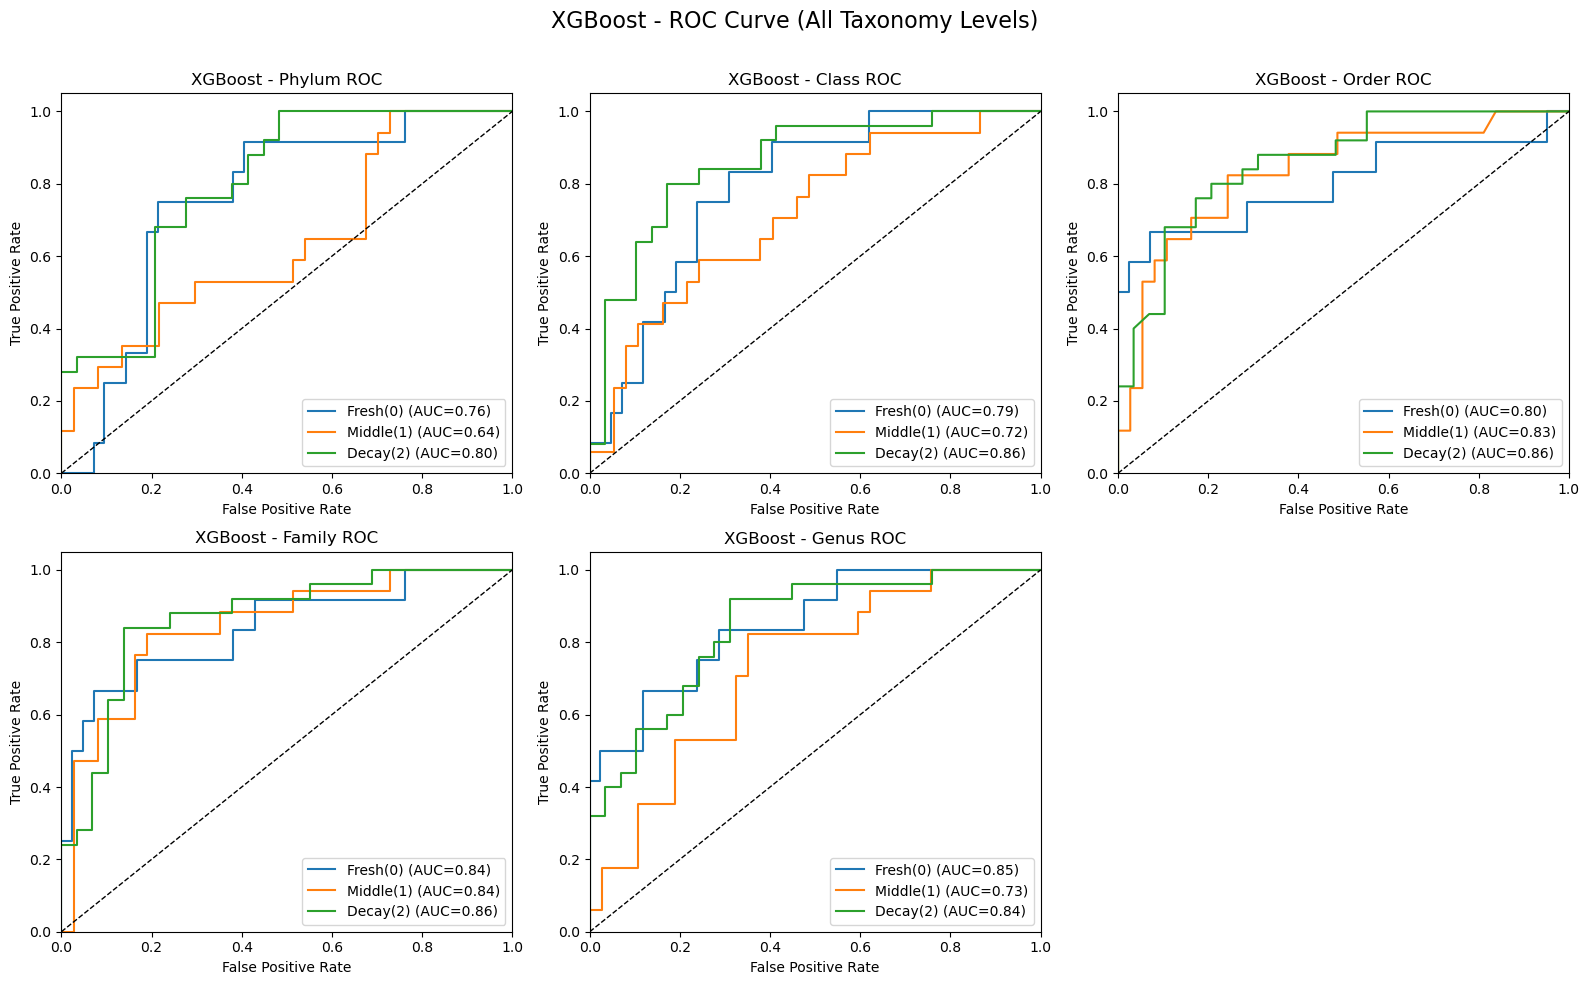

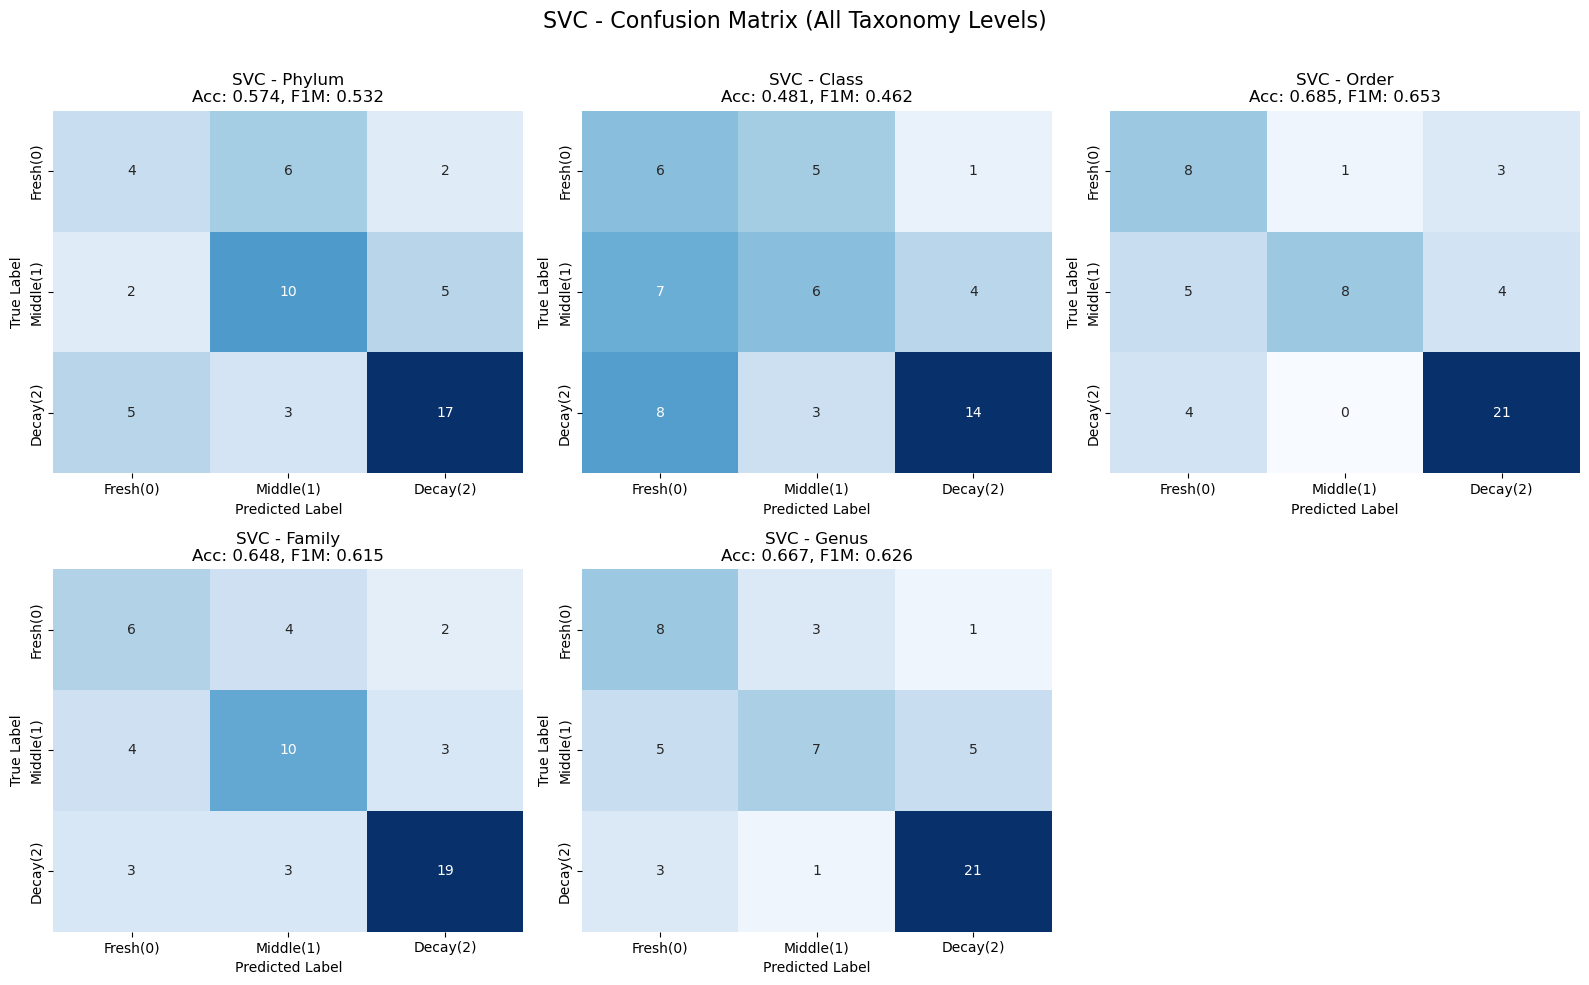

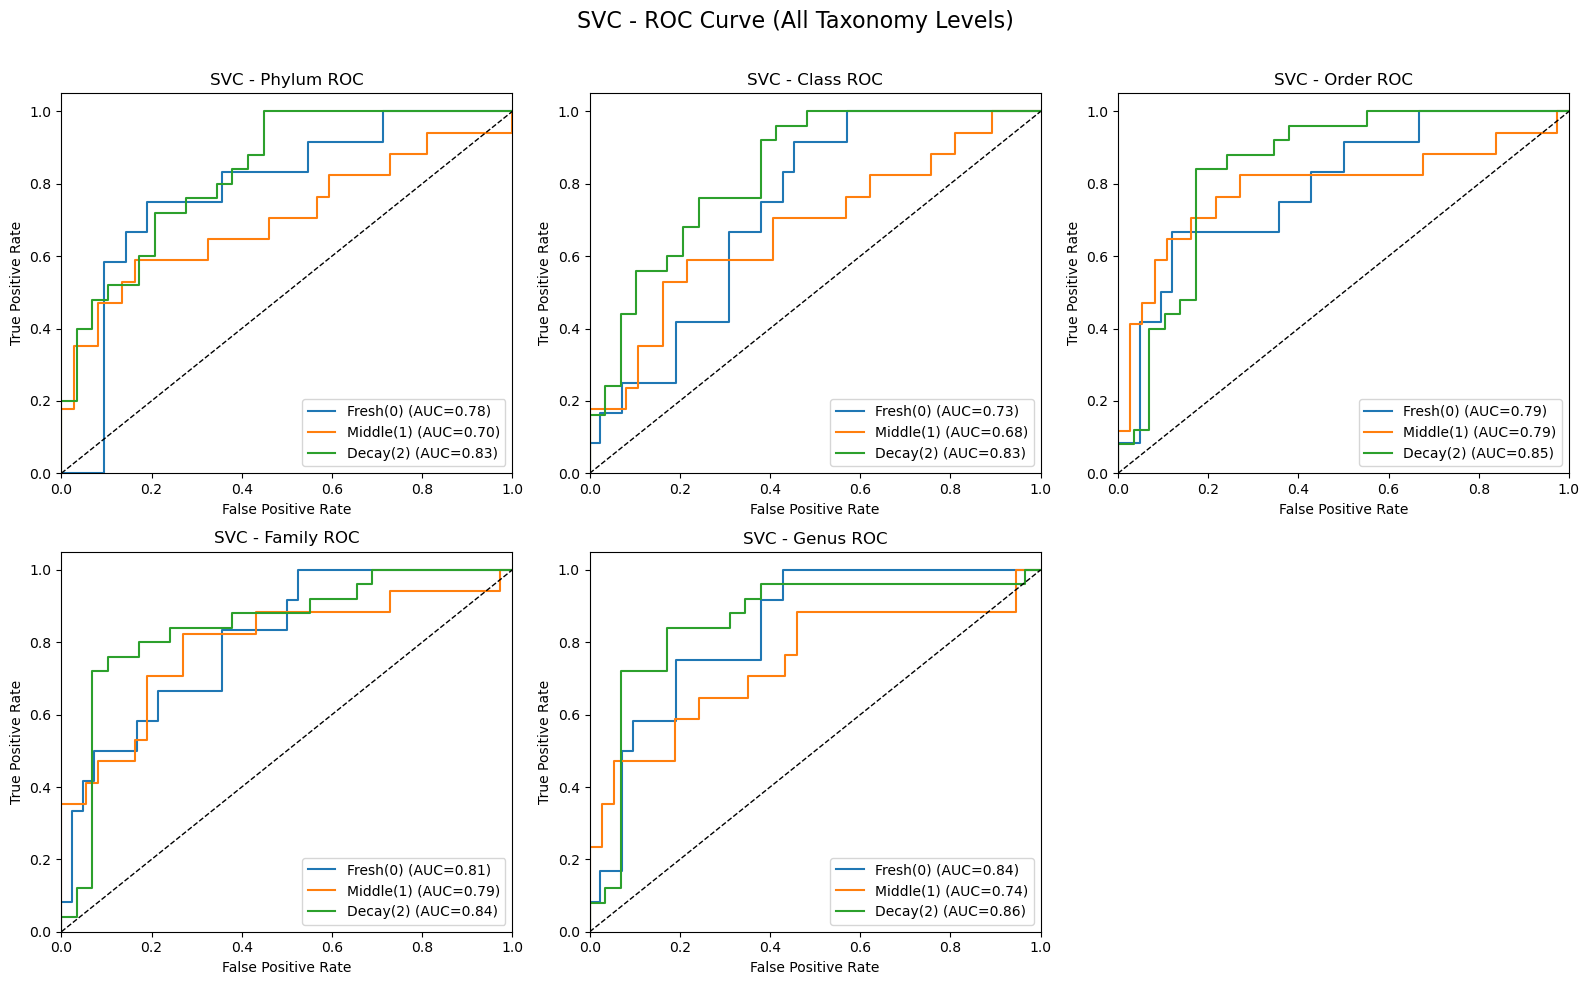

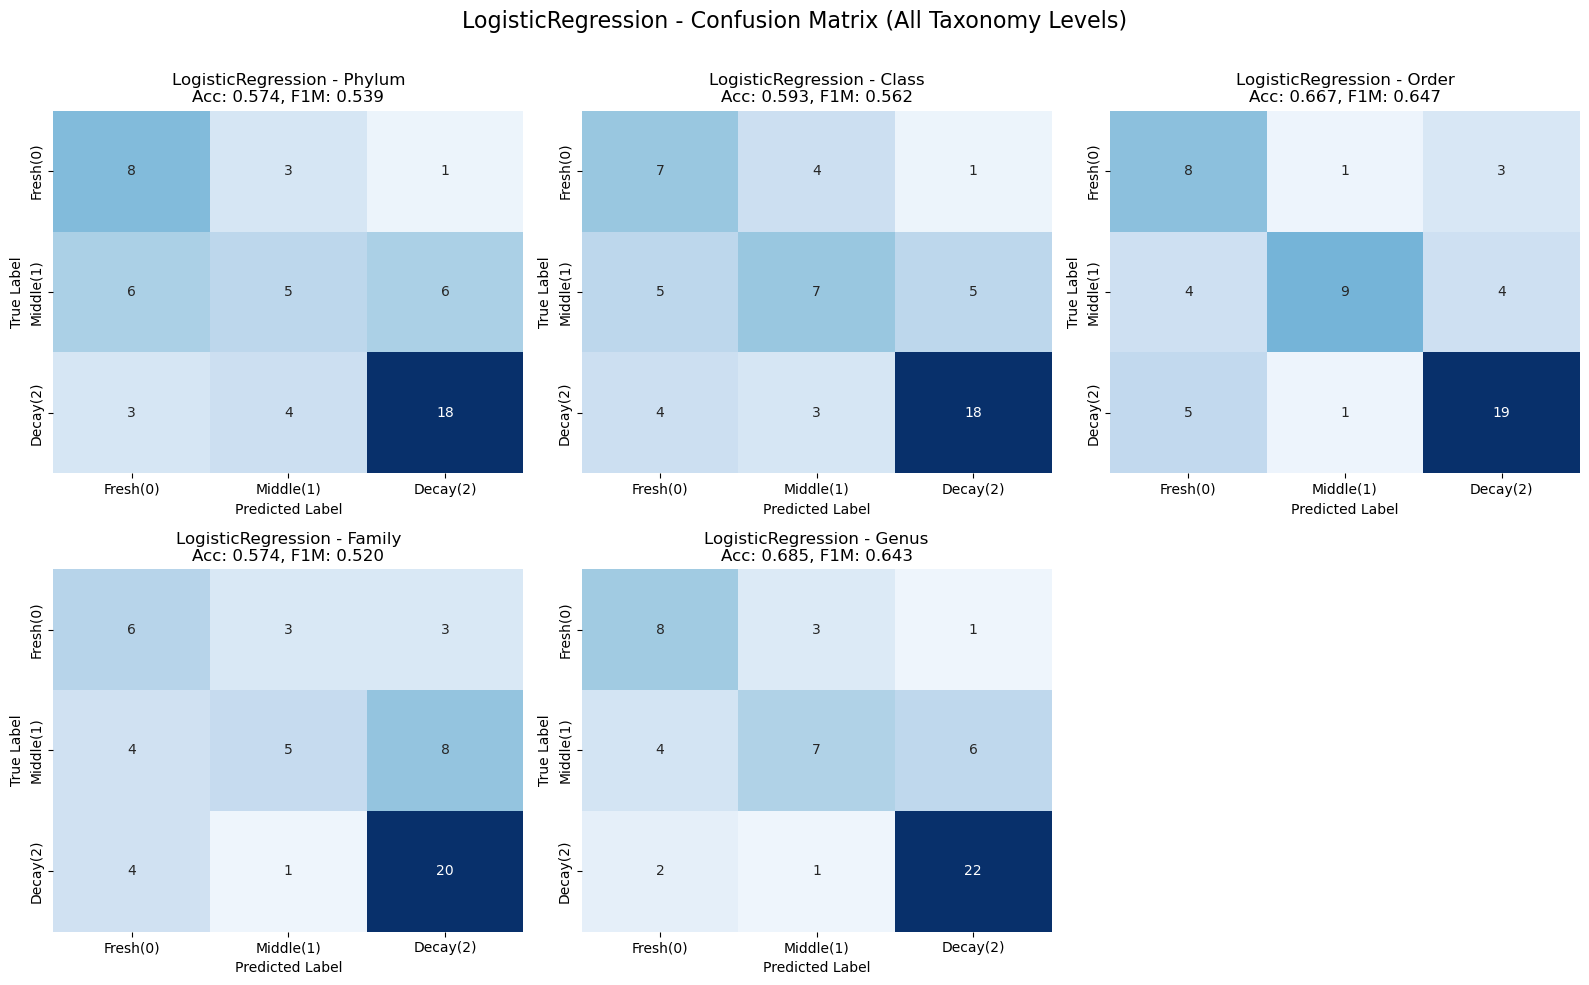

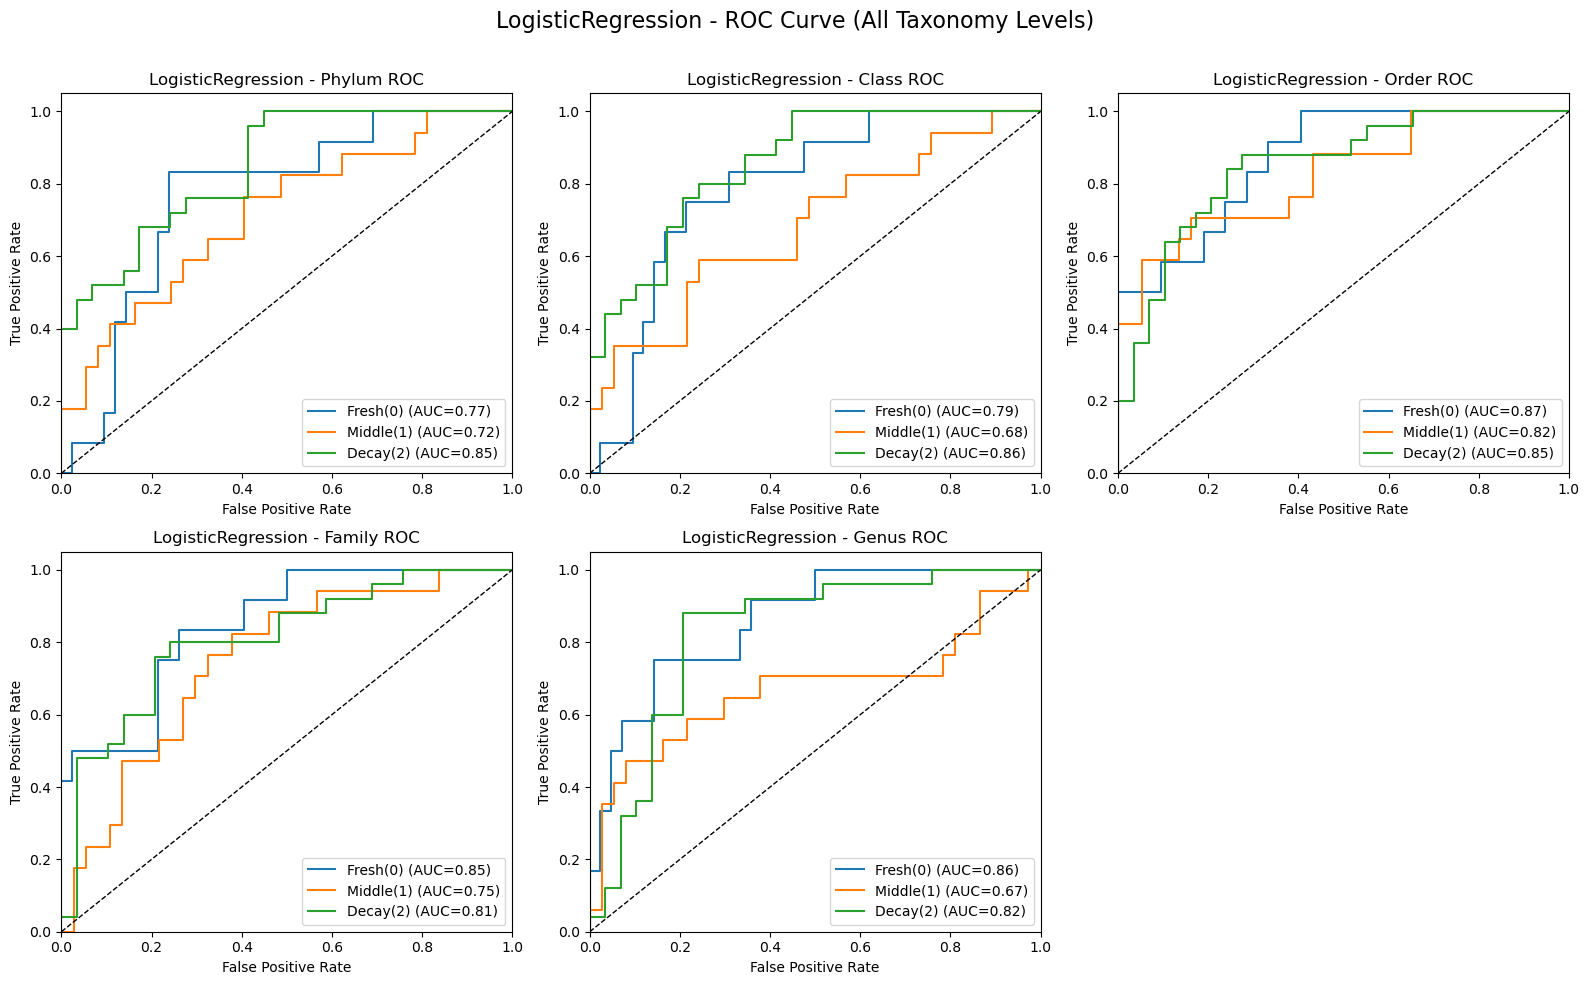

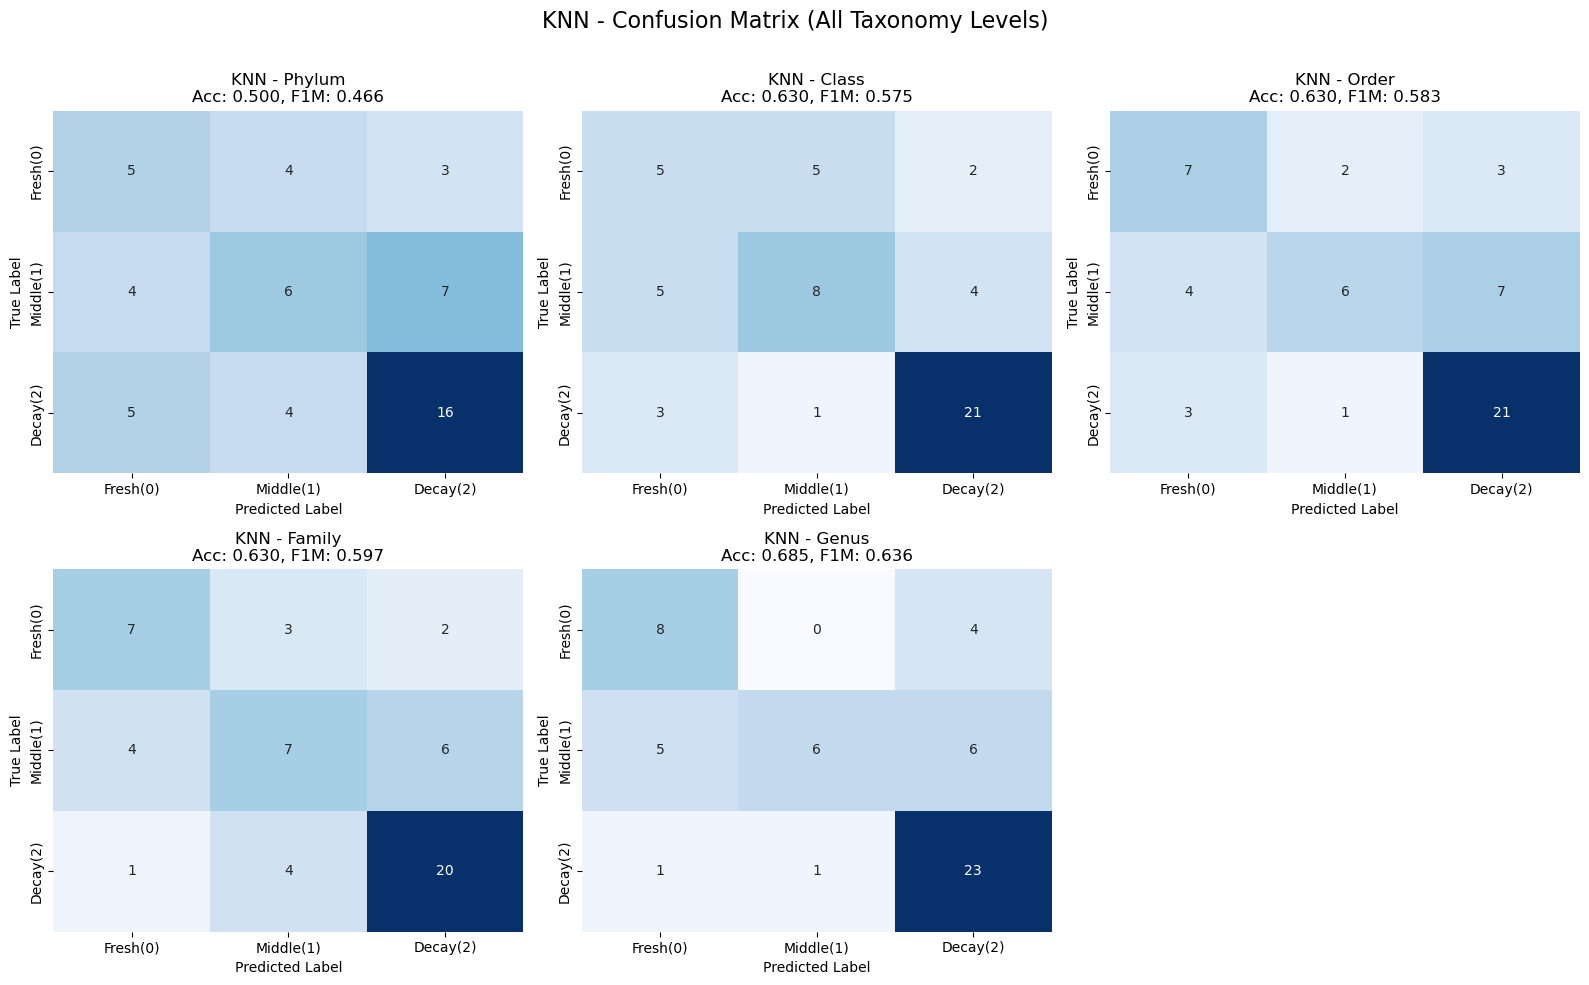

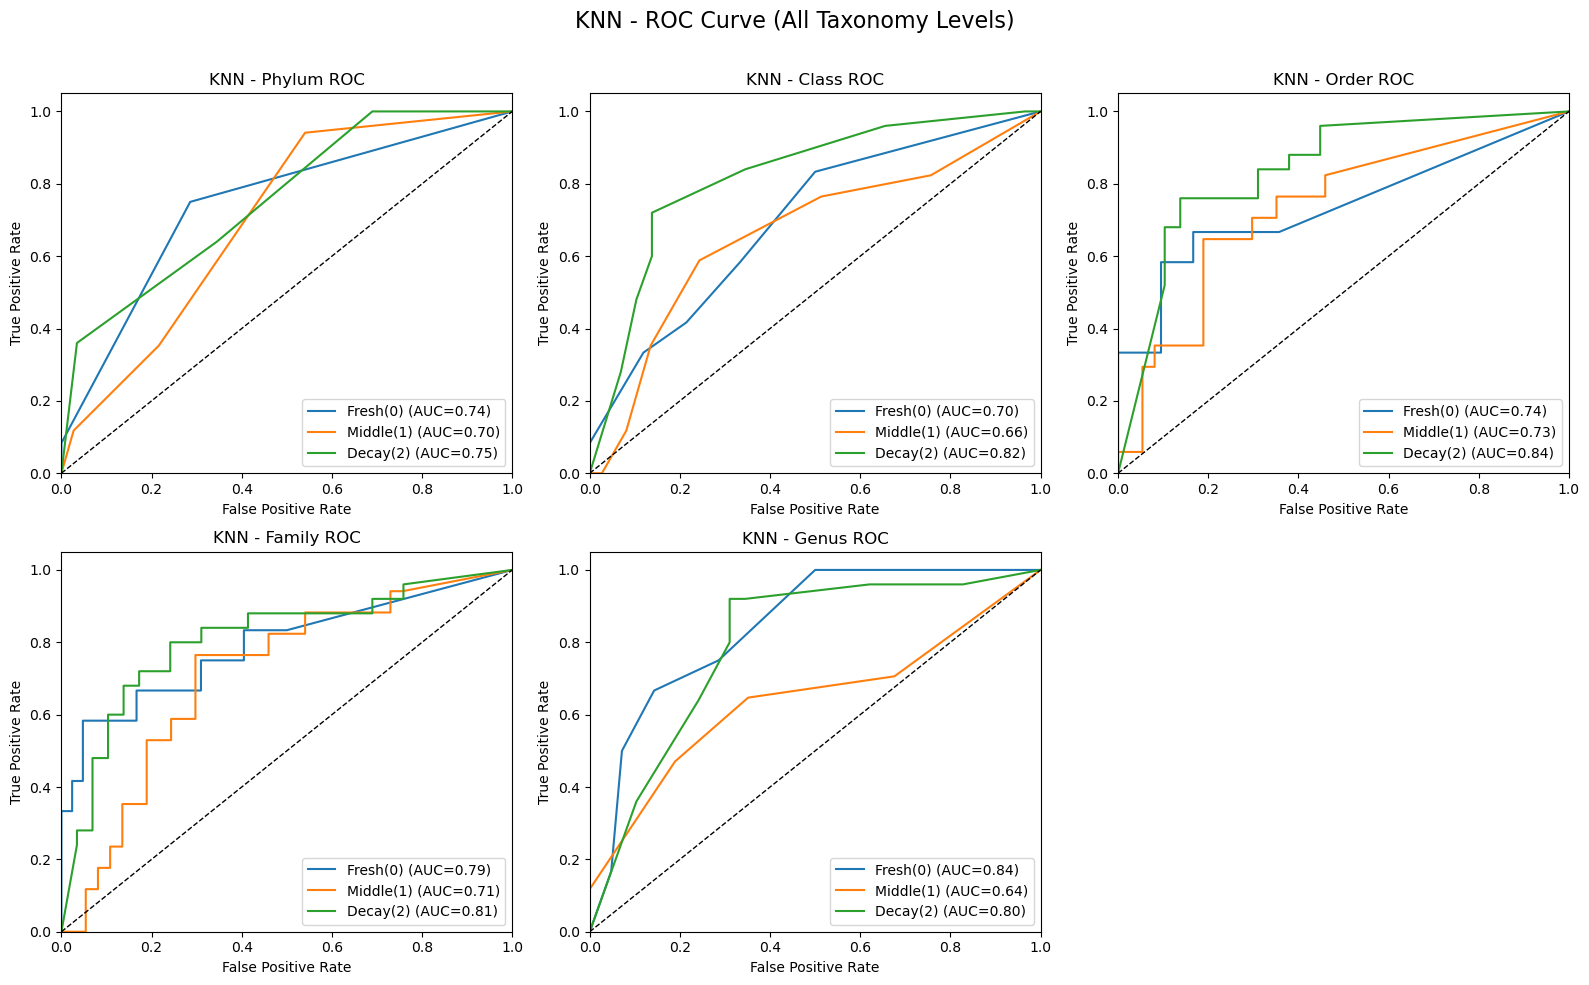

In [13]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# TBARS 라벨링 함수 (임계값 반영)
def tbars_labeling(tbars_series):
    return np.where(
        tbars_series < 0.189, 0,
        np.where(tbars_series < 0.289, 1, 2)
    )  # 0: Fresh, 1: Middle, 2: Decay

# 모델 및 파라미터 그리드 정의 (기존과 동일)
model_configs = {
    "RandomForest": {
        "model": RandomForestClassifier,
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "min_samples_split": [2, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier,
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1]
        }
    },
    "SVC": {
        "model": lambda: Pipeline([
            ('scaler', StandardScaler()),
            ('svc', SVC(probability=True, class_weight="balanced"))
        ]),
        "params": {
            "svc__C": [0.5, 1, 2],
            "svc__gamma": ["scale", "auto"],
            "svc__kernel": ["rbf"]
        }
    },
    "LogisticRegression": {
        "model": lambda: Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression())
        ]),
        "params": {
            "lr__penalty": ["elasticnet"],
            "lr__solver": ["saga"],
            "lr__l1_ratio": [0.2, 0.5, 0.8],
            "lr__C": [0.5, 1, 2],
            "lr__max_iter": [500],
            "lr__class_weight": ["balanced"],
            "lr__multi_class": ["multinomial"]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier,
        "params": {
            "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
        }
    }
}

taxonomy_levels = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

# TBARS 분류 모델 학습 (VIP>1.0 Feature만 사용)
all_model_results_tbars = {}

for level_name in taxonomy_levels:
    print(f"\n{'='*60}\n=== {level_name} Level 모델 학습 시작 (VIP>1.0 Feature, TBARS) ===\n{'='*60}")
    level_data = get_level_data(level_name)
    vip_features = vip_score_tbars[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
        continue
    X = level_data['features'][vip_features].values
    y = tbars_labeling(level_data['tbars'].values)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    all_model_results_tbars[level_name] = {}

    for model_name, config in model_configs.items():
        print(f"\n--- {model_name} 학습 ---")
        model = config["model"]() if callable(config["model"]) else config["model"]()
        param_grid = config["params"]

        grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        best_params = grid.best_params_

        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        train_f1 = f1_score(y_train, y_train_pred, average='macro')
        test_f1 = f1_score(y_test, y_test_pred, average='macro')
        overfit_acc = train_acc - test_acc
        overfit_f1 = train_f1 - test_f1

        all_model_results_tbars[level_name][model_name] = {
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "train_f1_score": train_f1,
            "test_f1_score": test_f1,
            "Overfitting_Acc": overfit_acc,
            "Overfitting_F1": overfit_f1,
            "Best_Params": best_params,
            "Best_Model": best_model,
            "GridSearchCV": grid,
            "X_test": X_test,
            "y_test": y_test
        }

        print(f"Train Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}")
        print(f"Train F1: {train_f1:.3f}, Test F1: {test_f1:.3f}")
        print(f"Overfitting Acc: {overfit_acc:.3f}, Overfitting F1: {overfit_f1:.3f}")
        print(f"Best Params: {best_params}")

print("\n=== 모든 모델 학습 및 평가 완료 ===")

# Confusion Matrix & ROC Curve (숫자 표기)
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

model_list = ["RandomForest", "XGBoost", "SVC", "LogisticRegression", "KNN"]
label_order = [0, 1, 2]  # Fresh(0), Middle(1), Decay(2)
label_names = ["Fresh(0)", "Middle(1)", "Decay(2)"]

for model in model_list:
    # 1. Confusion Matrix (3x2 subplot, 숫자 표기)
    fig_cm, axes_cm = plt.subplots(2, 3, figsize=(16, 10))
    axes_cm = axes_cm.flatten()
    for i, level in enumerate(taxonomy_levels):
        if level not in all_model_results_tbars or model not in all_model_results_tbars[level]:
            axes_cm[i].set_axis_off()
            continue
        best_model = all_model_results_tbars[level][model]["Best_Model"]
        X_test = all_model_results_tbars[level][model]["X_test"]
        y_test = all_model_results_tbars[level][model]["y_test"]
        y_pred = best_model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred, labels=label_order)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes_cm[i], cbar=False,
                    xticklabels=label_names, yticklabels=label_names, vmin=0)
        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average='macro')
        axes_cm[i].set_title(f"{model} - {level}\nAcc: {acc:.3f}, F1M: {f1m:.3f}")
        axes_cm[i].set_xlabel("Predicted Label")
        axes_cm[i].set_ylabel("True Label")
    axes_cm[5].axis('off')
    plt.suptitle(f"{model} - Confusion Matrix (All Taxonomy Levels)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    # 2. ROC Curve (3x2 subplot, 숫자 표기)
    fig_roc, axes_roc = plt.subplots(2, 3, figsize=(16, 10))
    axes_roc = axes_roc.flatten()
    for i, level in enumerate(taxonomy_levels):
        if level not in all_model_results_tbars or model not in all_model_results_tbars[level]:
            axes_roc[i].set_axis_off()
            continue
        best_model = all_model_results_tbars[level][model]["Best_Model"]
        X_test = all_model_results_tbars[level][model]["X_test"]
        y_test = all_model_results_tbars[level][model]["y_test"]
        y_test_bin = label_binarize(y_test, classes=label_order)
        y_score = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None
        ax = axes_roc[i]
        if y_score is not None:
            for j in range(3):
                fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_score[:, j])
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, label=f"{label_names[j]} (AUC={roc_auc:.2f})")
            ax.plot([0, 1], [0, 1], 'k--', lw=1)
            ax.set_xlim([0.0, 1.0])
            ax.set_ylim([0.0, 1.05])
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title(f"{model} - {level} ROC")
            ax.legend(loc="lower right")
        else:
            ax.text(0.5, 0.5, "No predict_proba", ha='center', va='center')
            ax.set_axis_off()
    axes_roc[5].axis('off')
    plt.suptitle(f"{model} - ROC Curve (All Taxonomy Levels)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## 화귀

## 모델학습 결과 엑셀 파일에 저장

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import os

# TPC 라벨링 함수 (Fresh, Middle만)
def tpc_labeling(tpc_series):
    return np.where(
        tpc_series < 4.369, 0,  # Fresh
        np.where(tpc_series < 6.427, 1, 2)  # Middle, Decay
    )

# TBARS 라벨링 함수 (Fresh, Middle만)
def tbars_labeling(tbars_series):
    return np.where(
        tbars_series < 0.187, 0,  # Fresh
        np.where(tbars_series < 0.298, 1, 2)  # Middle, Decay
    )

print("=== TPC 회귀 모델 학습 (Fresh + Middle만, VIP > 1.0 Features) ===")

# Genus level에서 VIP > 1.0 Feature 사용
level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_over1_dict[level_name]['Feature'].tolist()

if not vip_features:
    print("VIP > 1.0 feature가 없습니다.")
else:
    print(f"VIP > 1.0 Feature 수: {len(vip_features)}")
    
    # 전체 데이터에서 Fresh(0)와 Middle(1)만 선택
    tpc_labels = tpc_labeling(level_data['tpc'])
    fresh_middle_mask = (tpc_labels == 0) | (tpc_labels == 1)  # Fresh 또는 Middle
    
    # Fresh + Middle 데이터만 필터링
    X_filtered = level_data['features'][vip_features].loc[fresh_middle_mask].values
    y_filtered = level_data['tpc'].loc[fresh_middle_mask].values
    
    print(f"전체 데이터 수: {len(level_data['tpc'])}")
    print(f"Fresh + Middle 데이터 수: {len(y_filtered)}")
    print(f"제외된 Decay 데이터 수: {np.sum(tpc_labels == 2)}")
    print(f"TPC Target 범위 (Fresh+Middle): {y_filtered.min():.3f} ~ {y_filtered.max():.3f}")
    
    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered, y_filtered, test_size=0.2, random_state=42
    )
    
    print(f"Train set: {X_train.shape[0]}개")
    print(f"Test set: {X_test.shape[0]}개")
    
    # 모델 설정
    models = {
        'LightGBM': {
            'model': lgb.LGBMRegressor(random_state=42, verbose=-1),
            'params': {
                'n_estimators': [100, 200, 300],
                'max_depth': [3, 5, 7],
                'learning_rate': [0.01, 0.1, 0.2]
            }
        },
        'RandomForest': {
            'model': RandomForestRegressor(random_state=42),
            'params': {
                'n_estimators': [100, 200, 300],
                'max_depth': [3, 5, 7, None],
                'min_samples_split': [2, 5, 10]
            }
        },
        'XGBoost': {
            'model': xgb.XGBRegressor(random_state=42, verbosity=0),
            'params': {
                'n_estimators': [100, 200, 300],
                'max_depth': [3, 5, 7],
                'learning_rate': [0.01, 0.1, 0.2]
            }
        },
        'SVR': {
            'model': SVR(),
            'params': {
                'C': [0.1, 1, 10, 100],
                'gamma': ['scale', 'auto', 0.001, 0.01],
                'kernel': ['rbf', 'linear']
            }
        }
    }
    
    # 성능 평가 함수
    def calculate_metrics(y_true, y_pred, prefix=""):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        rsd = (rmse / np.mean(y_true)) * 100 if np.mean(y_true) != 0 else 0
        
        return {
            f"{prefix}MAE": mae,
            f"{prefix}RMSE": rmse,
            f"{prefix}R2": r2,
            f"{prefix}RSD": rsd
        }
    
    # 모델 학습 및 평가
    tpc_results = []
    
    for model_name, model_config in models.items():
        print(f"\n--- {model_name} 학습 중 ---")
        
        # GridSearchCV
        grid = GridSearchCV(
            model_config['model'], 
            model_config['params'], 
            cv=5, 
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )
        
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        
        # 예측
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)
        
        # Cross Validation
        cv_mae = -cross_val_score(best_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
        cv_rmse = np.sqrt(-cross_val_score(best_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error'))
        cv_r2 = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
        
        # 성능 계산
        train_metrics = calculate_metrics(y_train, y_train_pred, "Train_")
        test_metrics = calculate_metrics(y_test, y_test_pred, "Test_")
        
        # Overfitting 지표
        overfit_mae = train_metrics["Train_MAE"] - test_metrics["Test_MAE"]
        overfit_rmse = train_metrics["Train_RMSE"] - test_metrics["Test_RMSE"]
        overfit_r2 = train_metrics["Train_R2"] - test_metrics["Test_R2"]
        overfit_rsd = train_metrics["Train_RSD"] - test_metrics["Test_RSD"]
        
        # 결과 저장
        result = {
            "Taxonomy_Level": "Genus",
            "Model": model_name,
            "Data_Type": "Fresh_Middle_Only",
            "Train_Samples": len(y_train),
            "Test_Samples": len(y_test),
            "Train_MAE": train_metrics["Train_MAE"],
            "Test_MAE": test_metrics["Test_MAE"],
            "Train_RMSE": train_metrics["Train_RMSE"],
            "Test_RMSE": test_metrics["Test_RMSE"],
            "Train_R2": train_metrics["Train_R2"],
            "Test_R2": test_metrics["Test_R2"],
            "Train_RSD": train_metrics["Train_RSD"],
            "Test_RSD": test_metrics["Test_RSD"],
            "Overfit_MAE": overfit_mae,
            "Overfit_RMSE": overfit_rmse,
            "Overfit_R2": overfit_r2,
            "Overfit_RSD": overfit_rsd,
            "CV_MAE_Mean": cv_mae.mean(),
            "CV_RMSE_Mean": cv_rmse.mean(),
            "CV_R2_Mean": cv_r2.mean(),
            "Best_Params": str(grid.best_params_)
        }
        
        tpc_results.append(result)
        
        print(f"Best Params: {grid.best_params_}")
        print(f"Test MAE: {test_metrics['Test_MAE']:.4f}")
        print(f"Test RMSE: {test_metrics['Test_RMSE']:.4f}")
        print(f"Test R2: {test_metrics['Test_R2']:.4f}")
    
    # 결과 DataFrame 생성
    tpc_results_df = pd.DataFrame(tpc_results)
    
    print("\n=== TPC 회귀 모델 성능 결과 (Fresh+Middle, VIP > 1.0 Features) ===")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print(tpc_results_df)
    
    # 결과 저장
    os.makedirs("model_result", exist_ok=True)
    tpc_results_df.to_excel("model_result/CLR_KMenas_변화_tpc.xlsx", index=False)
    print(f"\nTPC 결과가 'model_result/CLR_KMenas_변화_tpc.xlsx'에 저장되었습니다.")
    
    # 상세 정보 저장
    with pd.ExcelWriter("model_result/CLR_KMenas_변화_tpc_상세.xlsx") as writer:
        tpc_results_df.to_excel(writer, sheet_name='모델성능', index=False)
        
        data_info = pd.DataFrame({
            'Info': ['전체 데이터 수', 'Fresh+Middle 데이터 수', 'Decay 제외 수', 'VIP Feature 수', 'Train 데이터 수', 'Test 데이터 수', 'Target 최소값', 'Target 최대값'],
            'Value': [len(level_data['tpc']), len(y_filtered), np.sum(tpc_labels == 2), len(vip_features), X_train.shape[0], X_test.shape[0], y_filtered.min(), y_filtered.max()]
        })
        data_info.to_excel(writer, sheet_name='데이터정보', index=False)
        
        feature_info = pd.DataFrame({'VIP_Features': vip_features})
        feature_info.to_excel(writer, sheet_name='VIP_Feature목록', index=False)
    
    print(f"TPC 상세 결과가 'model_result/CLR_KMenas_변화_tpc_상세.xlsx'에 저장되었습니다.")

=== TPC 회귀 모델 학습 (Fresh + Middle만, VIP > 1.0 Features) ===
VIP > 1.0 Feature 수: 32
전체 데이터 수: 270
Fresh + Middle 데이터 수: 235
제외된 Decay 데이터 수: 35
TPC Target 범위 (Fresh+Middle): 2.062 ~ 6.421
Train set: 188개
Test set: 47개

--- LightGBM 학습 중 ---


/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed 

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Test MAE: 0.4258
Test RMSE: 0.5779
Test R2: 0.7447

--- RandomForest 학습 중 ---
Best Params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Test MAE: 0.3839
Test RMSE: 0.5235
Test R2: 0.7905

--- XGBoost 학습 중 ---
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Test MAE: 0.3984
Test RMSE: 0.5770
Test R2: 0.7455

--- SVR 학습 중 ---
Best Params: {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
Test MAE: 0.3247
Test RMSE: 0.4467
Test R2: 0.8474

=== TPC 회귀 모델 성능 결과 (Fresh+Middle, VIP > 1.0 Features) ===
  Taxonomy_Level         Model          Data_Type  Train_Samples  \
0          Genus      LightGBM  Fresh_Middle_Only            188   
1          Genus  RandomForest  Fresh_Middle_Only            188   
2          Genus       XGBoost  Fresh_Middle_Only            188   
3          Genus           SVR  Fresh_Middle_Only            188   

   Test_Samples  Train_MAE  Test_MAE  Train_RMSE  Te

In [15]:
# TPC 결과 저장 - CLR_KMenas_변화_tpc 파일명으로 저장
os.makedirs("model_result", exist_ok=True)
tpc_results_df.to_excel("model_result/CLR_KMenas_변화_tpc.xlsx", index=False)
print(f"\nTPC 결과가 'model_result/CLR_KMenas_변화_tpc.xlsx'에 저장되었습니다.")

# 추가적인 상세 정보도 함께 저장
with pd.ExcelWriter("model_result/CLR_KMenas_변화_tpc_상세.xlsx") as writer:
    # 모델 성능 결과
    tpc_results_df.to_excel(writer, sheet_name='모델성능', index=False)
    
    # 데이터 정보
    data_info = pd.DataFrame({
        'Info': ['데이터 수', 'VIP Feature 수', 'Train 데이터 수', 'Test 데이터 수', 'Target 최소값', 'Target 최대값'],
        'Value': [len(y), len(vip_features), X_train.shape[0], X_test.shape[0], y.min(), y.max()]
    })
    data_info.to_excel(writer, sheet_name='데이터정보', index=False)
    
    # VIP Feature 이름
    feature_info = pd.DataFrame({'VIP_Features': vip_features})
    feature_info.to_excel(writer, sheet_name='VIP_Feature목록', index=False)

print(f"TPC 상세 결과가 'model_result/CLR_KMenas_변화_tpc_상세.xlsx'에 저장되었습니다.")


TPC 결과가 'model_result/CLR_KMenas_변화_tpc.xlsx'에 저장되었습니다.
TPC 상세 결과가 'model_result/CLR_KMenas_변화_tpc_상세.xlsx'에 저장되었습니다.


/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed 

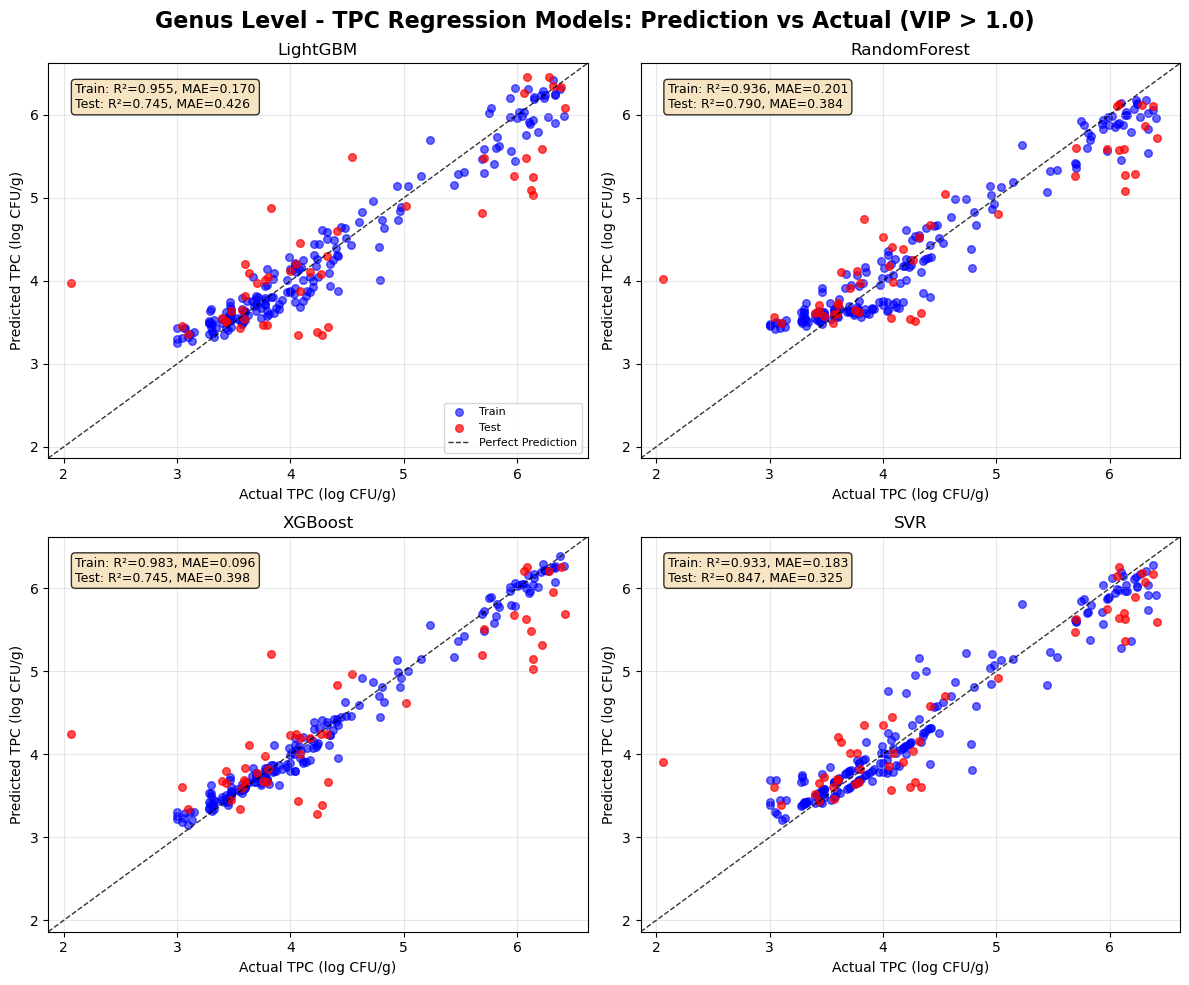

In [16]:
# TPC Prediction vs Actual 시각화 (2x2 subplot)
import matplotlib.pyplot as plt
import numpy as np

# 모델별 예측값 저장
tpc_model_predictions = {}
model_names = ['LightGBM', 'RandomForest', 'XGBoost', 'SVR']

# 각 모델별로 다시 예측값 계산 (시각화용)
for i, model_name in enumerate(model_names):
    # 해당 모델로 다시 학습
    model_config = models[model_name]
    grid = GridSearchCV(
        model_config['model'], 
        model_config['params'], 
        cv=5, 
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    
    # 예측
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    
    # Train과 Test의 R2, MAE 계산
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    tpc_model_predictions[model_name] = {
        'y_train': y_train,
        'y_test': y_test,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'test_mae': test_mae
    }

# 2x2 subplot 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Genus Level - TPC Regression Models: Prediction vs Actual (VIP > 1.0)', fontsize=16, fontweight='bold')

# 전체 데이터 범위 계산
all_actual = np.concatenate([y_train, y_test])
min_val = all_actual.min() - 0.2
max_val = all_actual.max() + 0.2

for i, model_name in enumerate(model_names):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    pred_data = tpc_model_predictions[model_name]
    
    # Train 데이터 플롯 (파란색)
    ax.scatter(pred_data['y_train'], pred_data['y_train_pred'], 
               alpha=0.6, color='blue', s=30, label='Train')
    
    # Test 데이터 플롯 (빨간색)
    ax.scatter(pred_data['y_test'], pred_data['y_test_pred'], 
               alpha=0.7, color='red', s=30, label='Test')
    
    # Perfect prediction line (검은 점선)
    ax.plot([min_val, max_val], [min_val, max_val], 
            'k--', alpha=0.8, linewidth=1, label='Perfect Prediction')
    
    # 축 설정
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_xlabel('Actual TPC (log CFU/g)')
    ax.set_ylabel('Predicted TPC (log CFU/g)')
    ax.set_title(f'{model_name}')
    ax.grid(True, alpha=0.3)
    
    # 성능 지표 텍스트 추가
    textstr = f'Train: R²={pred_data["train_r2"]:.3f}, MAE={pred_data["train_mae"]:.3f}\nTest: R²={pred_data["test_r2"]:.3f}, MAE={pred_data["test_mae"]:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props)
    
    # 범례 (첫 번째 subplot에만)
    if i == 0:
        ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## SHAP 후분석

In [17]:
# Genus level에서 SVR 모델에 적용된 feature 목록 출력
print("=== Genus level SVR 모델 적용 Feature 목록 ===")
print(f"Feature 개수: {len(vip_features)}")
for i, feat in enumerate(vip_features, 1):
    print(f"{i}. {feat}")

=== Genus level SVR 모델 적용 Feature 목록 ===
Feature 개수: 32
1. g__Iodobacter
2. g__Carnobacterium
3. g__Cloacibacterium
4. g__Vagococcus
5. g__Streptococcus
6. g__Bacillus
7. g__Kocuria
8. g__Chryseobacterium
9. g__Xanthomonas
10. g__Macrococcus
11. g__Rhodococcus
12. g__Aeromonas
13. g__Thermus
14. g__Hafnia-Obesumbacterium
15. g__Staphylococcus
16. g__Weissella
17. g__Flavobacterium
18. g__Paeniglutamicibacter
19. g__Photobacterium
20. g__Brevibacterium
21. g__Enterococcus
22. g__Cupriavidus
23. g__Paracoccus
24. g__Methylobacterium-Methylorubrum
25. g__Corynebacterium
26. g__Stenotrophomonas
27. g__Myroides
28. g__Acetobacter
29. g__Lactobacillus
30. g__Janthinobacterium
31. g__Enhydrobacter
32. g__Bifidobacterium


=== SVR 모델 SHAP 분석 ===


  0%|          | 0/47 [00:00<?, ?it/s]

SHAP 값 계산 완료 - Shape: (47, 32)

=== SHAP 값 범위 분석 ===
SHAP 값 전체 최솟값: -0.391405
SHAP 값 전체 최댓값: 0.381839
SHAP 값 평균: 0.002106
SHAP 값 표준편차: 0.071748
SHAP 절댓값 최댓값: 0.391405

=== Top 20 Feature SHAP 값 범위 ===
Top 20 SHAP 값 최솟값: -0.391405
Top 20 SHAP 값 최댓값: 0.381839


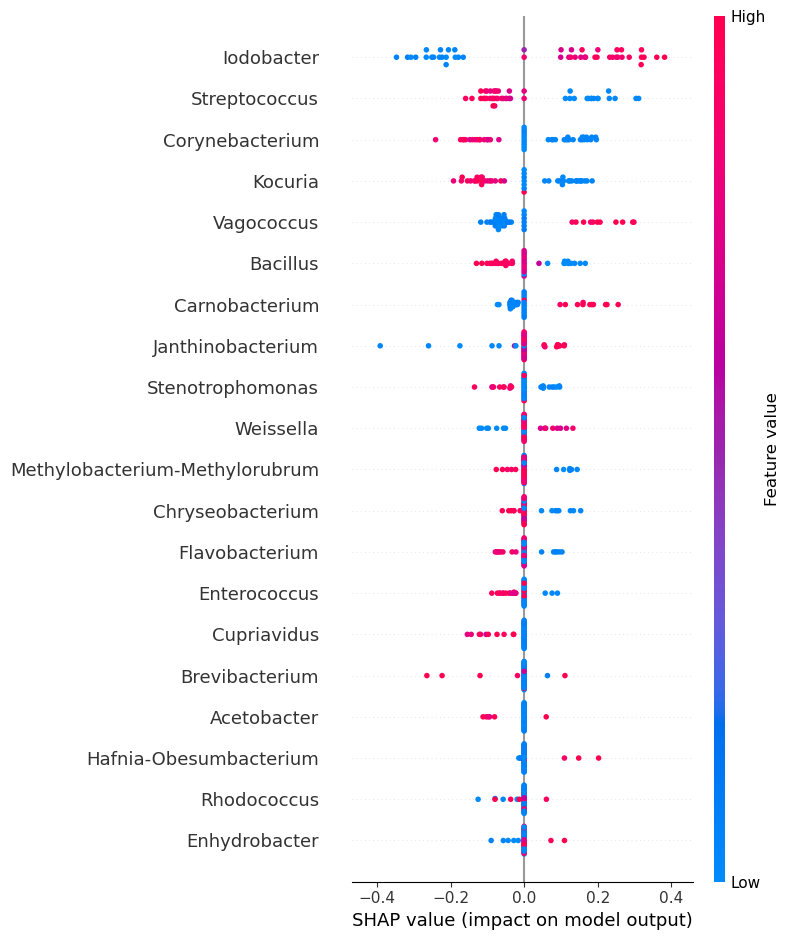

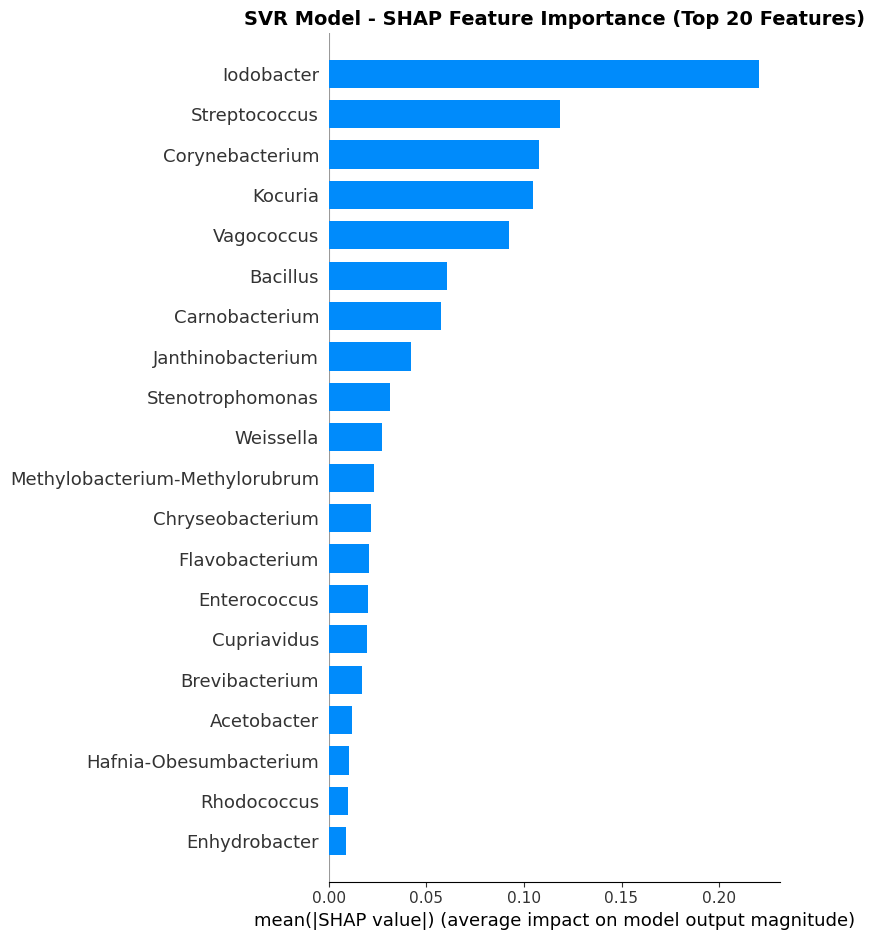

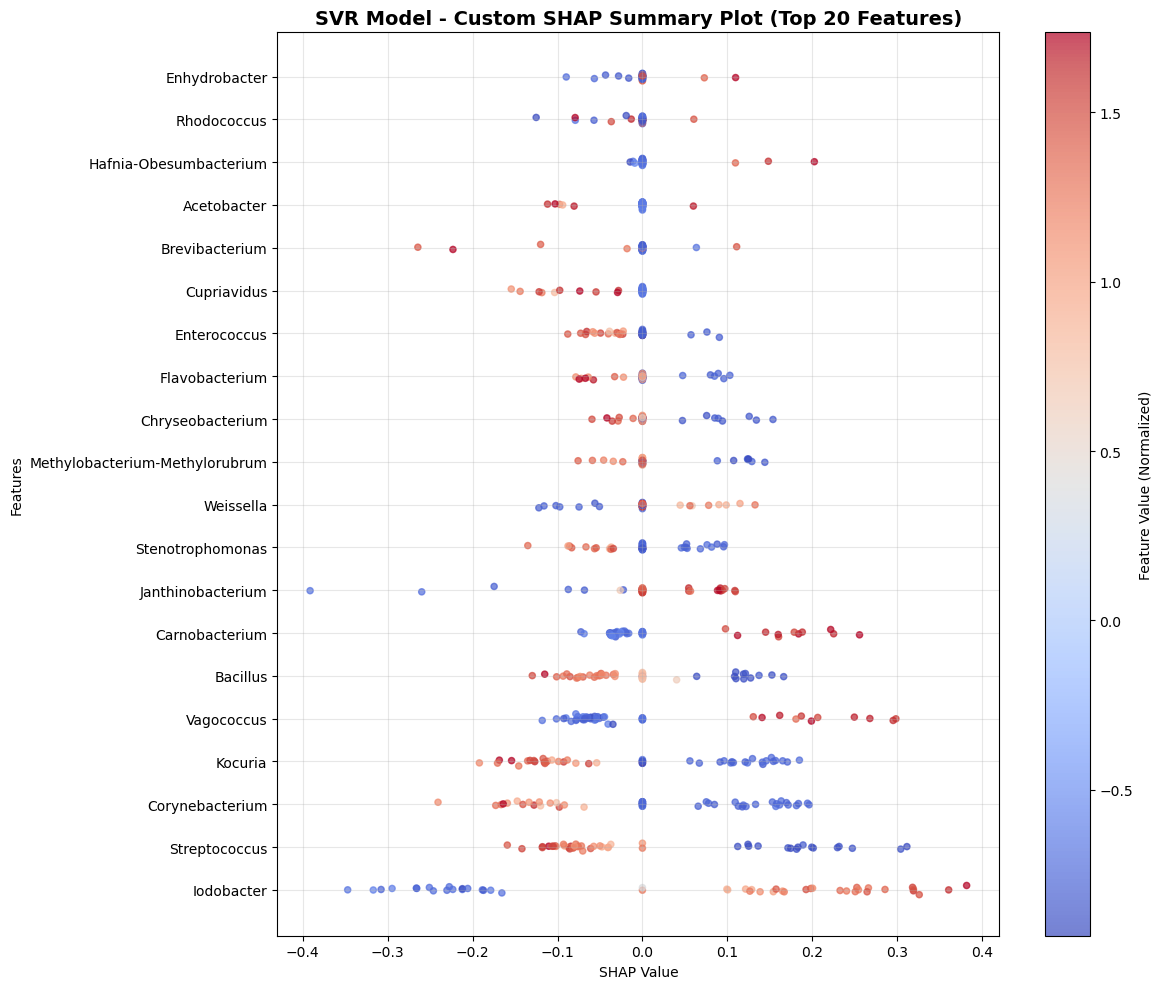


=== SVR 모델 Top 20 Feature Importance 순위 (SHAP 기준) ===
 1. Iodobacter                     | SHAP Importance: 0.220203
 2. Streptococcus                  | SHAP Importance: 0.118651
 3. Corynebacterium                | SHAP Importance: 0.107876
 4. Kocuria                        | SHAP Importance: 0.104743
 5. Vagococcus                     | SHAP Importance: 0.092104
 6. Bacillus                       | SHAP Importance: 0.060572
 7. Carnobacterium                 | SHAP Importance: 0.057607
 8. Janthinobacterium              | SHAP Importance: 0.041880
 9. Stenotrophomonas               | SHAP Importance: 0.031347
10. Weissella                      | SHAP Importance: 0.027480
11. Methylobacterium-Methylorubrum | SHAP Importance: 0.022971
12. Chryseobacterium               | SHAP Importance: 0.021473
13. Flavobacterium                 | SHAP Importance: 0.020618
14. Enterococcus                   | SHAP Importance: 0.020164
15. Cupriavidus                    | SHAP Importance: 0.019690


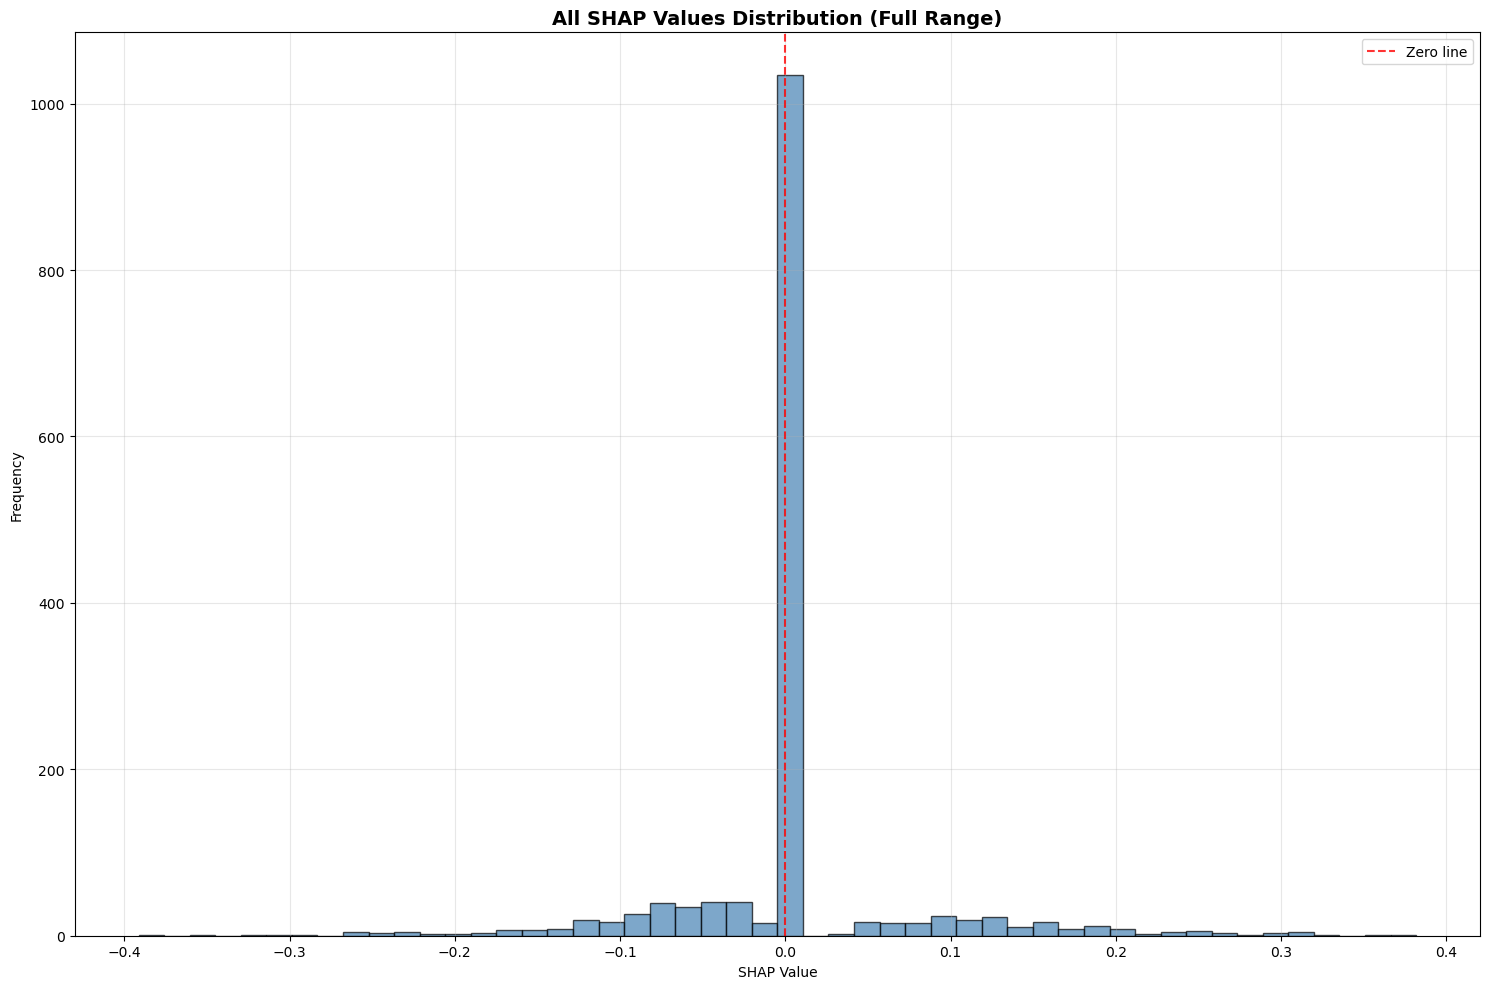


=== SVR 모델 성능 및 SHAP 분석 요약 ===
Test R²: 0.8371
Test MAE: 0.3178
분석된 샘플 수: 47
전체 Feature 수: 32
분석된 Top Feature 수: 20
가장 중요한 Feature: Iodobacter
가장 중요한 Feature SHAP 값: 0.220203
SHAP 값 실제 범위: -0.391405 ~ 0.381839


In [18]:
# SVR 모델 SHAP 분석 (수정된 버전 - 범위 확인 포함)
import shap
import matplotlib.pyplot as plt
import numpy as np

# SVR 모델 재학습 (SHAP 분석용)
print("=== SVR 모델 SHAP 분석 ===")

level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_over1_dict[level_name]['Feature'].tolist()
genus_names = [f.replace('g__', '') for f in vip_features]

# Fresh + Middle 데이터만 사용 (기존과 동일)
tpc_labels = tpc_labeling(level_data['tpc'])
fresh_middle_mask = (tpc_labels == 0) | (tpc_labels == 1)
X_filtered = level_data['features'][vip_features].loc[fresh_middle_mask].values
y_filtered = level_data['tpc'].loc[fresh_middle_mask].values

# Train-Test Split (기존과 동일하게)
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42
)

# SVR 모델 재학습
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# SVR 파이프라인 생성 (스케일링 포함)
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(C=10, gamma='scale', kernel='rbf'))  # 최적 파라미터 사용
])

# 모델 학습
svr_pipeline.fit(X_train, y_train)

# SHAP 분석을 위한 데이터 준비
# SVR은 스케일링이 필요하므로 스케일된 데이터 사용
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVR 모델만 추출 (파이프라인에서)
svr_model = svr_pipeline.named_steps['svr']

# SHAP Explainer 생성 (KernelExplainer 사용 - SVR에 적합)
# 샘플링을 통해 배경 데이터 크기 줄이기
background_sample = shap.sample(X_train_scaled, 100)  # 100개 샘플만 사용
explainer = shap.KernelExplainer(svr_model.predict, background_sample)

# SHAP 값 계산 (테스트 데이터 일부만 사용)
test_sample = X_test_scaled[:50]  # 50개 테스트 샘플만 사용
shap_values = explainer.shap_values(test_sample)

print(f"SHAP 값 계산 완료 - Shape: {shap_values.shape}")

# ⭐⭐⭐ SHAP 값 범위 확인 ⭐⭐⭐
print(f"\n=== SHAP 값 범위 분석 ===")
print(f"SHAP 값 전체 최솟값: {shap_values.min():.6f}")
print(f"SHAP 값 전체 최댓값: {shap_values.max():.6f}")
print(f"SHAP 값 평균: {shap_values.mean():.6f}")
print(f"SHAP 값 표준편차: {shap_values.std():.6f}")
print(f"SHAP 절댓값 최댓값: {np.abs(shap_values).max():.6f}")

# Feature Importance 계산 및 상위 20개 선택
feature_importance = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': genus_names,
    'SHAP_Importance': feature_importance
}).sort_values('SHAP_Importance', ascending=False)

# 상위 20개 feature 선택
top_20_features = importance_df.head(20)
top_20_indices = [genus_names.index(feat) for feat in top_20_features['Feature']]
top_20_names = top_20_features['Feature'].tolist()

# 상위 20개 feature만으로 SHAP 값 필터링
shap_values_top20 = shap_values[:, top_20_indices]
test_sample_top20 = test_sample[:, top_20_indices]

print(f"\n=== Top 20 Feature SHAP 값 범위 ===")
print(f"Top 20 SHAP 값 최솟값: {shap_values_top20.min():.6f}")
print(f"Top 20 SHAP 값 최댓값: {shap_values_top20.max():.6f}")

# 1. SHAP Summary Plot (상위 20개) - 범위 수동 설정
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values_top20, 
    test_sample_top20, 
    feature_names=top_20_names,
    show=False
)
# 실제 SHAP 값 범위로 x축 설정
actual_min = shap_values_top20.min()
actual_max = shap_values_top20.max()
margin = (actual_max - actual_min) * 0.1  # 10% 여백
plt.xlim(actual_min - margin, actual_max + margin)

plt.tight_layout()
plt.show()

# 2. SHAP Bar Plot (상위 20개)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_top20, 
    test_sample_top20, 
    feature_names=top_20_names,
    plot_type="bar",
    show=False
)
plt.title('SVR Model - SHAP Feature Importance (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. 커스텀 SHAP Summary Plot (더 넓은 범위)
plt.figure(figsize=(12, 10))

# 각 feature별로 SHAP 값과 feature 값 산점도 생성
colors = plt.cm.coolwarm(np.linspace(0, 1, len(top_20_names)))
y_positions = np.arange(len(top_20_names))

for i, (feature_idx, feature_name) in enumerate(zip(range(len(top_20_names)), top_20_names)):
    shap_vals = shap_values_top20[:, feature_idx]
    feature_vals = test_sample_top20[:, feature_idx]
    
    # Feature 값에 따른 색상 설정
    scatter = plt.scatter(shap_vals, 
                         np.full(len(shap_vals), y_positions[i]) + np.random.normal(0, 0.04, len(shap_vals)),
                         c=feature_vals, 
                         cmap='coolwarm', 
                         alpha=0.7, 
                         s=20)

plt.yticks(y_positions, top_20_names)
plt.xlabel('SHAP Value')
plt.ylabel('Features')
plt.title('SVR Model - Custom SHAP Summary Plot (Top 20 Features)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Feature Value (Normalized)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Feature Importance 순위 출력 (상위 20개)
print("\n=== SVR 모델 Top 20 Feature Importance 순위 (SHAP 기준) ===")
for i, (idx, row) in enumerate(top_20_features.iterrows(), 1):
    print(f"{i:2d}. {row['Feature']:<30} | SHAP Importance: {row['SHAP_Importance']:.6f}")

# 5. SHAP 값 범위별 히스토그램 (더 세밀한 분석)
plt.figure(figsize=(15, 10))
plt.hist(shap_values.flatten(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('SHAP Value')
plt.ylabel('Frequency')
plt.title('All SHAP Values Distribution (Full Range)', fontsize=14, fontweight='bold')
plt.axvline(0, color='red', linestyle='--', alpha=0.8, label='Zero line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. 모델 성능과 SHAP 분석 요약
svr_pred = svr_pipeline.predict(X_test)
test_r2 = r2_score(y_test, svr_pred)
test_mae = mean_absolute_error(y_test, svr_pred)

print(f"\n=== SVR 모델 성능 및 SHAP 분석 요약 ===")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"분석된 샘플 수: {len(test_sample)}")
print(f"전체 Feature 수: {len(genus_names)}")
print(f"분석된 Top Feature 수: 20")
print(f"가장 중요한 Feature: {top_20_features.iloc[0]['Feature']}")
print(f"가장 중요한 Feature SHAP 값: {top_20_features.iloc[0]['SHAP_Importance']:.6f}")
print(f"SHAP 값 실제 범위: {actual_min:.6f} ~ {actual_max:.6f}")

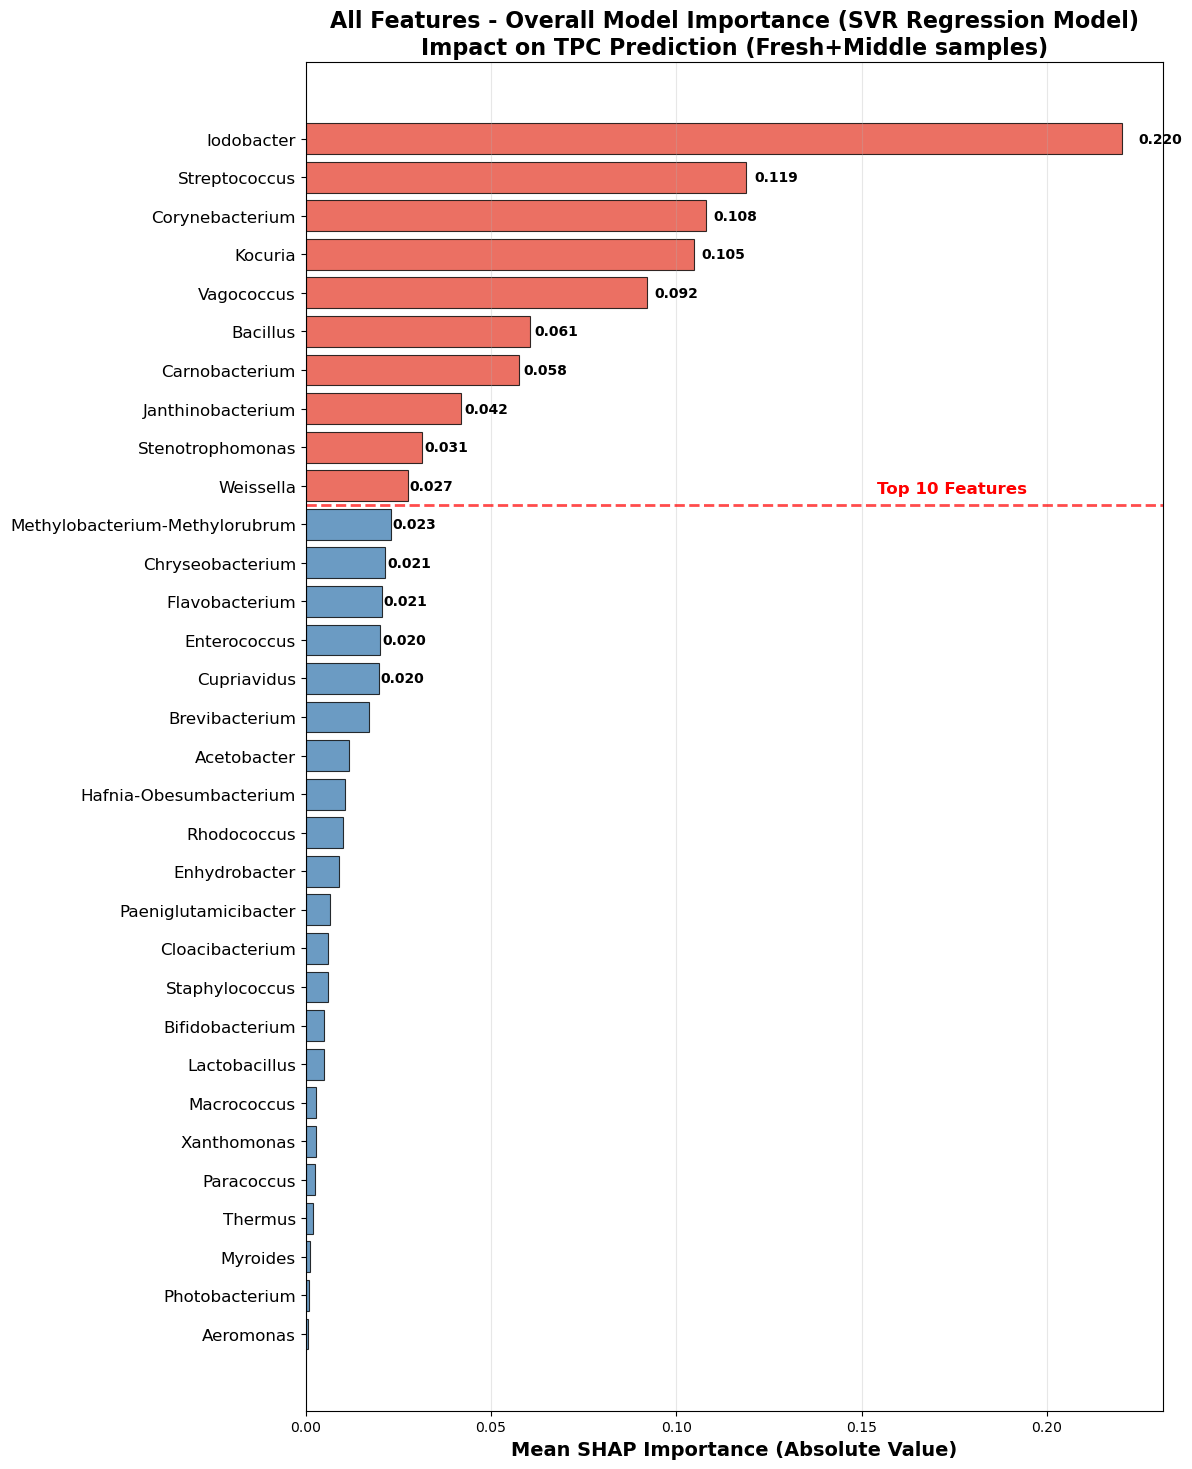


=== SVR 회귀 모델 Top 10 Feature Importance 순위 ===
 1. Iodobacter                     | SHAP Importance: 0.220203
 2. Streptococcus                  | SHAP Importance: 0.118651
 3. Corynebacterium                | SHAP Importance: 0.107876
 4. Kocuria                        | SHAP Importance: 0.104743
 5. Vagococcus                     | SHAP Importance: 0.092104
 6. Bacillus                       | SHAP Importance: 0.060572
 7. Carnobacterium                 | SHAP Importance: 0.057607
 8. Janthinobacterium              | SHAP Importance: 0.041880
 9. Stenotrophomonas               | SHAP Importance: 0.031347
10. Weissella                      | SHAP Importance: 0.027480


In [19]:
# 7. 전체 회귀 모델 Feature Importance Bar Plot
sorted_idx = np.argsort(feature_importance)[::-1]
sorted_features = [genus_names[i] for i in sorted_idx]
sorted_scores = feature_importance[sorted_idx]

plt.figure(figsize=(12, len(sorted_features)*0.4 + 2))

# 상위 10개는 다른 색으로 강조
colors = ['#e74c3c' if i < 10 else 'steelblue' for i in range(len(sorted_features))]
bars = plt.barh(range(len(sorted_features)), sorted_scores,
                color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)

# 값 표시 (상위 15개만)
for i, (bar, score) in enumerate(zip(bars[:15], sorted_scores[:15])):
    plt.text(score + score*0.02, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', ha='left', va='center', fontsize=10, fontweight='bold')

plt.yticks(range(len(sorted_features)), sorted_features, fontsize=12)
plt.xlabel('Mean SHAP Importance (Absolute Value)', fontsize=14, fontweight='bold')
plt.title('All Features - Overall Model Importance (SVR Regression Model)\n' +
          'Impact on TPC Prediction (Fresh+Middle samples)', 
          fontsize=16, fontweight='bold')

# 구분선 추가 (상위 10개와 나머지)
if len(sorted_features) > 10:
    plt.axhline(y=9.5, color='red', linestyle='--', linewidth=2, alpha=0.7)
    plt.text(max(sorted_scores)*0.7, 9.2, 'Top 10 Features', 
             fontsize=12, fontweight='bold', color='red')

plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 8. 회귀 모델 Top 10 Feature 상세 정보 출력
print("\n=== SVR 회귀 모델 Top 10 Feature Importance 순위 ===")
for i, (feature, score) in enumerate(zip(sorted_features[:10], sorted_scores[:10]), 1):
    print(f"{i:2d}. {feature:<30} | SHAP Importance: {score:.6f}")

## 회귀 모델 SHAP 후분석 bar plot figure

=== SVR 회귀 모델 SHAP Bar Plot (Positive/Negative 구분) ===


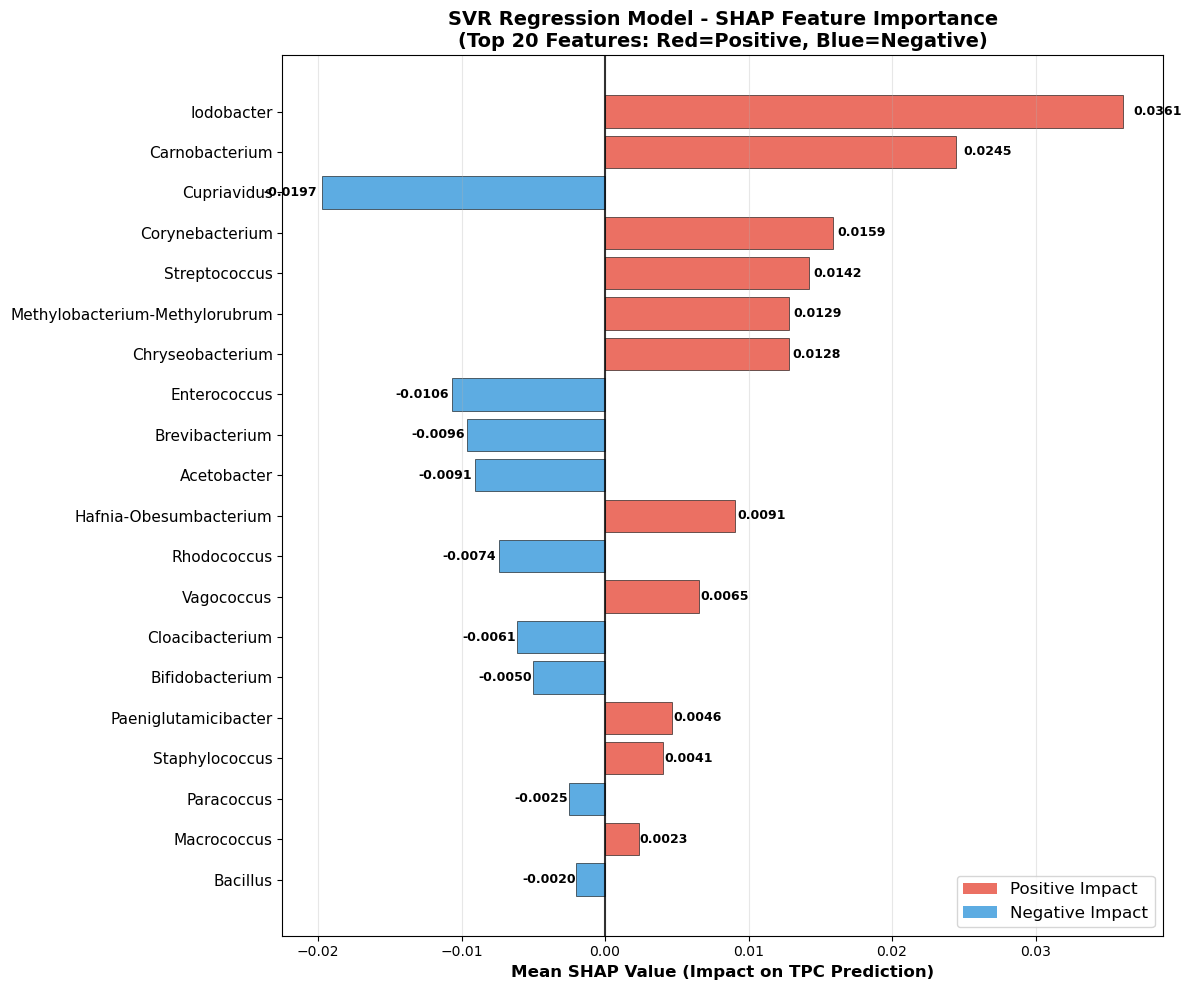


=== SVR SHAP Top 20 Features 분석 결과 ===
Positive Impact Features: 11개
Negative Impact Features: 9개
가장 강한 Positive Feature: Iodobacter
가장 강한 Negative Feature: Bacillus

=== Positive Impact Features (상위 순) ===
 1. Iodobacter                     | SHAP: +0.0361
 2. Carnobacterium                 | SHAP: +0.0245
 3. Corynebacterium                | SHAP: +0.0159
 4. Streptococcus                  | SHAP: +0.0142
 5. Methylobacterium-Methylorubrum | SHAP: +0.0129
 6. Chryseobacterium               | SHAP: +0.0128
 7. Hafnia-Obesumbacterium         | SHAP: +0.0091
 8. Vagococcus                     | SHAP: +0.0065
 9. Paeniglutamicibacter           | SHAP: +0.0046
10. Staphylococcus                 | SHAP: +0.0041
11. Macrococcus                    | SHAP: +0.0023

=== Negative Impact Features (강도 순) ===
 1. Cupriavidus                    | SHAP: -0.0197
 2. Enterococcus                   | SHAP: -0.0106
 3. Brevibacterium                 | SHAP: -0.0096
 4. Acetobacter                    | 

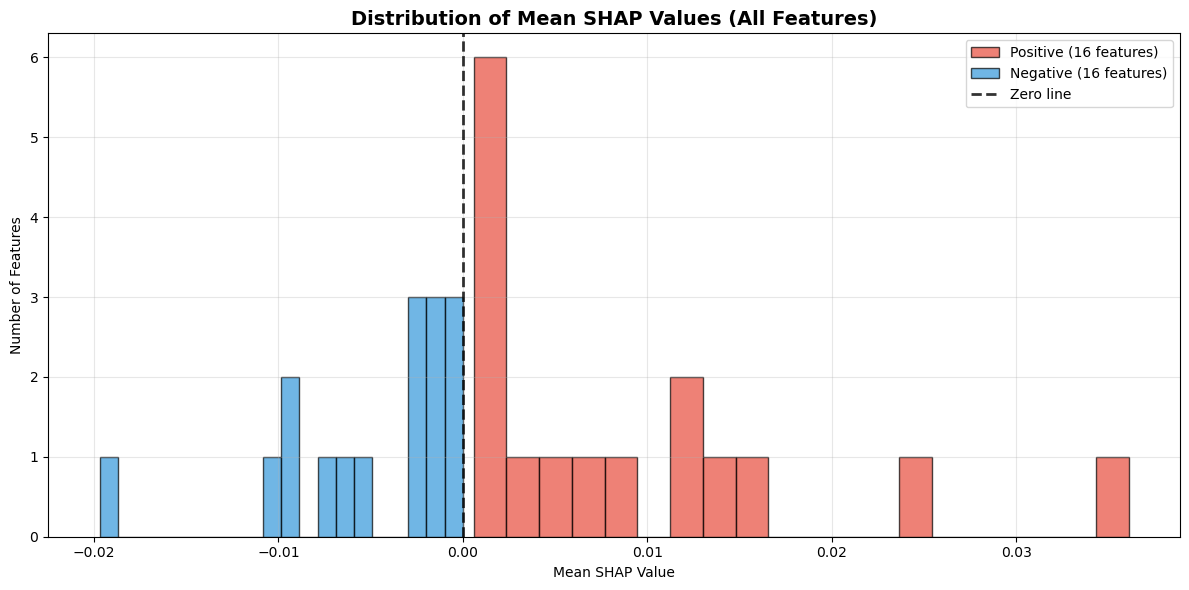


=== 전체 Feature 분포 ===
전체 Features: 32개
Positive Impact Features: 16개 (50.0%)
Negative Impact Features: 16개 (50.0%)


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap 

print("=== SVR 회귀 모델 SHAP Bar Plot (Positive/Negative 구분) ===")

# 1. 전체 Feature에 대한 평균 SHAP 값 계산 (positive/negative 구분)
mean_shap_values = np.mean(shap_values, axis=0)  # 각 feature별 평균 SHAP 값
abs_mean_shap_values = np.abs(mean_shap_values)  # 절댓값 (크기 순 정렬용)

# Feature 이름과 SHAP 값 매핑
shap_summary_df = pd.DataFrame({
    'Feature': genus_names,
    'Mean_SHAP': mean_shap_values,
    'Abs_Mean_SHAP': abs_mean_shap_values
}).sort_values('Abs_Mean_SHAP', ascending=True)  # 오름차순 정렬 (아래에서 위로)

# 상위 20개 Feature만 선택
top_20_shap = shap_summary_df.tail(20)

# 2. Positive/Negative에 따른 색상 설정
colors = ['#e74c3c' if val >= 0 else '#3498db' for val in top_20_shap['Mean_SHAP']]

# 3. Horizontal Bar Plot 생성
plt.figure(figsize=(12, 10))

bars = plt.barh(range(len(top_20_shap)), top_20_shap['Mean_SHAP'], 
                color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# Y축 설정 (Feature 이름)
plt.yticks(range(len(top_20_shap)), top_20_shap['Feature'], fontsize=11)

# X축 설정
plt.xlabel('Mean SHAP Value (Impact on TPC Prediction)', fontsize=12, fontweight='bold')
plt.title('SVR Regression Model - SHAP Feature Importance\n(Top 20 Features: Red=Positive, Blue=Negative)', 
          fontsize=14, fontweight='bold')

# 세로선 (0 기준선) 추가
plt.axvline(x=0, color='black', linewidth=1.5, alpha=0.8)

# 값 표시 (막대 끝에)
for i, (bar, mean_val, abs_val) in enumerate(zip(bars, top_20_shap['Mean_SHAP'], top_20_shap['Abs_Mean_SHAP'])):
    if mean_val >= 0:
        plt.text(mean_val + abs(mean_val)*0.02, bar.get_y() + bar.get_height()/2,
                 f'{mean_val:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')
    else:
        plt.text(mean_val - abs(mean_val)*0.02, bar.get_y() + bar.get_height()/2,
                 f'{mean_val:.4f}', ha='right', va='center', fontsize=9, fontweight='bold')

# 범례 추가
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor='#e74c3c', alpha=0.8, label='Positive Impact'),
    plt.Rectangle((0, 0), 1, 1, facecolor='#3498db', alpha=0.8, label='Negative Impact')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=12)

# 그리드 추가
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 4. 상세 통계 출력
positive_count = sum(top_20_shap['Mean_SHAP'] >= 0)
negative_count = sum(top_20_shap['Mean_SHAP'] < 0)

print(f"\n=== SVR SHAP Top 20 Features 분석 결과 ===")
print(f"Positive Impact Features: {positive_count}개")
print(f"Negative Impact Features: {negative_count}개")
print(f"가장 강한 Positive Feature: {top_20_shap[top_20_shap['Mean_SHAP'] >= 0]['Feature'].iloc[-1] if positive_count > 0 else 'None'}")
print(f"가장 강한 Negative Feature: {top_20_shap[top_20_shap['Mean_SHAP'] < 0]['Feature'].iloc[0] if negative_count > 0 else 'None'}")

# 5. Positive/Negative별 상세 리스트
print(f"\n=== Positive Impact Features (상위 순) ===")
positive_features = top_20_shap[top_20_shap['Mean_SHAP'] >= 0].sort_values('Mean_SHAP', ascending=False)
for i, (_, row) in enumerate(positive_features.iterrows(), 1):
    print(f"{i:2d}. {row['Feature']:<30} | SHAP: +{row['Mean_SHAP']:.4f}")

print(f"\n=== Negative Impact Features (강도 순) ===")
negative_features = top_20_shap[top_20_shap['Mean_SHAP'] < 0].sort_values('Mean_SHAP', ascending=True)
for i, (_, row) in enumerate(negative_features.iterrows(), 1):
    print(f"{i:2d}. {row['Feature']:<30} | SHAP: {row['Mean_SHAP']:.4f}")

# 6. 전체 Feature 분포 히스토그램 (Positive/Negative 구분)
plt.figure(figsize=(12, 6))

# 전체 평균 SHAP 값 분포
all_mean_shap = np.mean(shap_values, axis=0)
positive_shap = all_mean_shap[all_mean_shap >= 0]
negative_shap = all_mean_shap[all_mean_shap < 0]

plt.hist(positive_shap, bins=20, alpha=0.7, color='#e74c3c', label=f'Positive ({len(positive_shap)} features)', edgecolor='black')
plt.hist(negative_shap, bins=20, alpha=0.7, color='#3498db', label=f'Negative ({len(negative_shap)} features)', edgecolor='black')

plt.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.8, label='Zero line')
plt.xlabel('Mean SHAP Value')
plt.ylabel('Number of Features')
plt.title('Distribution of Mean SHAP Values (All Features)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n=== 전체 Feature 분포 ===")
print(f"전체 Features: {len(all_mean_shap)}개")
print(f"Positive Impact Features: {len(positive_shap)}개 ({len(positive_shap)/len(all_mean_shap)*100:.1f}%)")
print(f"Negative Impact Features: {len(negative_shap)}개 ({len(negative_shap)/len(all_mean_shap)*100:.1f}%)")



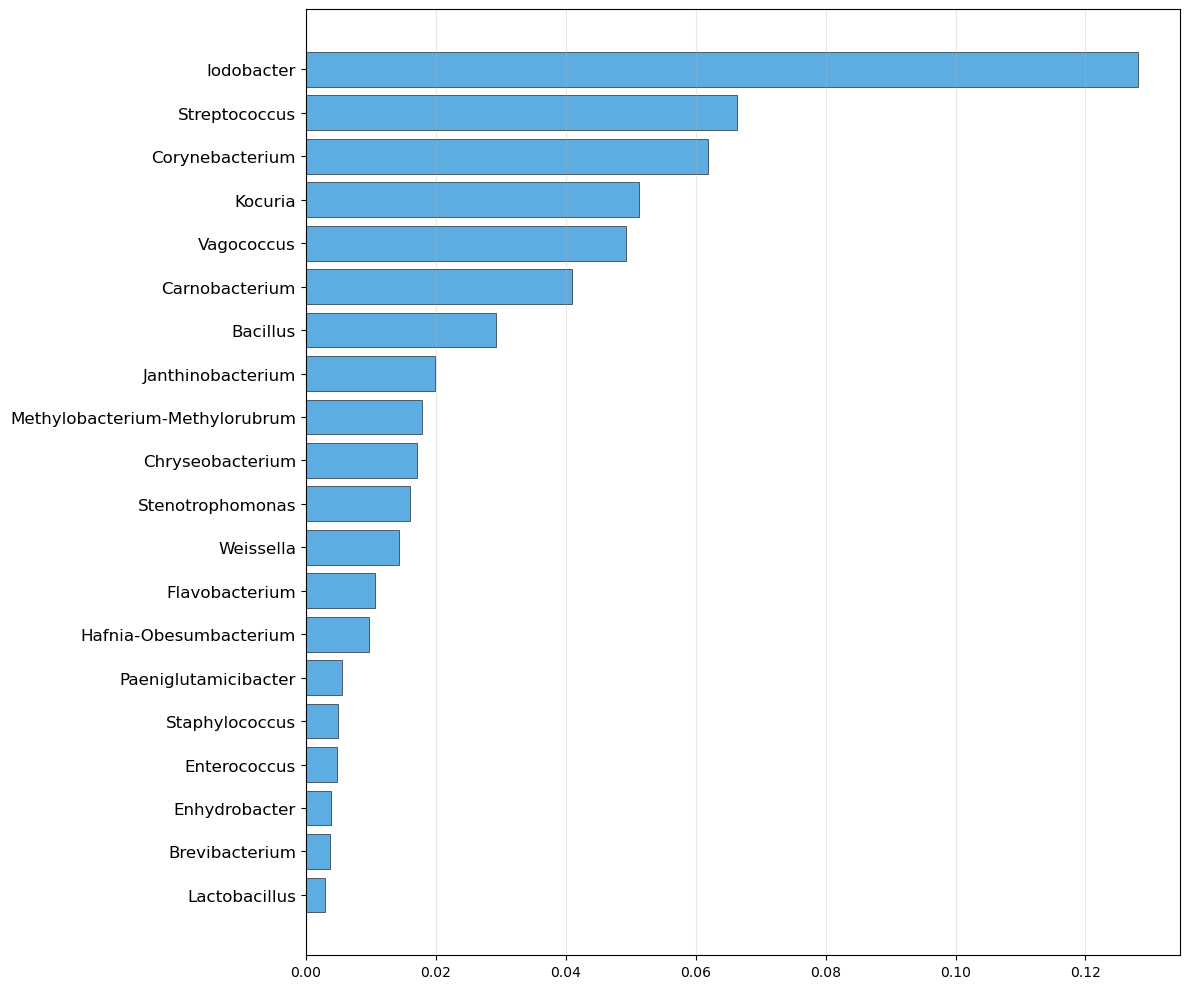


=== 상위 20개 Positive Impact Feature 분석 ===
 1. Iodobacter                | Positive Impact: 0.1281
 2. Streptococcus             | Positive Impact: 0.0664
 3. Corynebacterium           | Positive Impact: 0.0619
 4. Kocuria                   | Positive Impact: 0.0514
 5. Vagococcus                | Positive Impact: 0.0493
 6. Carnobacterium            | Positive Impact: 0.0410
 7. Bacillus                  | Positive Impact: 0.0293
 8. Janthinobacterium         | Positive Impact: 0.0200
 9. Methylobacterium-Methylorubrum | Positive Impact: 0.0179
10. Chryseobacterium          | Positive Impact: 0.0171
11. Stenotrophomonas          | Positive Impact: 0.0161
12. Weissella                 | Positive Impact: 0.0143
13. Flavobacterium            | Positive Impact: 0.0106
14. Hafnia-Obesumbacterium    | Positive Impact: 0.0098
15. Paeniglutamicibacter      | Positive Impact: 0.0055
16. Staphylococcus            | Positive Impact: 0.0050
17. Enterococcus              | Positive Impact: 0.0048


In [38]:
# 7. 전체 회귀 모델 Feature Importance Bar Plot (Positive 영향만, 상위 20개)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Positive 영향만 추출 (절댓값 적용)
positive_shap = np.where(shap_values > 0, shap_values, 0).mean(axis=0)
positive_importance = np.abs(positive_shap)

# Positive 영향이 있는 feature들만 필터링
positive_mask = positive_importance > 0
positive_features = np.array(genus_names)[positive_mask]
positive_values = positive_importance[positive_mask]

# 절댓값 기준으로 정렬하고 상위 20개 선택
sorted_idx = np.argsort(positive_values)[::-1][:20]  # 상위 20개만 선택
sorted_features = positive_features[sorted_idx]
sorted_values = positive_values[sorted_idx]

plt.figure(figsize=(12, len(sorted_features)*0.4 + 2))

# Positive 영향 (파란색)
bars = plt.barh(range(len(sorted_features)), sorted_values,
                color='#3498db', alpha=0.8, 
                edgecolor='black', linewidth=0.5)

plt.yticks(range(len(sorted_features)), sorted_features, fontsize=12)



# 그리드 추가
plt.grid(True, alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 상위 20개 positive feature 분석
print("\n=== 상위 20개 Positive Impact Feature 분석 ===")
for i in range(len(sorted_features)):
    feature = sorted_features[i]
    impact_val = sorted_values[i]
    
    print(f"{i+1:2d}. {feature:<25} | Positive Impact: {impact_val:.4f}")

print(f"\n총 Positive Impact Feature 수: {len(positive_features)}")
print(f"분석 대상 상위 Feature 수: {len(sorted_features)}")

In [20]:
import pytest
import numpy as np
import pandas as pd
from unittest.mock import Mock, patch, MagicMock
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import shap

# Jupyter Notebook에서는 이미 정의된 함수들을 직접 사용
# from VIP_TPC_analysis import ... 부분을 제거하고 직접 함수 참조

class TestSVRSHAPAnalysis:
    """Test suite for SVR SHAP analysis functionality"""
    
    @pytest.fixture
    def mock_level_data(self):
        """Mock level data for testing"""
        return {
            'features': pd.DataFrame({
                'g__Genus1': np.random.randn(100),
                'g__Genus2': np.random.randn(100),
                'g__Genus3': np.random.randn(100)
            }),
            'tpc': pd.Series(np.random.uniform(3, 8, 100))
        }
    
    @pytest.fixture
    def mock_vip_features(self):
        """Mock VIP features for testing"""
        return {
            'Genus': {
                'Feature': ['g__Genus1', 'g__Genus2', 'g__Genus3']
            }
        }
    
    @pytest.fixture
    def mock_shap_values(self):
        """Mock SHAP values for testing"""
        return np.random.randn(50, 3)
    
    def test_data_preparation(self, mock_level_data, mock_vip_features):
        """Test data preparation and filtering logic"""
        # 실제 notebook에 정의된 함수들을 직접 사용
        level_data = mock_level_data
        vip_features = mock_vip_features['Genus']['Feature']
        
        # Test genus names extraction
        genus_names = [f.replace('g__', '') for f in vip_features]
        assert len(genus_names) == 3
        assert 'Genus1' in genus_names
        assert 'Genus2' in genus_names
        
        # Test TPC labeling (notebook에 정의된 함수 사용)
        tpc_labels = tpc_labeling(level_data['tpc'])
        assert len(tpc_labels) == len(level_data['tpc'])
        assert all(label in [0, 1, 2] for label in tpc_labels)
        
        # Test fresh/middle filtering
        fresh_middle_mask = (tpc_labels == 0) | (tpc_labels == 1)
        assert isinstance(fresh_middle_mask, np.ndarray)
        assert fresh_middle_mask.dtype == bool
    
    def test_tpc_labeling_function(self):
        """Test TPC labeling function with known values"""
        tpc_values = pd.Series([3.0, 4.5, 6.0, 7.5])
        labels = tpc_labeling(tpc_values)
        
        assert isinstance(labels, np.ndarray)
        assert len(labels) == len(tpc_values)
        assert all(label in [0, 1, 2] for label in labels)
    
    def test_svr_pipeline_creation(self):
        """Test SVR pipeline creation and structure"""
        svr_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svr', SVR(C=10, gamma='scale', kernel='rbf'))
        ])
        
        assert len(svr_pipeline.steps) == 2
        assert svr_pipeline.steps[0][0] == 'scaler'
        assert svr_pipeline.steps[1][0] == 'svr'
        assert isinstance(svr_pipeline.named_steps['scaler'], StandardScaler)
        assert isinstance(svr_pipeline.named_steps['svr'], SVR)
    
    def test_shap_values_calculation(self, mock_shap_values):
        """Test SHAP values calculation and properties"""
        shap_values = mock_shap_values
        
        # Test shape
        assert shap_values.shape == (50, 3)
        
        # Test statistical properties
        assert isinstance(shap_values.min(), (float, np.floating))
        assert isinstance(shap_values.max(), (float, np.floating))
        assert isinstance(shap_values.mean(), (float, np.floating))
        assert isinstance(shap_values.std(), (float, np.floating))
        
        # Test absolute values
        abs_shap = np.abs(shap_values)
        assert abs_shap.min() >= 0
        assert abs_shap.max() >= 0
    
    def test_feature_importance_calculation(self, mock_shap_values):
        """Test feature importance calculation from SHAP values"""
        shap_values = mock_shap_values
        genus_names = ['Genus1', 'Genus2', 'Genus3']
        
        feature_importance = np.abs(shap_values).mean(axis=0)
        importance_df = pd.DataFrame({
            'Feature': genus_names,
            'SHAP_Importance': feature_importance
        }).sort_values('SHAP_Importance', ascending=False)
        
        assert len(importance_df) == 3
        assert 'Feature' in importance_df.columns
        assert 'SHAP_Importance' in importance_df.columns
        assert importance_df['SHAP_Importance'].is_monotonic_decreasing
        assert all(importance_df['SHAP_Importance'] >= 0)
    
    def test_feature_name_processing(self):
        """Test feature name processing (removing g__ prefix)"""
        vip_features = ['g__Genus1', 'g__Genus2', 'g__UnknownGenus']
        genus_names = [f.replace('g__', '') for f in vip_features]
        
        expected = ['Genus1', 'Genus2', 'UnknownGenus']
        assert genus_names == expected
        assert all(not name.startswith('g__') for name in genus_names)
    
    def test_error_handling_empty_vip_features(self):
        """Test error handling when VIP features list is empty"""
        vip_features = []
        
        # Should handle empty list gracefully
        genus_names = [f.replace('g__', '') for f in vip_features]
        assert len(genus_names) == 0

# Jupyter Notebook에서 직접 실행할 수 있는 간단한 테스트 함수들
def test_notebook_functions():
    """Notebook에서 직접 실행할 수 있는 테스트"""
    print("=== Notebook Functions Test ===")
    
    # 1. TPC labeling 테스트
    test_tpc = pd.Series([3.0, 4.5, 6.0, 7.5])
    labels = tpc_labeling(test_tpc)
    print(f"✅ TPC labeling test: {len(labels)} labels generated")
    
    # 2. Feature name processing 테스트
    test_features = ['g__Genus1', 'g__Genus2', 'g__Genus3']
    processed = [f.replace('g__', '') for f in test_features]
    print(f"✅ Feature processing test: {processed}")
    
    # 3. VIP features 존재 확인
    if 'vip_over1_dict' in globals() and 'Genus' in vip_over1_dict:
        genus_vip_count = len(vip_over1_dict['Genus'])
        print(f"✅ VIP features available: {genus_vip_count} features")
    else:
        print("❌ VIP features not available")
    
    # 4. Level data 확인
    if 'get_level_data' in globals():
        test_data = get_level_data('Genus')
        if test_data:
            print(f"✅ Level data available: {len(test_data['features'])} samples")
        else:
            print("❌ Level data not available")
    else:
        print("❌ get_level_data function not available")
    
    print("=== Test completed ===")

# 간단한 SHAP 분석 테스트
def test_shap_analysis_components():
    """SHAP 분석 구성요소 테스트"""
    print("=== SHAP Analysis Components Test ===")
    
    # 1. Mock SHAP values 생성
    mock_shap = np.random.randn(50, 10)
    print(f"✅ Mock SHAP values shape: {mock_shap.shape}")
    
    # 2. Feature importance 계산 테스트
    feature_importance = np.abs(mock_shap).mean(axis=0)
    print(f"✅ Feature importance calculated: {len(feature_importance)} features")
    
    # 3. Top features 선택 테스트
    mock_names = [f'Feature_{i}' for i in range(10)]
    importance_df = pd.DataFrame({
        'Feature': mock_names,
        'SHAP_Importance': feature_importance
    }).sort_values('SHAP_Importance', ascending=False)
    
    top_5 = importance_df.head(5)
    print(f"✅ Top 5 features selected: {list(top_5['Feature'])}")
    
    # 4. Statistics 계산 테스트
    stats = {
        'min': mock_shap.min(),
        'max': mock_shap.max(),
        'mean': mock_shap.mean(),
        'std': mock_shap.std()
    }
    print(f"✅ SHAP statistics: {stats}")
    
    print("=== SHAP test completed ===")

# 실행
if __name__ == "__main__":
    # Jupyter Notebook에서 바로 실행할 수 있는 테스트
    test_notebook_functions()
    test_shap_analysis_components()
    
    # pytest를 사용하고 싶다면 (선택적)
    # pytest.main(["-v", "--tb=short"])

=== Notebook Functions Test ===
✅ TPC labeling test: 4 labels generated
✅ Feature processing test: ['Genus1', 'Genus2', 'Genus3']
✅ VIP features available: 32 features
✅ Level data available: 270 samples
=== Test completed ===
=== SHAP Analysis Components Test ===
✅ Mock SHAP values shape: (50, 10)
✅ Feature importance calculated: 10 features
✅ Top 5 features selected: ['Feature_2', 'Feature_4', 'Feature_0', 'Feature_6', 'Feature_7']
✅ SHAP statistics: {'min': -3.110061128424912, 'max': 2.851321190400209, 'mean': -0.021735170701304346, 'std': 0.944526114862649}
=== SHAP test completed ===


=== SVR SHAP Top 20 Features의 VIP Score 확인 ===


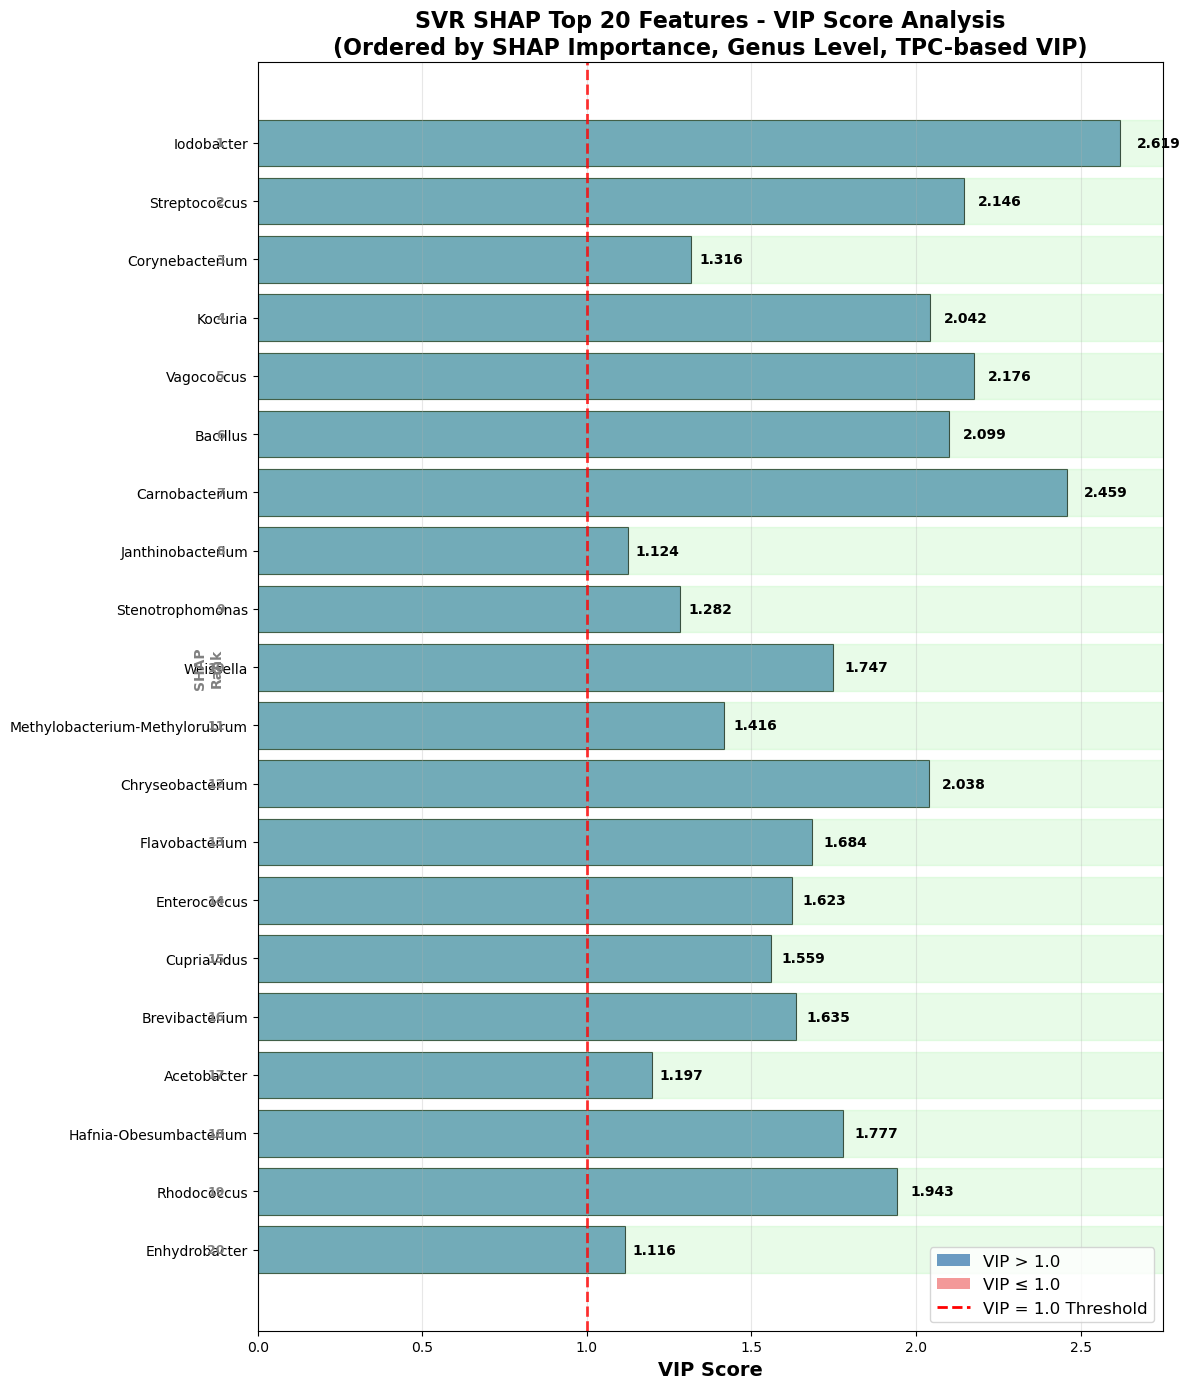


SVR SHAP Top 20 Features 통계:
  • 분석된 feature 수: 20
  • VIP > 1.0 feature 수: 20
  • 최고 VIP Score: 2.6187
  • 최저 VIP Score: 1.1159
  • 평균 VIP Score: 1.7499

SVR SHAP Top 20 Features - VIP Score 상세:
   1. Iodobacter                     | VIP: 2.6187 | SHAP: 0.2202 🟢
   2. Streptococcus                  | VIP: 2.1459 | SHAP: 0.1187 🟢
   3. Corynebacterium                | VIP: 1.3164 | SHAP: 0.1079 🟢
   4. Kocuria                        | VIP: 2.0425 | SHAP: 0.1047 🟢
   5. Vagococcus                     | VIP: 2.1758 | SHAP: 0.0921 🟢
   6. Bacillus                       | VIP: 2.0992 | SHAP: 0.0606 🟢
   7. Carnobacterium                 | VIP: 2.4592 | SHAP: 0.0576 🟢
   8. Janthinobacterium              | VIP: 1.1242 | SHAP: 0.0419 🟢
   9. Stenotrophomonas               | VIP: 1.2823 | SHAP: 0.0313 🟢
  10. Weissella                      | VIP: 1.7470 | SHAP: 0.0275 🟢
  11. Methylobacterium-Methylorubrum | VIP: 1.4161 | SHAP: 0.0230 🟢
  12. Chryseobacterium               | VIP: 2.0384 | SH

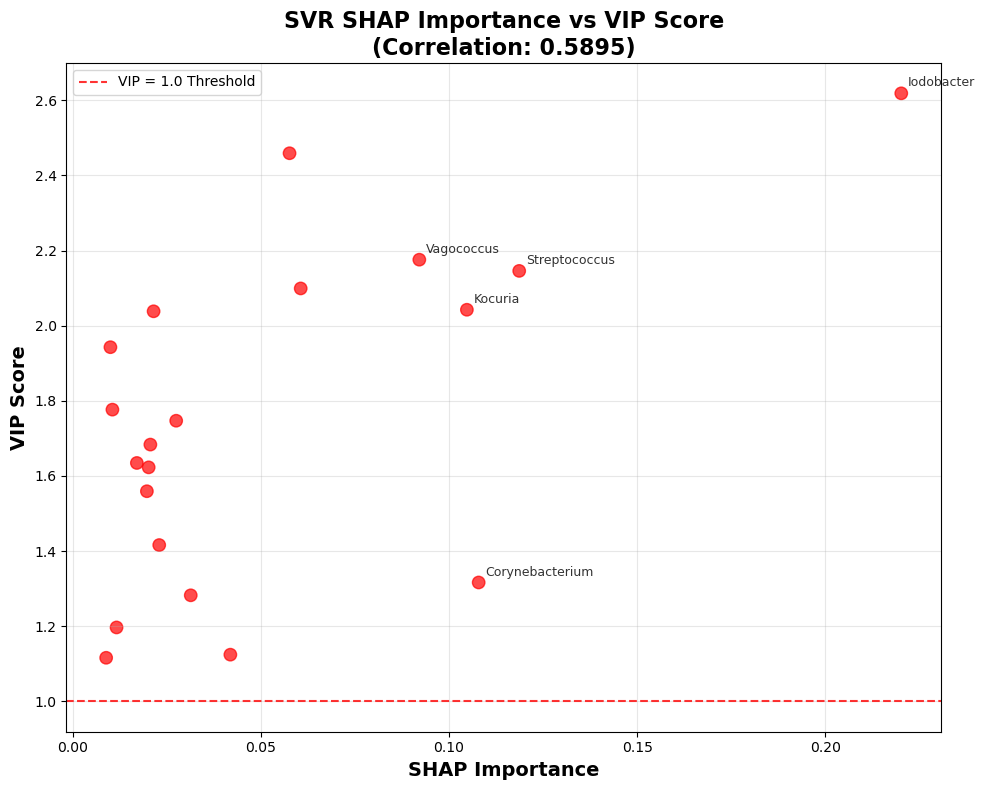


=== 요약 ===
SVR SHAP 상위 20개 feature 중 20개가 VIP > 1.0 기준을 만족합니다.
SHAP Importance와 VIP Score 간 상관계수는 0.5895입니다.


In [21]:
# SVR SHAP 상위 20개 feature들의 VIP Score 확인
print("=== SVR SHAP Top 20 Features의 VIP Score 확인 ===")

# SVR SHAP에서 나온 상위 20개 feature 이름 (g__ prefix 포함으로 변환)
svr_shap_top20_with_prefix = [f'g__{feat}' for feat in top_20_names]

# Genus level VIP 결과에서 해당 feature들의 VIP Score 추출
genus_vip_df = vip_over1_dict['Genus']

# SHAP 순서대로 VIP Score 매핑
shap_vip_mapping = []
for rank, feature in enumerate(svr_shap_top20_with_prefix, 1):
    vip_row = genus_vip_df[genus_vip_df['Feature'] == feature]
    if not vip_row.empty:
        vip_score = vip_row['VIP_Score'].iloc[0]
        shap_vip_mapping.append({
            'SHAP_Rank': rank,
            'Feature': feature,
            'Feature_Short': feature.replace('g__', ''),
            'VIP_Score': vip_score,
            'SHAP_Importance': top_20_features.iloc[rank-1]['SHAP_Importance']
        })
    else:
        print(f"⚠️ {feature}: VIP 데이터에서 찾을 수 없음")

# DataFrame 생성
shap_vip_df = pd.DataFrame(shap_vip_mapping)

# VIP Score 그래프 생성 (SHAP 순서 유지)
plt.figure(figsize=(12, 14))
colors = ['lightcoral' if score < 1.0 else 'steelblue' for score in shap_vip_df['VIP_Score']]

# Y축을 뒤집어서 SHAP 1위가 위에 오도록 설정
y_positions = list(range(len(shap_vip_df)))[::-1]
bars = plt.barh(y_positions, shap_vip_df['VIP_Score'], 
                color=colors, alpha=0.8, edgecolor='black', linewidth=0.8)

# VIP > 1.0 threshold 표시
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, alpha=0.8, label='VIP = 1.0 Threshold')

# 값 표시
for i, (bar, vip_score, shap_rank, shap_importance) in enumerate(zip(bars, shap_vip_df['VIP_Score'], 
                                                                     shap_vip_df['SHAP_Rank'], 
                                                                     shap_vip_df['SHAP_Importance'])):
    plt.text(vip_score + vip_score*0.02, bar.get_y() + bar.get_height()/2,
             f'{vip_score:.3f}', ha='left', va='center', fontsize=10, fontweight='bold')
    # SHAP 순위도 함께 표시
    plt.text(-0.1, bar.get_y() + bar.get_height()/2,
             f'{shap_rank}', ha='right', va='center', fontsize=9, fontweight='bold', color='gray')

# VIP > 1.0인 feature들에 배경색 추가
for i, score in enumerate(shap_vip_df['VIP_Score']):
    if score > 1.0:
        y_pos = y_positions[i]
        plt.axhspan(y_pos-0.4, y_pos+0.4, alpha=0.2, color='lightgreen')

# Y축 라벨 설정 (SHAP 순서대로)
plt.yticks(y_positions, shap_vip_df['Feature_Short'], fontsize=10)
plt.xlabel('VIP Score', fontsize=14, fontweight='bold')
plt.title('SVR SHAP Top 20 Features - VIP Score Analysis\n(Ordered by SHAP Importance, Genus Level, TPC-based VIP)', 
          fontsize=16, fontweight='bold')

# SHAP 순위 표시 추가
plt.text(-0.15, len(shap_vip_df)/2, 'SHAP\nRank', ha='center', va='center', 
         fontsize=10, fontweight='bold', color='gray', rotation=90)

# 범례 추가
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor='steelblue', alpha=0.8, label='VIP > 1.0'),
    plt.Rectangle((0, 0), 1, 1, facecolor='lightcoral', alpha=0.8, label='VIP ≤ 1.0'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='VIP = 1.0 Threshold')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=12)

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# 통계 출력 (SHAP 순서대로)
vip_over_1_count = sum(shap_vip_df['VIP_Score'] > 1.0)
print(f"\nSVR SHAP Top 20 Features 통계:")
print(f"  • 분석된 feature 수: {len(shap_vip_df)}")
print(f"  • VIP > 1.0 feature 수: {vip_over_1_count}")
print(f"  • 최고 VIP Score: {shap_vip_df['VIP_Score'].max():.4f}")
print(f"  • 최저 VIP Score: {shap_vip_df['VIP_Score'].min():.4f}")
print(f"  • 평균 VIP Score: {shap_vip_df['VIP_Score'].mean():.4f}")

# SHAP 순서별 feature와 VIP Score 출력
print(f"\nSVR SHAP Top 20 Features - VIP Score 상세:")
for _, row in shap_vip_df.iterrows():
    vip_status = "🟢" if row['VIP_Score'] > 1.0 else "🔴"
    print(f"  {row['SHAP_Rank']:2d}. {row['Feature_Short']:<30} | VIP: {row['VIP_Score']:.4f} | SHAP: {row['SHAP_Importance']:.4f} {vip_status}")

# SHAP Importance vs VIP Score 상관관계 분석
correlation = shap_vip_df['SHAP_Importance'].corr(shap_vip_df['VIP_Score'])
print(f"\nSHAP Importance와 VIP Score 간 상관계수: {correlation:.4f}")

# Scatter plot으로 SHAP vs VIP 관계 시각화
plt.figure(figsize=(10, 8))
colors_scatter = ['red' if score > 1.0 else 'blue' for score in shap_vip_df['VIP_Score']]
plt.scatter(shap_vip_df['SHAP_Importance'], shap_vip_df['VIP_Score'], 
           c=colors_scatter, alpha=0.7, s=80)

# VIP = 1.0 threshold line
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.8, label='VIP = 1.0 Threshold')

# Feature 이름 라벨링 (상위 5개만)
for i in range(min(5, len(shap_vip_df))):
    plt.annotate(shap_vip_df.iloc[i]['Feature_Short'], 
                (shap_vip_df.iloc[i]['SHAP_Importance'], shap_vip_df.iloc[i]['VIP_Score']),
                xytext=(5, 5), textcoords='offset points', fontsize=9, alpha=0.8)

plt.xlabel('SHAP Importance', fontsize=14, fontweight='bold')
plt.ylabel('VIP Score', fontsize=14, fontweight='bold')
plt.title(f'SVR SHAP Importance vs VIP Score\n(Correlation: {correlation:.4f})', 
          fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n=== 요약 ===")
print(f"SVR SHAP 상위 20개 feature 중 {vip_over_1_count}개가 VIP > 1.0 기준을 만족합니다.")
print(f"SHAP Importance와 VIP Score 간 상관계수는 {correlation:.4f}입니다.")

## Carnobacteriun, Aeromonas만 SHAP 확인

=== 전체 SVR SHAP 결과에서 Carnobacterium & Aeromonas 추출 (수정) ===
✅ Carnobacterium: 전체 feature 목록에서 2번째 위치
✅ Aeromonas: 전체 feature 목록에서 12번째 위치

추출된 SHAP 값 shape: (47, 2)
Feature 이름: ['Carnobacterium', 'Aeromonas']
전체 SHAP 값 범위: -0.3914 ~ 0.3818
추출된 2개 feature SHAP 값 범위: -0.0725 ~ 0.2557


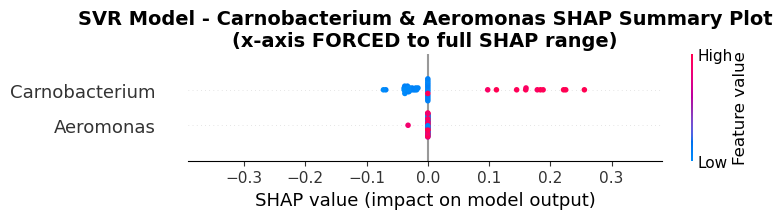

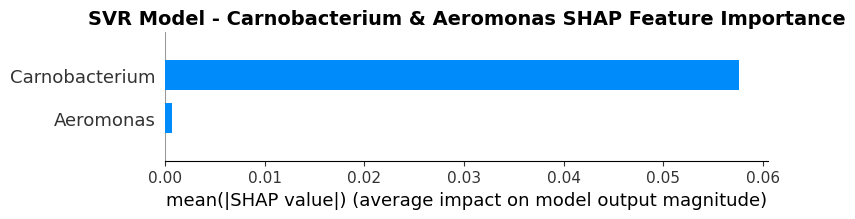

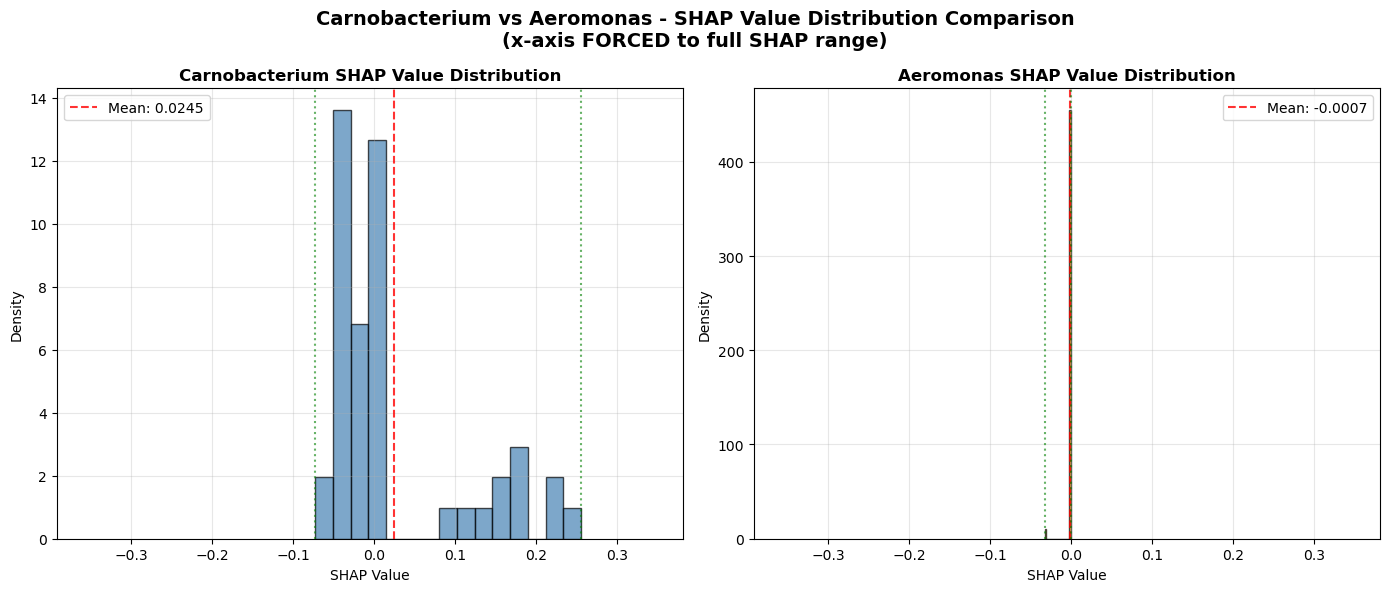


=== 상세 SHAP 값 통계 비교 ===

[Carnobacterium]
  평균 SHAP 값: 0.024472
  표준편차: 0.087903
  최솟값: -0.072467
  최댓값: 0.255688
  절댓값 평균 (중요도): 0.057607
  전체 SHAP 범위와의 비교:
    - 전체 최솟값과의 차이: 0.318938
    - 전체 최댓값과의 차이: 0.126151

[Aeromonas]
  평균 SHAP 값: -0.000686
  표준편차: 0.004654
  최솟값: -0.032252
  최댓값: 0.000000
  절댓값 평균 (중요도): 0.000686
  전체 SHAP 범위와의 비교:
    - 전체 최솟값과의 차이: 0.359153
    - 전체 최댓값과의 차이: 0.381839

=== 전체 Top 20에서의 실제 순위 확인 ===
🏆 Carnobacterium: Top 20 중 7위 (SHAP: 0.057607)
📊 Aeromonas: 전체 12위 (SHAP: 0.000686) - Top 20 밖

=== 범위 검증 결과 ===
전체 SHAP 범위: -0.391405 ~ 0.381839
추출된 2개 feature SHAP 범위: -0.072467 ~ 0.255688
범위 내 포함 여부: True


In [22]:
# 전체 SVR SHAP 분석에서 Carnobacterium과 Aeromonas만 추출 (x축 범위 제대로 통일)
print("=== 전체 SVR SHAP 결과에서 Carnobacterium & Aeromonas 추출 (수정) ===")

# 타겟 genus 이름
target_genus = ['Carnobacterium', 'Aeromonas']

# 전체 genus_names에서 해당 genus들의 인덱스 찾기
target_indices = []
target_names = []

for genus in target_genus:
    if genus in genus_names:
        idx = genus_names.index(genus)
        target_indices.append(idx)
        target_names.append(genus)
        print(f"✅ {genus}: 전체 feature 목록에서 {idx+1}번째 위치")
    else:
        print(f"❌ {genus}: VIP > 1.0 feature 목록에 없음")

if target_indices:
    # 전체 SHAP 값에서 해당 genus들만 추출
    carnobacterium_aeromonas_shap = shap_values[:, target_indices]
    carnobacterium_aeromonas_test = test_sample[:, target_indices]
    
    print(f"\n추출된 SHAP 값 shape: {carnobacterium_aeromonas_shap.shape}")
    print(f"Feature 이름: {target_names}")
    
    # 전체 SHAP 값 범위 계산 (x축 통일을 위해)
    all_shap_values = shap_values.flatten()
    global_min = all_shap_values.min()
    global_max = all_shap_values.max()
    print(f"전체 SHAP 값 범위: {global_min:.4f} ~ {global_max:.4f}")
    
    # 추출된 2개 feature의 SHAP 값 범위 확인
    extracted_min = carnobacterium_aeromonas_shap.min()
    extracted_max = carnobacterium_aeromonas_shap.max()
    print(f"추출된 2개 feature SHAP 값 범위: {extracted_min:.4f} ~ {extracted_max:.4f}")
    
    # 1. Carnobacterium & Aeromonas SHAP Summary Plot (x축 범위 강제 통일)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        carnobacterium_aeromonas_shap, 
        carnobacterium_aeromonas_test, 
        feature_names=target_names,
        show=False
    )
    # x축 범위를 전체 SHAP 값 범위로 강제 설정
    plt.xlim(global_min, global_max)
    plt.title('SVR Model - Carnobacterium & Aeromonas SHAP Summary Plot\n(x-axis FORCED to full SHAP range)', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 2. Carnobacterium & Aeromonas SHAP Bar Plot
    plt.figure(figsize=(8, 5))
    shap.summary_plot(
        carnobacterium_aeromonas_shap, 
        carnobacterium_aeromonas_test, 
        feature_names=target_names,
        plot_type="bar",
        show=False
    )
    plt.title('SVR Model - Carnobacterium & Aeromonas SHAP Feature Importance', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 3. 개별 Feature SHAP 값 분포 비교 (x축 범위 강제 통일)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for i, (genus_name, shap_vals) in enumerate(zip(target_names, carnobacterium_aeromonas_shap.T)):
        ax = axes[i]
        ax.hist(shap_vals, bins=15, alpha=0.7, color=['steelblue', 'orange'][i], 
                edgecolor='black', density=True)
        ax.set_title(f'{genus_name} SHAP Value Distribution', fontsize=12, fontweight='bold')
        ax.set_xlabel('SHAP Value')
        ax.set_ylabel('Density')
        ax.set_xlim(global_min, global_max)  # x축 범위 강제 통일
        ax.grid(True, alpha=0.3)
        
        # 통계 정보 추가
        mean_shap = np.mean(shap_vals)
        std_shap = np.std(shap_vals)
        ax.axvline(mean_shap, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_shap:.4f}')
        ax.legend()
        
        # 실제 데이터 범위도 표시
        ax.axvline(shap_vals.min(), color='green', linestyle=':', alpha=0.6, label=f'Min: {shap_vals.min():.4f}')
        ax.axvline(shap_vals.max(), color='green', linestyle=':', alpha=0.6, label=f'Max: {shap_vals.max():.4f}')
    
    plt.suptitle('Carnobacterium vs Aeromonas - SHAP Value Distribution Comparison\n(x-axis FORCED to full SHAP range)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 4. 상세 통계 비교
    print(f"\n=== 상세 SHAP 값 통계 비교 ===")
    for i, (genus_name, shap_vals) in enumerate(zip(target_names, carnobacterium_aeromonas_shap.T)):
        print(f"\n[{genus_name}]")
        print(f"  평균 SHAP 값: {np.mean(shap_vals):.6f}")
        print(f"  표준편차: {np.std(shap_vals):.6f}")
        print(f"  최솟값: {np.min(shap_vals):.6f}")
        print(f"  최댓값: {np.max(shap_vals):.6f}")
        print(f"  절댓값 평균 (중요도): {np.mean(np.abs(shap_vals)):.6f}")
        print(f"  전체 SHAP 범위와의 비교:")
        print(f"    - 전체 최솟값과의 차이: {np.min(shap_vals) - global_min:.6f}")
        print(f"    - 전체 최댓값과의 차이: {global_max - np.max(shap_vals):.6f}")
    
    # 5. 전체 Top 20에서의 실제 순위 확인
    print(f"\n=== 전체 Top 20에서의 실제 순위 확인 ===")
    for genus in target_names:
        if genus in top_20_names:
            rank = top_20_names.index(genus) + 1
            shap_score = top_20_features[top_20_features['Feature'] == genus]['SHAP_Importance'].iloc[0]
            print(f"🏆 {genus}: Top 20 중 {rank}위 (SHAP: {shap_score:.6f})")
        else:
            # 전체 importance_df에서 찾기
            if genus in importance_df['Feature'].values:
                full_rank = importance_df[importance_df['Feature'] == genus].index[0] + 1
                shap_score = importance_df[importance_df['Feature'] == genus]['SHAP_Importance'].iloc[0]
                print(f"📊 {genus}: 전체 {full_rank}위 (SHAP: {shap_score:.6f}) - Top 20 밖")
            else:
                print(f"❌ {genus}: 전체 importance_df에서도 찾을 수 없음")
    
    print(f"\n=== 범위 검증 결과 ===")
    print(f"전체 SHAP 범위: {global_min:.6f} ~ {global_max:.6f}")
    print(f"추출된 2개 feature SHAP 범위: {extracted_min:.6f} ~ {extracted_max:.6f}")
    print(f"범위 내 포함 여부: {global_min <= extracted_min and extracted_max <= global_max}")
    
else:
    print("❌ Carnobacterium과 Aeromonas 모두 VIP > 1.0 feature 목록에 없습니다.")

## 

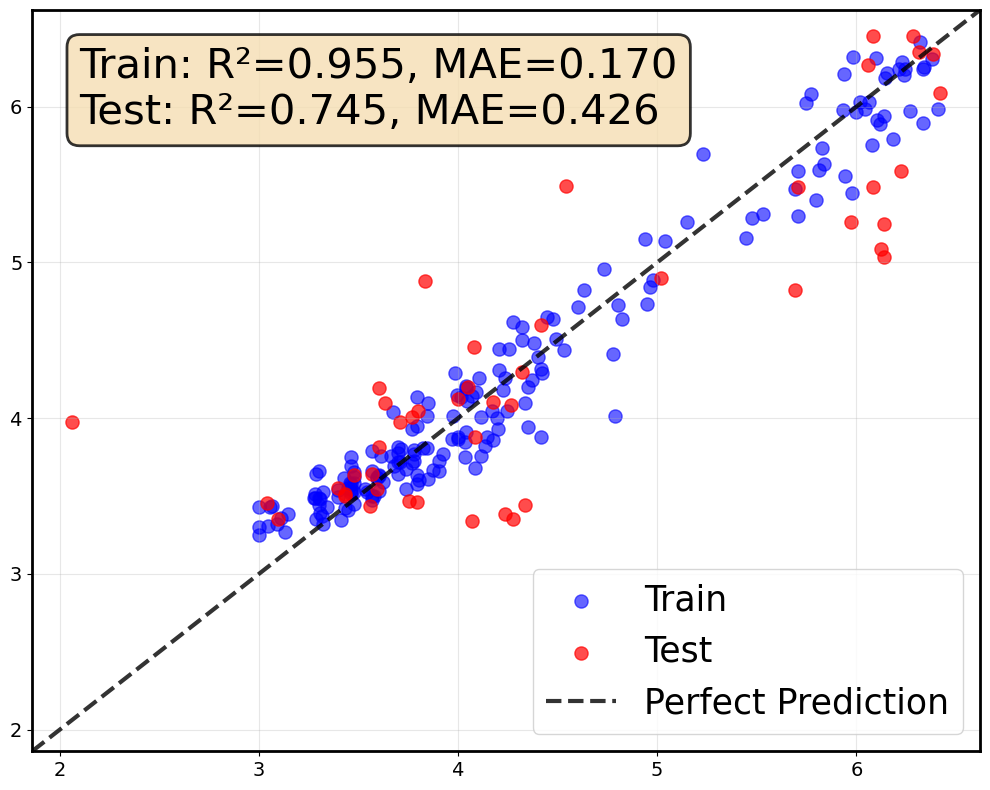

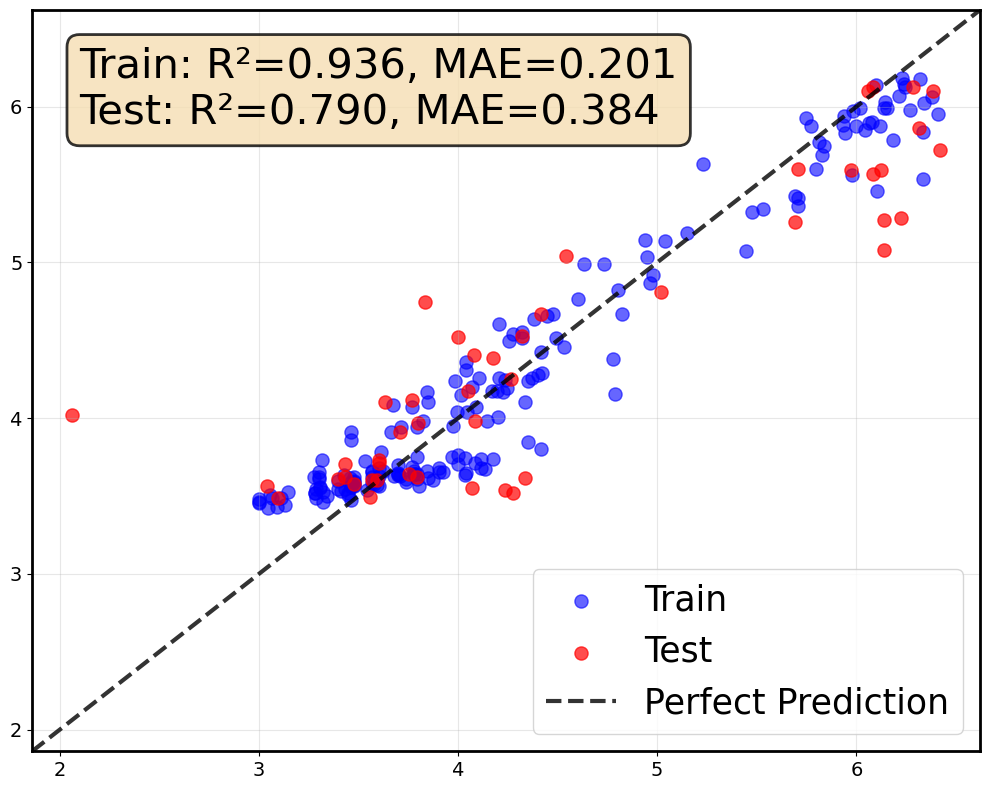

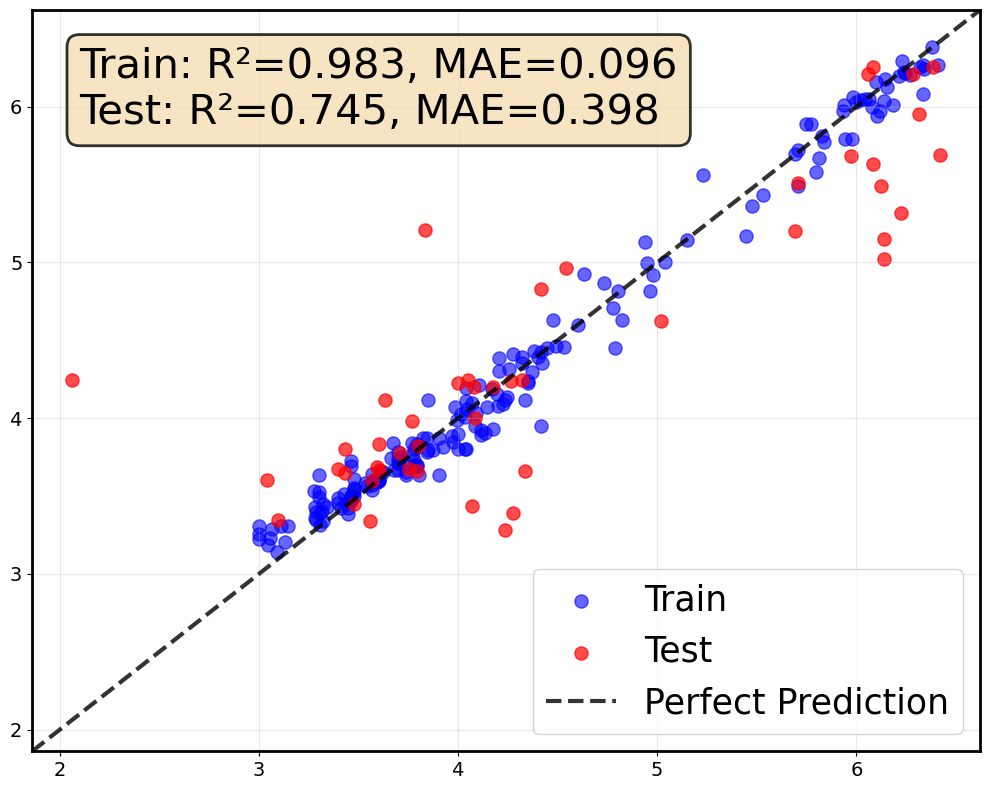

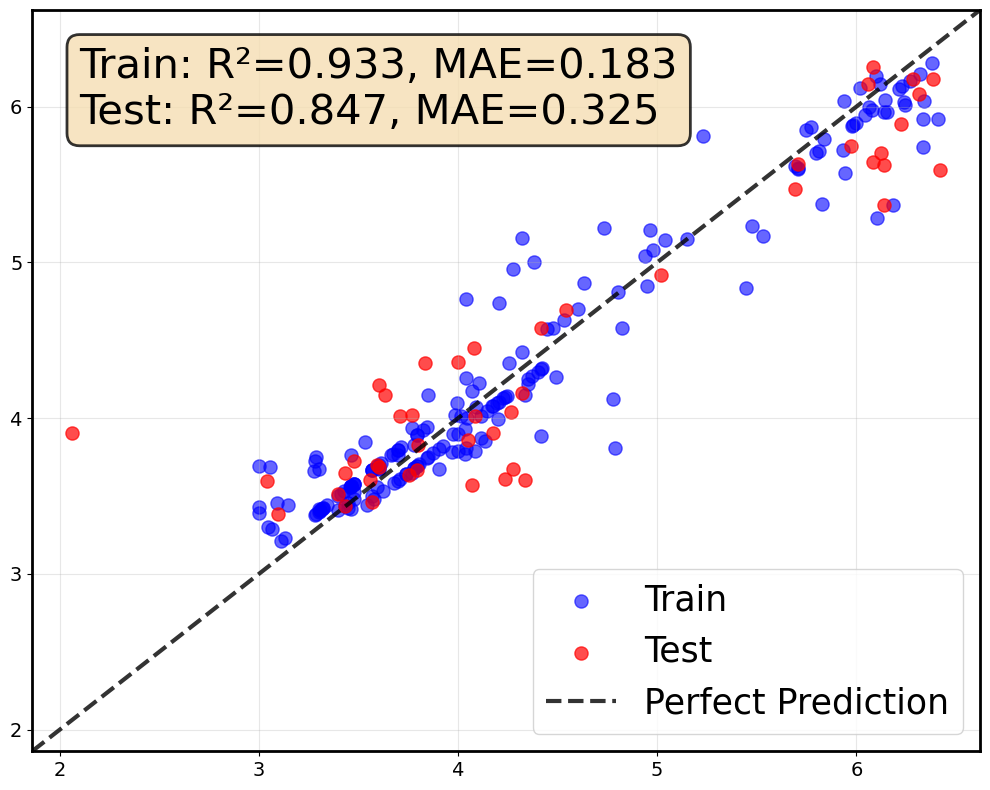

In [23]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ['LightGBM', 'RandomForest', 'XGBoost', 'SVR']
colors = {'Train': 'blue', 'Test': 'red'}

# 전체 데이터 범위 계산
all_actual = np.concatenate([y_train, y_test])
min_val = all_actual.min() - 0.2
max_val = all_actual.max() + 0.2

for model_name in model_names:
    pred_data = tpc_model_predictions[model_name]
    fig, ax = plt.subplots(figsize=(10, 8))
    # Train 데이터
    ax.scatter(pred_data['y_train'], pred_data['y_train_pred'],
               alpha=0.6, color=colors['Train'], label='Train', s=90)
    # Test 데이터
    ax.scatter(pred_data['y_test'], pred_data['y_test_pred'],
               alpha=0.7, color=colors['Test'], label='Test', s=90)
    # 완벽 예측선
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, linewidth=3, label='Perfect Prediction')

    # 성능 텍스트 박스
    textstr = f'Train: R²={pred_data["train_r2"]:.3f}, MAE={pred_data["train_mae"]:.3f}\nTest: R²={pred_data["test_r2"]:.3f}, MAE={pred_data["test_mae"]:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=2)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=30,
            verticalalignment='top', bbox=props)

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(True, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    ax.legend(fontsize=25)

    plt.tight_layout()
    plt.savefig(f'model_result/TPC_Pred_vs_Actual_{model_name}.png', dpi=300)
    plt.show()

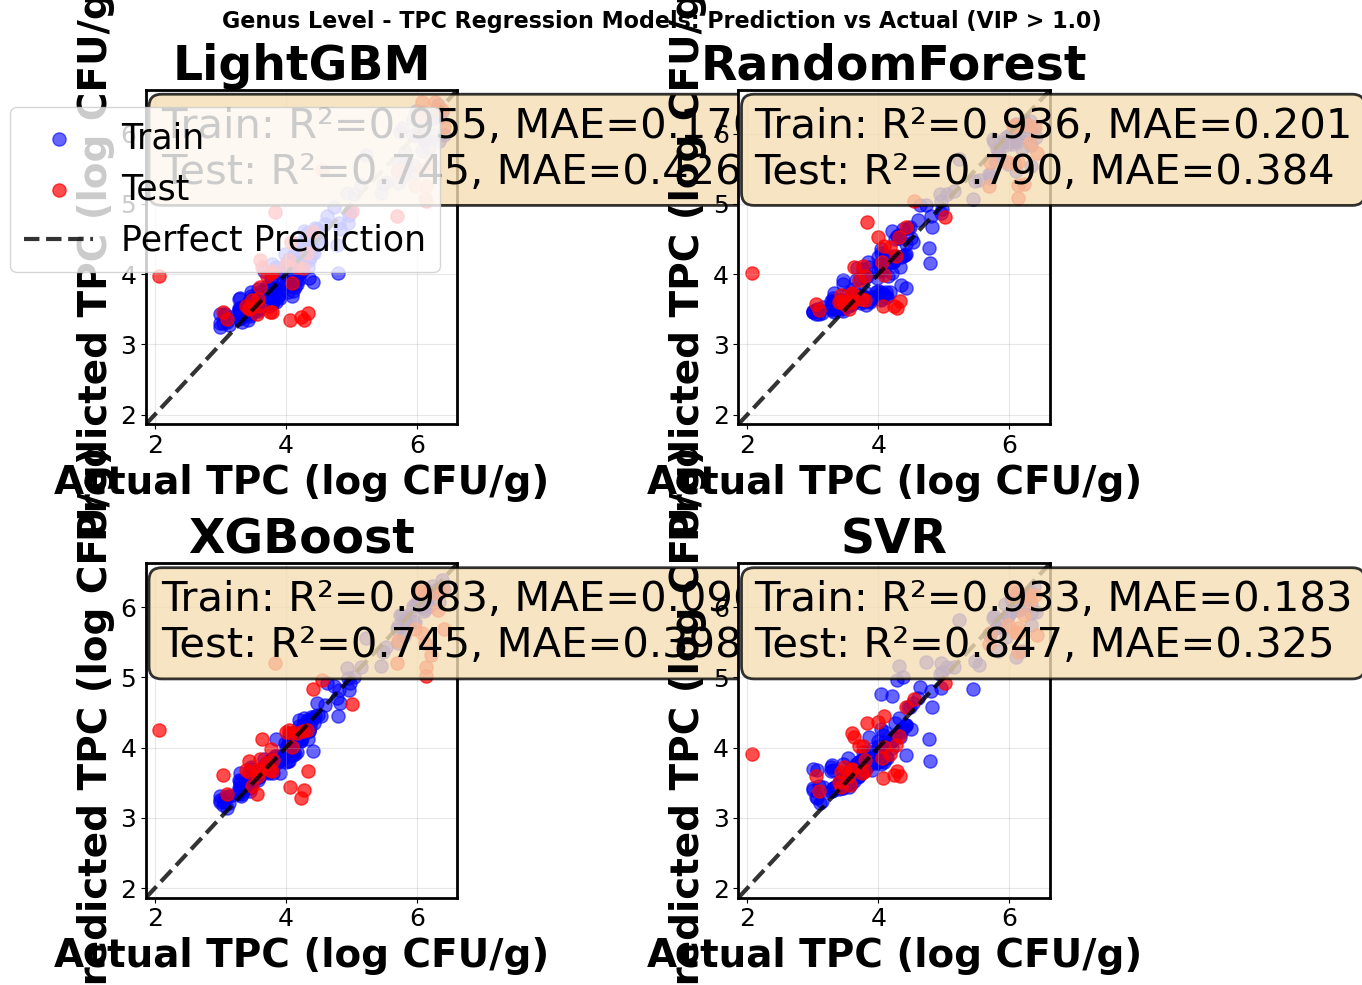

In [24]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ['LightGBM', 'RandomForest', 'XGBoost', 'SVR']
colors = {'Train': 'blue', 'Test': 'red'}

# 전체 데이터 범위 계산
all_actual = np.concatenate([y_train, y_test])
min_val = all_actual.min() - 0.2
max_val = all_actual.max() + 0.2

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Genus Level - TPC Regression Models: Prediction vs Actual (VIP > 1.0)', fontsize=16, fontweight='bold')

for i, model_name in enumerate(model_names):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    pred_data = tpc_model_predictions[model_name]

    # Train 데이터
    ax.scatter(pred_data['y_train'], pred_data['y_train_pred'],
               alpha=0.6, color=colors['Train'], label='Train', s=90)
    # Test 데이터
    ax.scatter(pred_data['y_test'], pred_data['y_test_pred'],
               alpha=0.7, color=colors['Test'], label='Test', s=90)
    # 완벽 예측선
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.8, linewidth=3, label='Perfect Prediction')

    # 성능 텍스트 박스
    textstr = f'Train: R²={pred_data["train_r2"]:.3f}, MAE={pred_data["train_mae"]:.3f}\nTest: R²={pred_data["test_r2"]:.3f}, MAE={pred_data["test_mae"]:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8, edgecolor='black', linewidth=2)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=30,
            verticalalignment='top', bbox=props)

    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_xlabel('Actual TPC (log CFU/g)', fontsize=28, fontweight='bold')
    ax.set_ylabel('Predicted TPC (log CFU/g)', fontsize=28, fontweight='bold')
    ax.set_title(f'{model_name}', fontsize=34, fontweight='bold')
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.grid(True, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)
    if i == 0:
        ax.legend(fontsize=25)

plt.tight_layout()
plt.show()

### 티발스

In [25]:
# TBARS 회귀 모델 학습 (VIP > 1.0 Feature 사용)
print("=== TBARS 회귀 모델 학습 (VIP > 1.0 Features) ===")

# Genus level에서 TBARS 기준 VIP > 1.0 Feature 사용
vip_features_tbars = vip_score_tbars[level_name]['Feature'].tolist()

if not vip_features_tbars:
    print("TBARS 기준 VIP > 1.0 feature가 없습니다.")
else:
    print(f"TBARS 기준 VIP > 1.0 Feature 수: {len(vip_features_tbars)}")
    
    # Feature와 Target 분리
    X_tbars = level_data['features'][vip_features_tbars].values
    y_tbars = level_data['tbars'].values
    
    print(f"Feature 수: {len(vip_features_tbars)}")
    print(f"TBARS Target 범위: {y_tbars.min():.3f} ~ {y_tbars.max():.3f}")
    
    # Train-Test Split
    X_train_tbars, X_test_tbars, y_train_tbars, y_test_tbars = train_test_split(
        X_tbars, y_tbars, test_size=0.2, random_state=42
    )
    
    print(f"Train set: {X_train_tbars.shape[0]}개")
    print(f"Test set: {X_test_tbars.shape[0]}개")
    
    # 모델 학습 및 평가
    tbars_results = []
    
    for model_name, model_config in models.items():
        print(f"\n--- {model_name} 학습 중 ---")
        
        # GridSearchCV
        grid = GridSearchCV(
            model_config['model'], 
            model_config['params'], 
            cv=5, 
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )
        
        grid.fit(X_train_tbars, y_train_tbars)
        best_model = grid.best_estimator_
        
        # 예측
        y_train_pred = best_model.predict(X_train_tbars)
        y_test_pred = best_model.predict(X_test_tbars)
        
        # Cross Validation
        cv_mae = -cross_val_score(best_model, X_train_tbars, y_train_tbars, cv=5, scoring='neg_mean_absolute_error')
        cv_rmse = np.sqrt(-cross_val_score(best_model, X_train_tbars, y_train_tbars, cv=5, scoring='neg_mean_squared_error'))
        cv_r2 = cross_val_score(best_model, X_train_tbars, y_train_tbars, cv=5, scoring='r2')
        
        # 성능 계산
        train_metrics = calculate_metrics(y_train_tbars, y_train_pred, "Train_")
        test_metrics = calculate_metrics(y_test_tbars, y_test_pred, "Test_")
        
        # Overfitting 지표
        overfit_mae = train_metrics["Train_MAE"] - test_metrics["Test_MAE"]
        overfit_rmse = train_metrics["Train_RMSE"] - test_metrics["Test_RMSE"]
        overfit_r2 = train_metrics["Train_R2"] - test_metrics["Test_R2"]
        overfit_rsd = train_metrics["Train_RSD"] - test_metrics["Test_RSD"]
        
        # 결과 저장
        result = {
            "Taxonomy_Level": "Genus",
            "Model": model_name,
            "Train_MAE": train_metrics["Train_MAE"],
            "Test_MAE": test_metrics["Test_MAE"],
            "Train_RMSE": train_metrics["Train_RMSE"],
            "Test_RMSE": test_metrics["Test_RMSE"],
            "Train_R2": train_metrics["Train_R2"],
            "Test_R2": test_metrics["Test_R2"],
            "Train_RSD": train_metrics["Train_RSD"],
            "Test_RSD": test_metrics["Test_RSD"],
            "Overfit_MAE": overfit_mae,
            "Overfit_RMSE": overfit_rmse,
            "Overfit_R2": overfit_r2,
            "Overfit_RSD": overfit_rsd,
            "CV_MAE_Mean": cv_mae.mean(),
            "CV_RMSE_Mean": cv_rmse.mean(),
            "CV_R2_Mean": cv_r2.mean(),
            "Best_Params": str(grid.best_params_)
        }
        
        tbars_results.append(result)
        
        print(f"Best Params: {grid.best_params_}")
        print(f"Test MAE: {test_metrics['Test_MAE']:.4f}")
        print(f"Test RMSE: {test_metrics['Test_RMSE']:.4f}")
        print(f"Test R2: {test_metrics['Test_R2']:.4f}")
    
    # 결과 DataFrame 생성
    tbars_results_df = pd.DataFrame(tbars_results)
    
    print("\n=== TBARS 회귀 모델 성능 결과 (VIP > 1.0 Features) ===")
    print(tbars_results_df)

=== TBARS 회귀 모델 학습 (VIP > 1.0 Features) ===
TBARS 기준 VIP > 1.0 Feature 수: 48
Feature 수: 48
TBARS Target 범위: 0.100 ~ 0.555
Train set: 216개
Test set: 54개

--- LightGBM 학습 중 ---


/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed 

Best Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
Test MAE: 0.0691
Test RMSE: 0.0892
Test R2: 0.2892

--- RandomForest 학습 중 ---
Best Params: {'max_depth': 7, 'min_samples_split': 5, 'n_estimators': 100}
Test MAE: 0.0635
Test RMSE: 0.0846
Test R2: 0.3611

--- XGBoost 학습 중 ---
Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Test MAE: 0.0632
Test RMSE: 0.0818
Test R2: 0.4021

--- SVR 학습 중 ---
Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Test MAE: 0.0704
Test RMSE: 0.0845
Test R2: 0.3617

=== TBARS 회귀 모델 성능 결과 (VIP > 1.0 Features) ===
  Taxonomy_Level         Model  Train_MAE  Test_MAE  Train_RMSE  Test_RMSE  \
0          Genus      LightGBM   0.014605  0.069138    0.020246   0.089200   
1          Genus  RandomForest   0.028926  0.063503    0.036603   0.084567   
2          Genus       XGBoost   0.032858  0.063228    0.042652   0.081812   
3          Genus           SVR   0.058797  0.070418    0.069240   0.084529   

   Train_

In [26]:
# TBARS 결과 저장 - CLR_KMenas_변화_tbars 파일명으로 저장
tbars_results_df.to_excel("model_result/CLR_KMenas_변화_tbars.xlsx", index=False)
print(f"\nTBARS 결과가 'model_result/CLR_KMenas_변화_tbars.xlsx'에 저장되었습니다.")

# 추가적인 상세 정보도 함께 저장
with pd.ExcelWriter("model_result/CLR_KMenas_변화_tbars_상세.xlsx") as writer:
    # 모델 성능 결과
    tbars_results_df.to_excel(writer, sheet_name='모델성능', index=False)
    
    # 데이터 정보
    data_info = pd.DataFrame({
        'Info': ['데이터 수', 'VIP Feature 수', 'Train 데이터 수', 'Test 데이터 수', 'Target 최소값', 'Target 최대값'],
        'Value': [len(y_tbars), len(vip_features_tbars), X_train_tbars.shape[0], X_test_tbars.shape[0], y_tbars.min(), y_tbars.max()]
    })
    data_info.to_excel(writer, sheet_name='데이터정보', index=False)
    
    # VIP Feature 이름
    feature_info = pd.DataFrame({'VIP_Features': vip_features_tbars})
    feature_info.to_excel(writer, sheet_name='VIP_Feature목록', index=False)

print(f"TBARS 상세 결과가 'model_result/CLR_KMenas_변화_tbars_상세.xlsx'에 저장되었습니다.")


TBARS 결과가 'model_result/CLR_KMenas_변화_tbars.xlsx'에 저장되었습니다.
TBARS 상세 결과가 'model_result/CLR_KMenas_변화_tbars_상세.xlsx'에 저장되었습니다.


/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed 

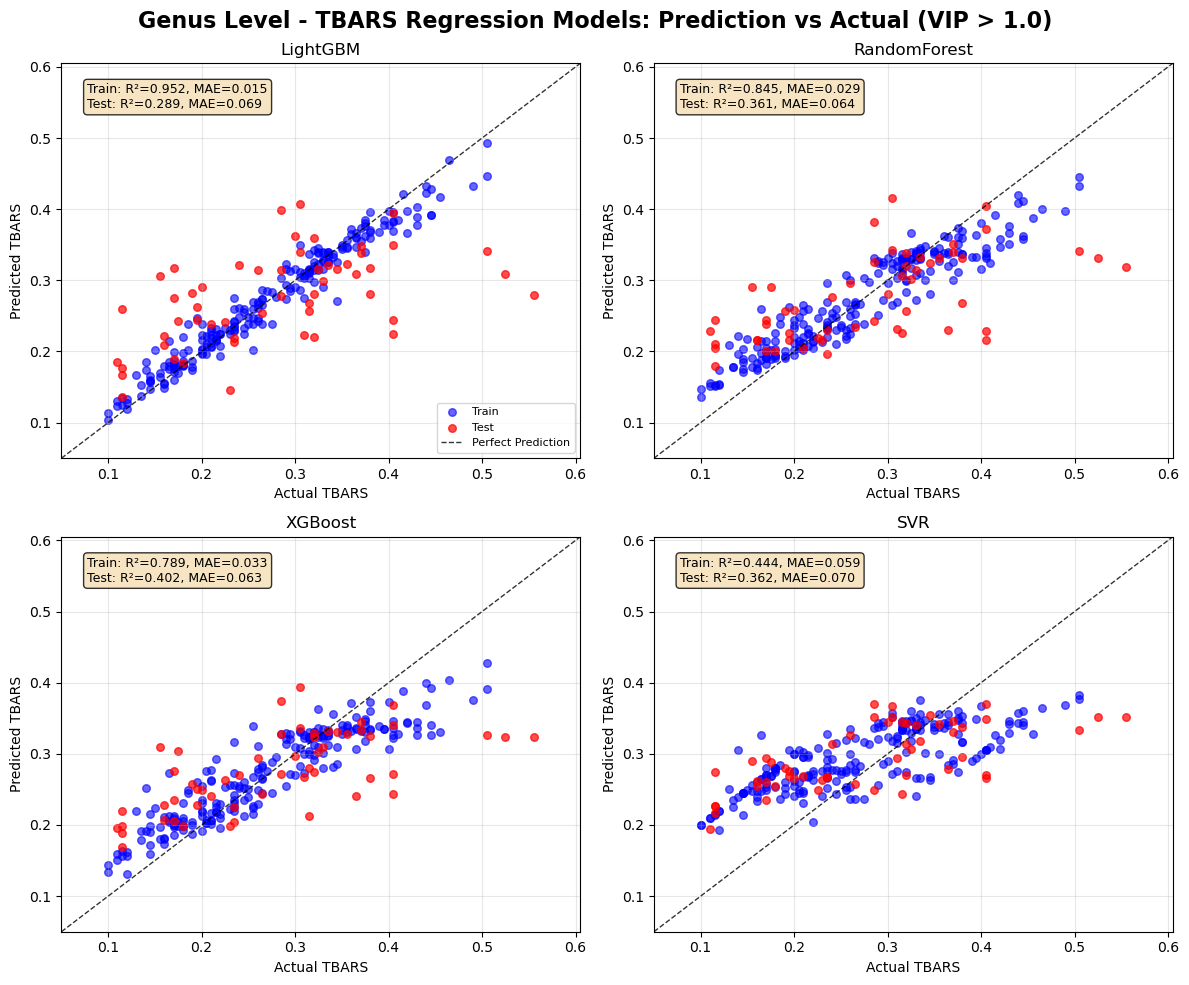

In [27]:
# TBARS Prediction vs Actual 시각화 (2x2 subplot)
import matplotlib.pyplot as plt
import numpy as np

# 모델별 예측값 저장
tbars_model_predictions = {}

# 각 모델별로 다시 예측값 계산 (시각화용)
for i, model_name in enumerate(model_names):
    # 해당 모델로 다시 학습
    model_config = models[model_name]
    grid = GridSearchCV(
        model_config['model'], 
        model_config['params'], 
        cv=5, 
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    grid.fit(X_train_tbars, y_train_tbars)
    best_model = grid.best_estimator_
    
    # 예측
    y_train_pred = best_model.predict(X_train_tbars)
    y_test_pred = best_model.predict(X_test_tbars)
    
    # Train과 Test의 R2, MAE 계산
    train_r2 = r2_score(y_train_tbars, y_train_pred)
    test_r2 = r2_score(y_test_tbars, y_test_pred)
    train_mae = mean_absolute_error(y_train_tbars, y_train_pred)
    test_mae = mean_absolute_error(y_test_tbars, y_test_pred)
    
    tbars_model_predictions[model_name] = {
        'y_train': y_train_tbars,
        'y_test': y_test_tbars,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'test_mae': test_mae
    }

# 2x2 subplot 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Genus Level - TBARS Regression Models: Prediction vs Actual (VIP > 1.0)', fontsize=16, fontweight='bold')

# 전체 데이터 범위 계산
all_actual_tbars = np.concatenate([y_train_tbars, y_test_tbars])
min_val_tbars = all_actual_tbars.min() - 0.05
max_val_tbars = all_actual_tbars.max() + 0.05

for i, model_name in enumerate(model_names):
    row = i // 2
    col = i % 2
    ax = axes[row, col]
    
    pred_data = tbars_model_predictions[model_name]
    
    # Train 데이터 플롯 (파란색)
    ax.scatter(pred_data['y_train'], pred_data['y_train_pred'], 
               alpha=0.6, color='blue', s=30, label='Train')
    
    # Test 데이터 플롯 (빨간색)
    ax.scatter(pred_data['y_test'], pred_data['y_test_pred'], 
               alpha=0.7, color='red', s=30, label='Test')
    
    # Perfect prediction line (검은 점선)
    ax.plot([min_val_tbars, max_val_tbars], [min_val_tbars, max_val_tbars], 
            'k--', alpha=0.8, linewidth=1, label='Perfect Prediction')
    
    # 축 설정
    ax.set_xlim(min_val_tbars, max_val_tbars)
    ax.set_ylim(min_val_tbars, max_val_tbars)
    ax.set_xlabel('Actual TBARS')
    ax.set_ylabel('Predicted TBARS')
    ax.set_title(f'{model_name}')
    ax.grid(True, alpha=0.3)
    
    # 성능 지표 텍스트 추가
    textstr = f'Train: R²={pred_data["train_r2"]:.3f}, MAE={pred_data["train_mae"]:.3f}\nTest: R²={pred_data["test_r2"]:.3f}, MAE={pred_data["test_mae"]:.3f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props)
    
    # 범례 (첫 번째 subplot에만)
    if i == 0:
        ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()